# Predicting NYC Housing Prices [Work in Progress]

**Current Status**: Actively optimizing spatial models and expanding feature engineering.  
**Latest Milestone**: Implemented Moran's I. 

## Goal of the Project
The goal of this project is to **predict housing prices in New York City** using a dataset that includes features such as property type, neighborhood, number of bedrooms, number of bathrooms, and area. By building a robust regression model, we aim to:

1. **Understand the key factors** that influence housing prices in NYC.
2. **Provide accurate price predictions** that can assist buyers, sellers, and real estate professionals in making informed decisions.
3. **Explore and visualize trends** in the housing market, such as the impact of location, property size, and type on pricing.

This project will involve:
- **Exploratory Data Analysis (EDA)** to uncover patterns and relationships in the data.
- **Feature Engineering** to create meaningful predictors from the raw data.
- **Model Development** using machine learning algorithms to predict housing prices.
- **Evaluation** of model performance using metrics like RMSE and R².

**Project Status**:
- ✅ Exploratory Data Analysis (Completed)  
- ✅ Baseline Model Development (Completed)  
- [ ] Spatial Feature Optimization (In Progress)
- [ ] K-fold Target Encoding (Planned)
- [ ] Model Selection and Optimization (Planned)

# Load, clean and first look the data

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot

In [4]:
import geopandas as gpd

In [5]:
# Import dataset
file = '../data/NY-House-Dataset.csv'

In [6]:
# load the data
df = pd.read_csv(file)

In [7]:
# Inspect the data
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [8]:
# Check the dataset's structure
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print("\nColumn names and data types:")
print(df.info())

Number of rows: 4801, Number of columns: 17

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  ST

First Look Observations:
1. BROKERTITLE - Appears to just contain broker names (likely not useful for analysis)
2. BEDS (int) vs BATHS (float) - different data types
3. Address fields - Multiple address columns with potential redundancy:
   - ADDRESS, MAIN_ADDRESS, FORMATTED_ADDRESS all seem similar.
4. STATE - actually contains ZIP codes
5. Administrative geography fields - Inconsistent granularity:
   - ADMINISTRATIVE_AREA_LEVEL_2 mixes counties with country
   - STREET_NAME contains both street names and area names
   - SUBLOCALITY seems most promising for neighborhood analysis


- Consider creating 'NEIGHBORHOOD' and 'BOROUGH'/'COUNTY' feature
- Address fields could be helpfull if geocoding will be needed

In [9]:
# Inspect numerative features
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


Right-skewness evident from:

Price: Median 2,147,484,000<br>
Beds: Median 3 vs Max 50<br>
Bath: Median 2 vs Max 50<br>
Sqft: Median 2184.2 vs Max 65535.0<br>

Option 1: Apply log transformation<br>
Option 2: Analyze luxury segment separately<br>
Option 3: Winsorize extreme values<br>
<br>
Suspicious pattern detected in PROPERTYSQFT:

Exact same value (2184.21) appears as:
Mean, 50th percentile (median), 75th percentile<br>
This suggests: Missing values may have been imputed with this number

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [11]:
# Check for Nulls
df.isna().sum()

BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

No null data

In [12]:
# Check for duplicates
df.duplicated().sum()

np.int64(214)

In [13]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# Standartize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [16]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude'],
      dtype='object')

In [17]:
df.bath.value_counts()

bath
2.000000     1593
1.000000     1456
4.000000      464
3.000000      447
2.373861      288
6.000000      134
5.000000       95
8.000000       43
7.000000       23
10.000000      16
9.000000        7
16.000000       5
12.000000       3
20.000000       3
11.000000       2
0.000000        2
13.000000       1
32.000000       1
50.000000       1
24.000000       1
43.000000       1
17.000000       1
Name: count, dtype: int64

In [18]:
# Apparently there is insertion of missed data for bath, so changing type is not needed for now
# df.bath = df.bath.astype(int)

In [19]:
original_length = df.shape[0]

In [20]:
original_length

4587

In [21]:
# Reset index after cleaning
df = df.reset_index(drop=True)

## Exploratory Data Analysis (EDA)

## Price distribution analysis

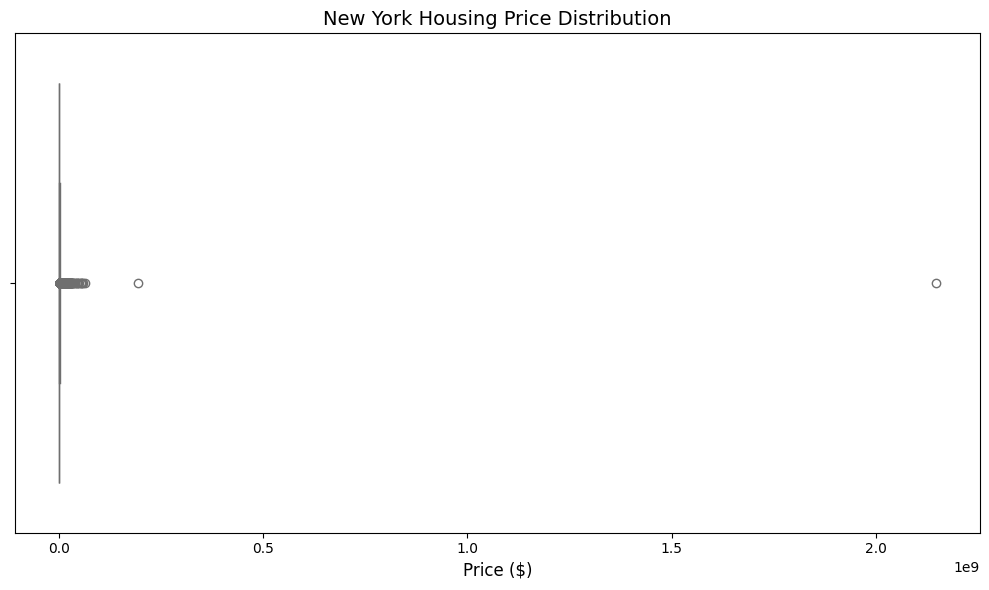

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [23]:
# Right-skewed price distribution. Should check for error data

In [24]:
df.sort_values(by=['price'], ascending=False).head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude
292,Brokered by ANNE LOPA REAL ESTATE,House for sale,2147483647,7,6.000000,10000.000000,6659-6675 Amboy Rd,"New York, NY 10309","6659-6675 Amboy RdNew York, NY 10309",United States,New York,Richmond County,Staten Island,Amboy Road,"6659 Amboy Rd, Staten Island, NY 10309, USA",40.518484,-74.224418
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.000000,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
69,Brokered by Sotheby's International Realty - E...,Townhouse for sale,65000000,3,2.373861,15200.000000,4 E 79th St,"New York, NY 10075","4 E 79th StNew York, NY 10075",United States,New York,New York County,New York,East 79th Street,"4 E 79th St, New York, NY 10075, USA",40.776561,-73.963317
1044,Brokered by COMPASS,Co-op for sale,60000000,8,8.000000,2184.207862,960 5th Ave Unit 12,"Manhattan, NY 10075","960 5th Ave Unit 12Manhattan, NY 10075",New York,New York County,New York,Manhattan,960,"960 5th Ave #12, New York, NY 10075, USA",40.775642,-73.964247
138,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,56000000,11,10.000000,24000.000000,9 W 54th St,"New York, NY 10019","9 W 54th StNew York, NY 10019",United States,New York,New York County,New York,West 54th Street,"9 W 54th St, New York, NY 10019, USA",40.761600,-73.976191


In [25]:
# Remove integer overflow error: 2,147,483,647 is the max 32-bit int
# This value appears unrealistic for NYC property (likely data entry error)
df = df[df.price < df.price.max()]

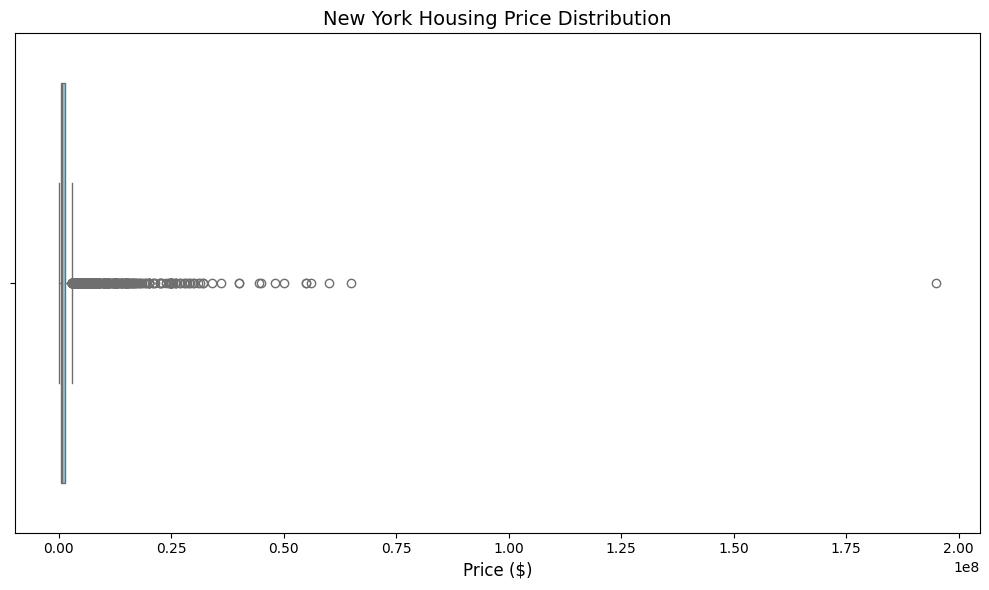

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [27]:
# Still hava an outlier on 195000000$.I checked this property, apparently it is a very famous ultra expensive apartment.
# I will also exclude it

In [28]:
df = df[df.price < df.price.max()]

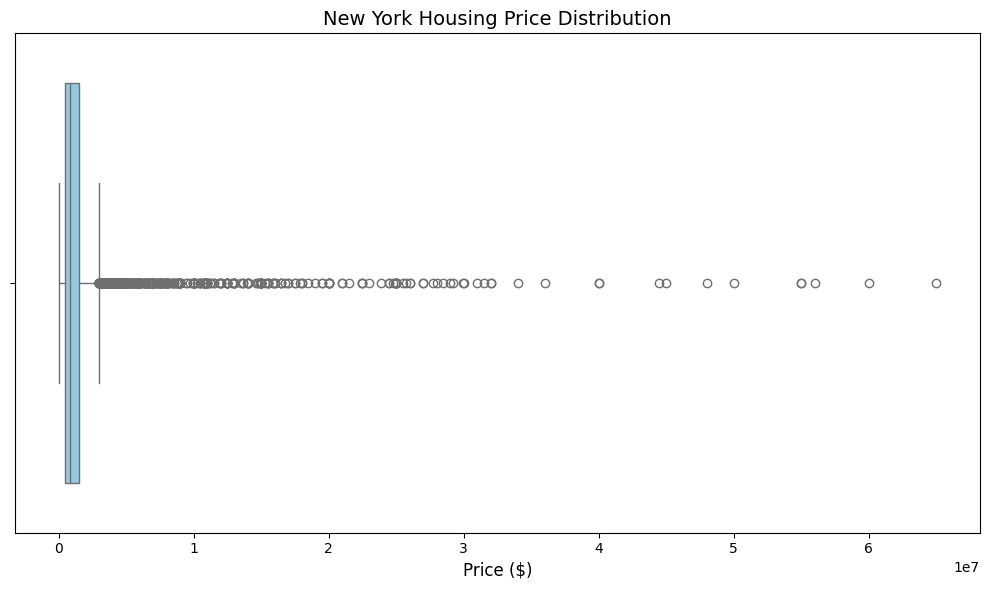

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [30]:
# Now boxplot looks reasonable

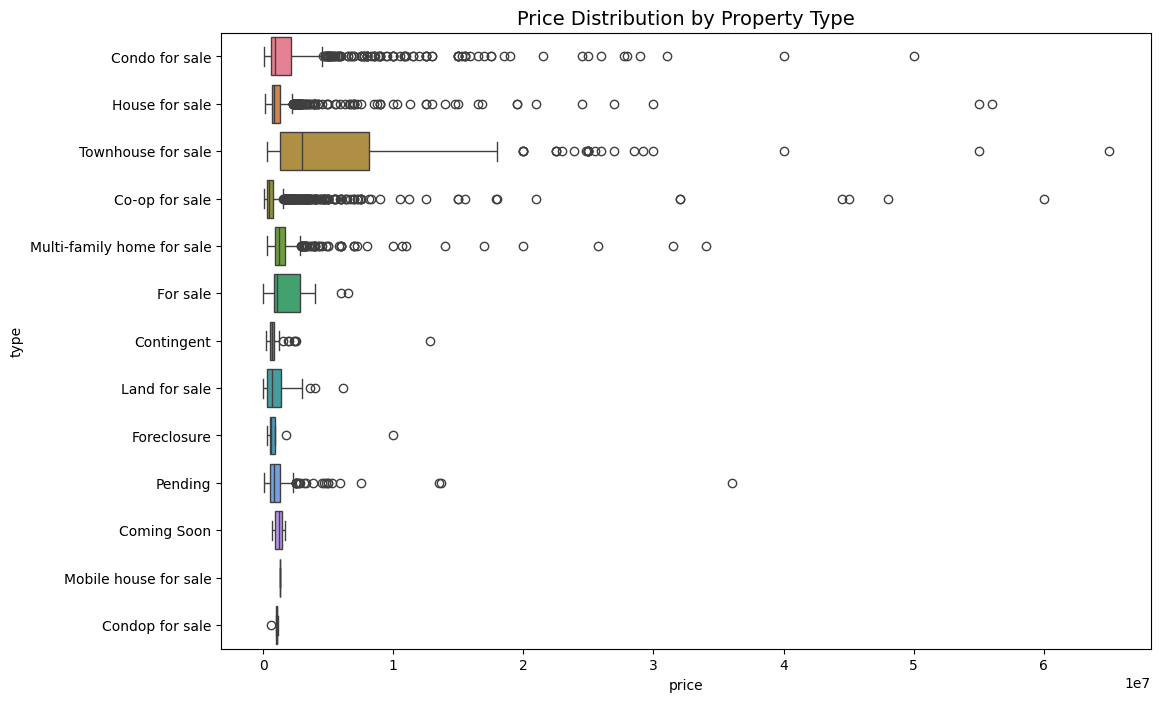

In [31]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
plt.title('Price Distribution by Property Type', fontsize=14)
sns.boxplot(df, x='price', y='type', hue='type')
plt.show()

In [32]:
# Here we can see that we have a stratification of the market, apparently townhouses are considered more as luxurious property

In [33]:
# Calculate 90th percentile price thresholds by property type to identify price ceilings 
# for the top 10% of each property type and understand price distribution characteristics across categories

type_thresholds = df.groupby('type')['price'].quantile(0.9) 

In [34]:
print('0.90 quantile by type of houses')
print(type_thresholds.sort_values())
print('mean:',type_thresholds.mean())
print('median:',type_thresholds.median())

0.90 quantile by type of houses
type
Condop for sale                1111500.0
Contingent                     1119400.0
Mobile house for sale          1288000.0
Foreclosure                    1494900.0
Coming Soon                    1590400.0
Co-op for sale                 2150000.0
Pending                        2290400.0
House for sale                 2399600.0
Multi-family home for sale     2499000.0
Land for sale                  2729980.0
For sale                       4199900.0
Condo for sale                 5250000.0
Townhouse for sale            15892000.0
Name: price, dtype: float64
mean: 3385775.384615385
median: 2290400.0


In [35]:
# We again observe that the townhouse category is significantly different

In [36]:
# Calculate 50th percentile price thresholds by property type to assess entry - middle division point

type_thresholds_50 = df.groupby('type')['price'].quantile(0.5)
print('0.50 quantile by type of houses')
print(type_thresholds_50.sort_values())
print('mean:',type_thresholds_50.mean())
print('median:',type_thresholds_50.median())

0.50 quantile by type of houses
type
Co-op for sale                 425000.0
Foreclosure                    592450.0
Land for sale                  675000.0
Contingent                     689900.0
Pending                        825000.0
House for sale                 858000.0
Condo for sale                 880000.0
For sale                      1044500.0
Condop for sale               1072500.0
Coming Soon                   1172000.0
Multi-family home for sale    1199000.0
Mobile house for sale         1288000.0
Townhouse for sale            2995000.0
Name: price, dtype: float64
mean: 1055103.8461538462
median: 880000.0


In [37]:
# Threshold set at $3,000,000 based on central tendency analysis of the 0.90 quantile prices by property type
# And for entry - middle division set at $1,000,000
# Probable downside is that townhouses could be undervalued by modelling

# Create the upper segment flag
df['is_upper'] = (df['price'] > 3_000_000).astype(int)

# Also add middle segment more then 1 mln and lower then upper segment
df['is_mid'] = ((df['price'] > 1_000_000) & (df['price'] <= 3_000_000)).astype(int)

df['is_luxury'] = (df['price'] > 12_000_000).astype(int)

# Also create cateforical price segment column
df['price_segment'] = pd.cut(
    df['price'],
    bins=[0, 1_000_000, 3_000_000, 12_000_000, np.inf],
    labels=['entry', 'mid', 'upper', 'luxury'],
    include_lowest=True,
    right=True
)

In [38]:
# Apply natural log transformation to price
df['log_price'] = np.log(df.price)

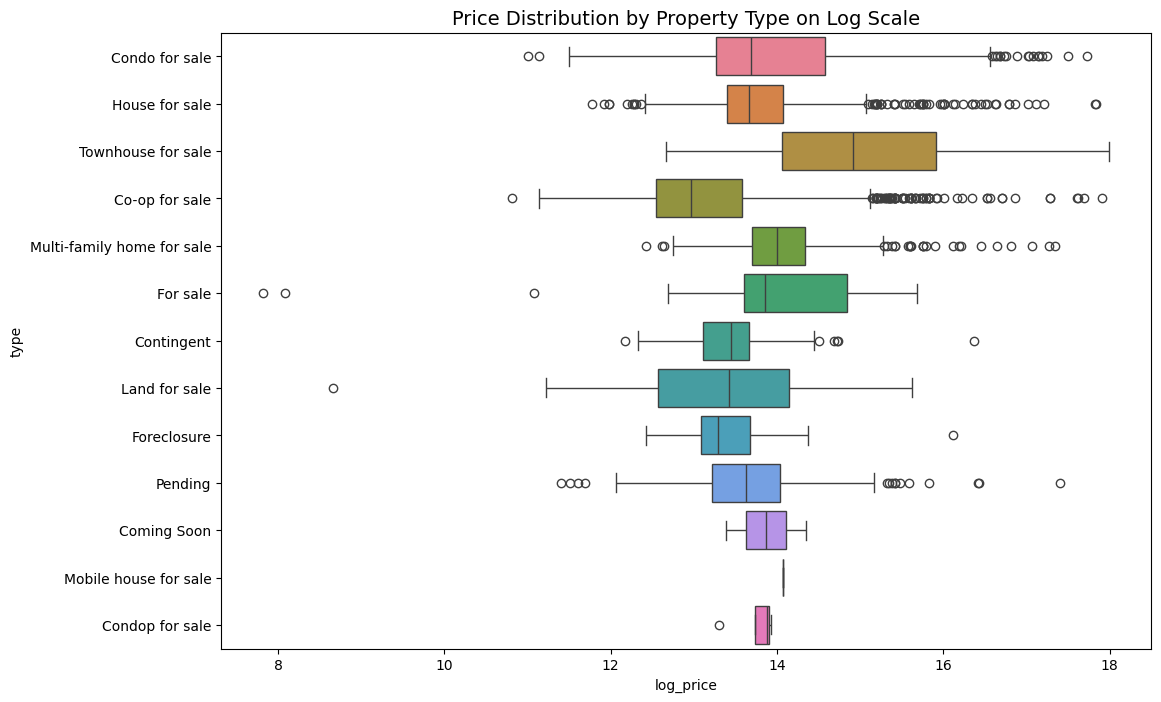

In [39]:
plt.figure(figsize=(12, 8))
plt.title('Price Distribution by Property Type on Log Scale', fontsize=14)
sns.boxplot(df, x='log_price', y='type', hue='type')
plt.show()

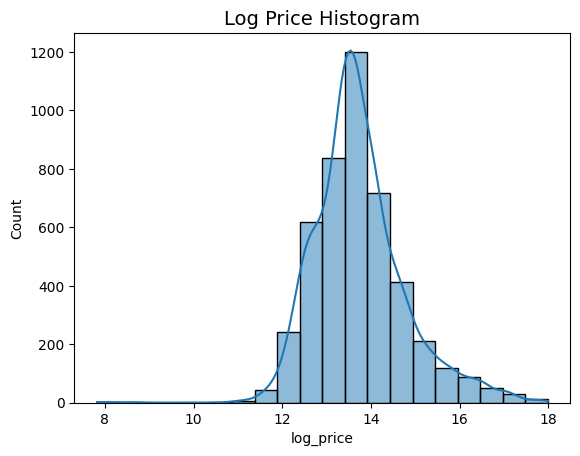

In [40]:
sns.histplot(df.log_price, bins=20, kde=True)
plt.title('Log Price Histogram', fontsize=14)
plt.show()

In [41]:
# log_price looks quite normal

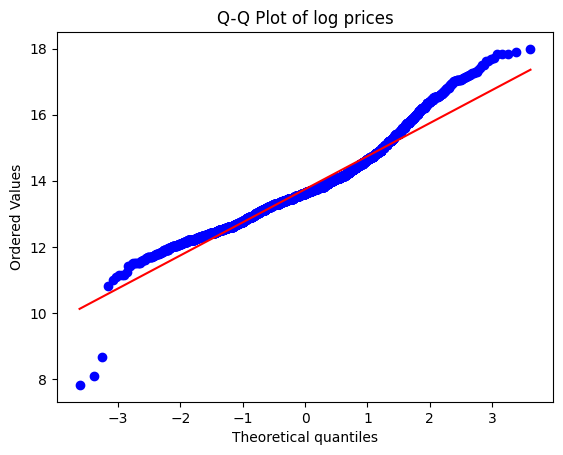

In [42]:
# Identify outliers on Q-Q plot
probplot(df['log_price'], dist="norm", plot=plt)
plt.title("Q-Q Plot of log prices")
plt.show()

In [43]:
# I see three outliers in lower range

In [44]:
df.sort_values('price').head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,...,street_name,long_name,formatted_address,latitude,longitude,is_upper,is_mid,is_luxury,price_segment,log_price
305,Brokered by Living NY - Main Office,For sale,2494,2,1.000000,2184.207862,635 W 170th St Apt 4F,"New York, NY 10032","635 W 170th St Apt 4FNew York, NY 10032",New York,...,Manhattan,635,"635 W 170th St #4f, New York, NY 10032, USA",40.843406,-73.940795,0,0,0,entry,7.821643
298,Brokered by Living NY - Main Office,For sale,3225,3,1.000000,2184.207862,635 W 170th St Apt 2C,"New York, NY 10032","635 W 170th St Apt 2CNew York, NY 10032",New York,...,Manhattan,635,"635 W 170th St #2c, New York, NY 10032, USA",40.843406,-73.940795,0,0,0,entry,8.078688
347,Brokered by Century 21 Realty First,Land for sale,5800,3,2.373861,2184.207862,4515 Avenue N Lot 5,"Brooklyn, NY 11234","4515 Avenue N Lot 5Brooklyn, NY 11234",New York,...,Flatlands,4515,"4515 Avenue N #5, Brooklyn, NY 11234, USA",40.618915,-73.931211,0,0,0,entry,8.665613
449,Brokered by Morris Park Realty Group,Co-op for sale,49500,3,2.373861,800.000000,150 City Island Ave Unit E3,"Bronx, NY 10464","150 City Island Ave Unit E3Bronx, NY 10464",New York,...,City Island,150,"150 City Island Ave #3e, Bronx, NY 10464, USA",40.843284,-73.784603,0,0,0,entry,10.809728
950,Brokered by COMPASS,Condo for sale,60000,3,1.000000,445.000000,2 E 55th St Unit 809W35,"Manhattan, NY 10022","2 E 55th St Unit 809W35Manhattan, NY 10022",New York,...,Manhattan,2,"2 E 55th St 809 35, New York, NY 10022, USA",40.761398,-73.974613,0,0,0,entry,11.002100


In [45]:
# Data cleaning:
# - $2,494 and $3,225 (Manhattan apartments) - Below realistic thresholds
# - $5,800 (land) - Far below NYC market minimums

df = df[df.price>10000]

In [46]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [47]:
1 - len(df)/original_length

0.0010900370612600963

In [48]:
# dropped only 0.1% of data

## Other variables distribution

In [49]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude', 'is_upper', 'is_mid',
       'is_luxury', 'price_segment', 'log_price'],
      dtype='object')

### _Brokertitle_

In [50]:
df.brokertitle.value_counts()

brokertitle
Brokered by COMPASS                              435
Brokered by Douglas Elliman - 575 Madison Ave    109
Brokered by Brown Harris Stevens                  93
Brokered by Corcoran East Side                    86
Brokered by RE MAX Edge                           75
                                                ... 
Brokered by Tworealestate Llc                      1
Brokered by Blue Key Real Estate Brokerage         1
Brokered by Douglas Elliman - New Hyde Park        1
Brokered by Renken Realty LLC                      1
Brokered by Contact Realty Ii Corp                 1
Name: count, Length: 1035, dtype: int64

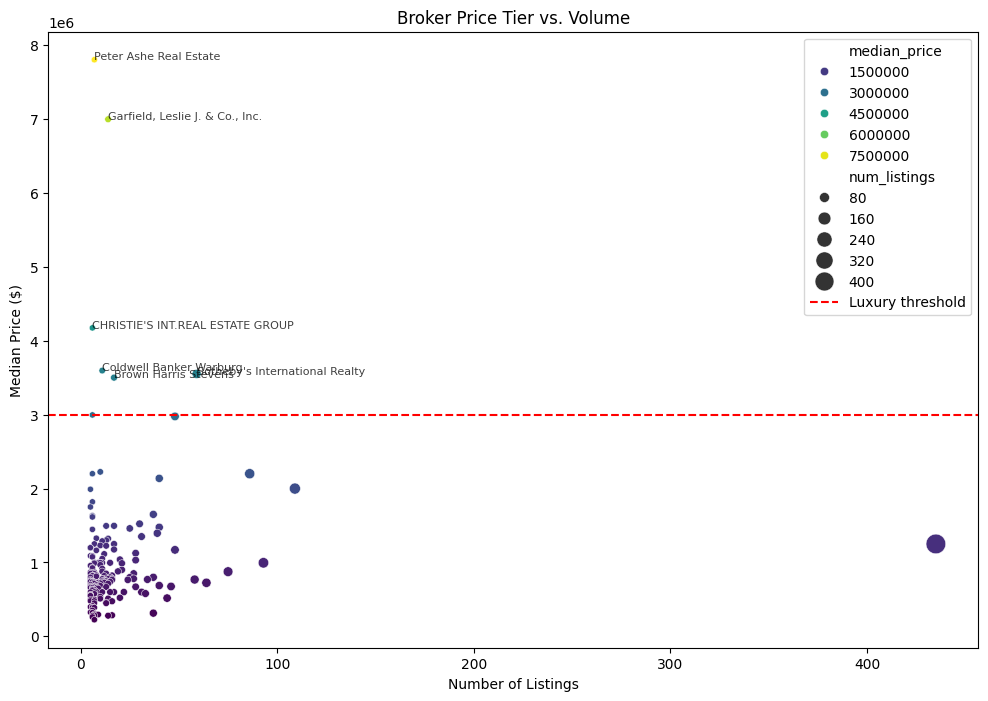

In [51]:
# Get broker stats: count and median price
broker_stats = df.groupby('brokertitle').agg(
    num_listings=('price', 'count'),
    median_price=('price', 'median'),
    max_price=('price', 'max')
).sort_values('median_price', ascending=False)

# Filter brokers with ≥5 listings (avoid noise)
broker_stats = broker_stats[broker_stats['num_listings'] >= 5]

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=broker_stats,
    x='num_listings',
    y='median_price',
    hue='median_price',
    palette='viridis',
    size='num_listings',
    sizes=(20, 200)
)

# Annotate top luxury brokers
top_luxury = broker_stats[broker_stats['median_price'] > 3_000_000]  # Adjust thresholdb
for idx, row in top_luxury.iterrows():
    plt.annotate(
        idx.replace('Brokered by ', '').split('-')[0].strip(),
        (row['num_listings'], row['median_price']),
        fontsize=8, alpha=0.75
    )

#plt.xscale('log')  # Better visibility for wide-ranging counts
plt.xlabel('Number of Listings')
plt.ylabel('Median Price ($)')
plt.title('Broker Price Tier vs. Volume')
plt.axhline(y=3_000_000, color='red', linestyle='--', label='Luxury threshold') 
plt.legend()
plt.show()

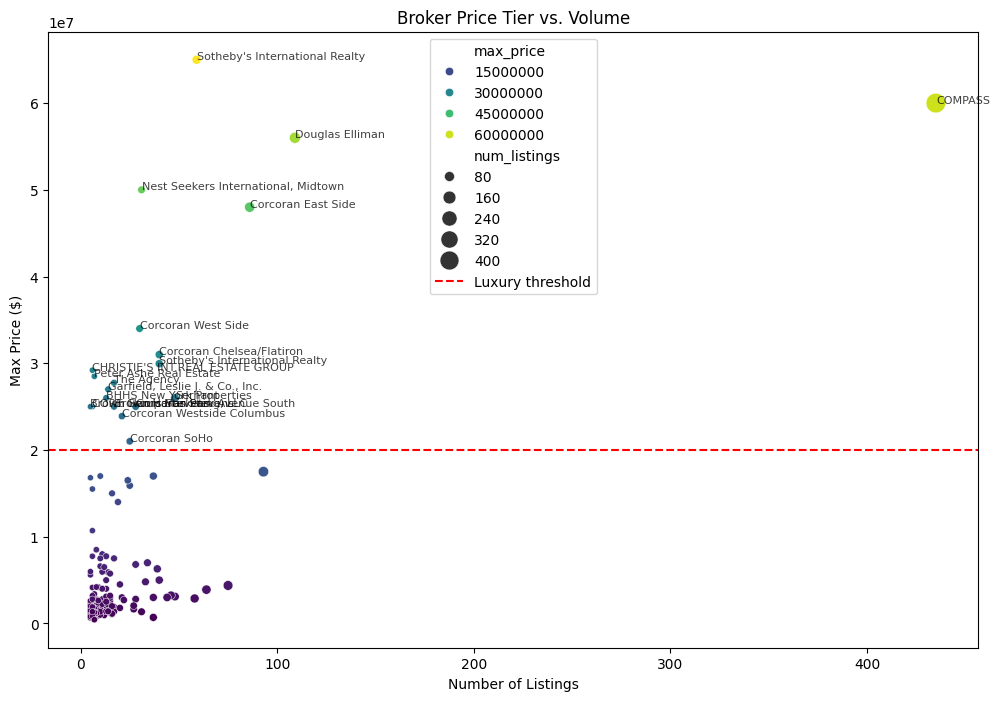

In [52]:
# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=broker_stats,
    x='num_listings',
    y='max_price',
    hue='max_price',
    palette='viridis',
    size='num_listings',
    sizes=(20, 200)
)

# Annotate top luxury brokers
top_luxury = broker_stats[broker_stats['max_price'] > 20_000_000]  # Adjust thresholdb
for idx, row in top_luxury.iterrows():
    plt.annotate(
        idx.replace('Brokered by ', '').split('-')[0].strip(),
        (row['num_listings'], row['max_price']),
        fontsize=8, alpha=0.75
    )

#plt.xscale('log')  # Better visibility for wide-ranging counts
plt.xlabel('Number of Listings')
plt.ylabel('Max Price ($)')
plt.title('Broker Price Tier vs. Volume')
plt.axhline(y=20_000_000, color='red', linestyle='--', label='Luxury threshold') 
plt.legend()
plt.show()

In [53]:
broker_stats.head(10)

,num_listings,median_price,max_price
brokertitle,,,
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,7,7800000.0,28500000
"Brokered by Garfield, Leslie J. & Co., Inc.",14,6995000.0,27000000
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,6,4172500.0,29200000
Brokered by Coldwell Banker Warburg,11,3595000.0,7995000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
Brokered by Brown Harris Stevens - 1926 Broadway,17,3500000.0,25000000
"Brokered by CORE Group Marketing, LLC",6,2994999.5,25000000
Brokered by Serhant,48,2974999.5,26000000
Brokered by R New York,10,2225000.0,16995000


In [54]:
broker_stats.sort_values(by='num_listings', ascending=False).head(10)

,num_listings,median_price,max_price
brokertitle,,,
Brokered by COMPASS,435,1250000.0,60000000
Brokered by Douglas Elliman - 575 Madison Ave,109,1999000.0,56000000
Brokered by Brown Harris Stevens,93,995000.0,17500000
Brokered by Corcoran East Side,86,2200000.0,48000000
Brokered by RE MAX Edge,75,875000.0,4380000
Brokered by Winzone Realty Inc,64,724500.0,3900000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
Brokered by E Realty International Corp,58,768500.0,2880000
Brokered by Serhant,48,2974999.5,26000000


In [55]:
df.sort_values(by='price', ascending=False).head(15)

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,...,street_name,long_name,formatted_address,latitude,longitude,is_upper,is_mid,is_luxury,price_segment,log_price
68,Brokered by Sotheby's International Realty - E...,Townhouse for sale,65000000,3,2.373861,15200.000000,4 E 79th St,"New York, NY 10075","4 E 79th StNew York, NY 10075",United States,...,New York,East 79th Street,"4 E 79th St, New York, NY 10075, USA",40.776561,-73.963317,1,0,1,luxury,17.989898
1039,Brokered by COMPASS,Co-op for sale,60000000,8,8.000000,2184.207862,960 5th Ave Unit 12,"Manhattan, NY 10075","960 5th Ave Unit 12Manhattan, NY 10075",New York,...,Manhattan,960,"960 5th Ave #12, New York, NY 10075, USA",40.775642,-73.964247,1,0,1,luxury,17.909855
137,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,56000000,11,10.000000,24000.000000,9 W 54th St,"New York, NY 10019","9 W 54th StNew York, NY 10019",United States,...,New York,West 54th Street,"9 W 54th St, New York, NY 10019, USA",40.761600,-73.976191,1,0,1,luxury,17.840862
3,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.000000,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,...,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856,1,0,1,luxury,17.822844
97,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,55000000,8,8.000000,12000.000000,25 Riverside Dr,"New York, NY 10023","25 Riverside DrNew York, NY 10023",United States,...,New York,Riverside Drive,"25 Riverside Dr, New York, NY 10023, USA",40.782238,-73.984632,1,0,1,luxury,17.822844
602,"Brokered by Nest Seekers International, Midtown",Condo for sale,50000000,6,6.000000,6569.000000,100 Vandam St Apt 20A,"New York, NY 10013","100 Vandam St Apt 20ANew York, NY 10013",New York,...,Manhattan,100,"100 Vandam St #20a, New York, NY 10013, USA",40.726633,-74.008832,1,0,1,luxury,17.727534
1401,Brokered by Corcoran East Side,Co-op for sale,48000000,5,2.373861,2184.207862,740 Park Ave # 4 & 5B,"New York, NY 10021","740 Park Ave # 4 & 5BNew York, NY 10021",New York,...,Manhattan,740,"740 Park Ave #5, New York, NY 10021, USA",40.770752,-73.964528,1,0,1,luxury,17.686712
3255,Brokered by Sotheby's International Realty - E...,Co-op for sale,45000000,5,2.373861,2184.207862,4 E 66th St Fl 7,"New York, NY 10065","4 E 66th St Fl 7New York, NY 10065",New York,...,Manhattan,4,"4 E 66th St Fl 7, New York, NY 10065, USA",40.768301,-73.969734,1,0,1,luxury,17.622173
3427,Brokered by Sotheby's International Realty - E...,Co-op for sale,44500000,5,6.000000,2184.207862,2 E 67th St Fl 9,"New York, NY 10065","2 E 67th St Fl 9New York, NY 10065",New York,...,Manhattan,2,"2 E 67th St Fl 9, New York, NY 10065, USA",40.768973,-73.969136,1,0,1,luxury,17.611000
1413,Brokered by Douglas Elliman - New Development,Condo for sale,40000000,5,6.000000,7488.000000,111 Murray St Ph 2,"New York, NY 10007","111 Murray St Ph 2New York, NY 10007",New York,...,Manhattan,111,"111 Murray St Ph 2, New York, NY 10007, USA",40.715351,-74.012844,1,0,1,luxury,17.504390


In [56]:
selected_brokers = [
    'COMPASS',
    'Sotheby\'s International Realty - East Side Manhattan Brokerage',
    'Peter Ashe Real Estate- Peter Ashe Real Estate',
    'Douglas Elliman - 575 Madison Ave',
    'Corcoran East Side',
    'Serhant',
    'Garfield, Leslie J. & Co., Inc.',
    "CHRISTIE'S INT.REAL ESTATE GROUP",
    'Coldwell Banker Warburg',
    
    
    
]

# Filter data
plot_data = df[df['brokertitle'].str.contains('|'.join(selected_brokers))]

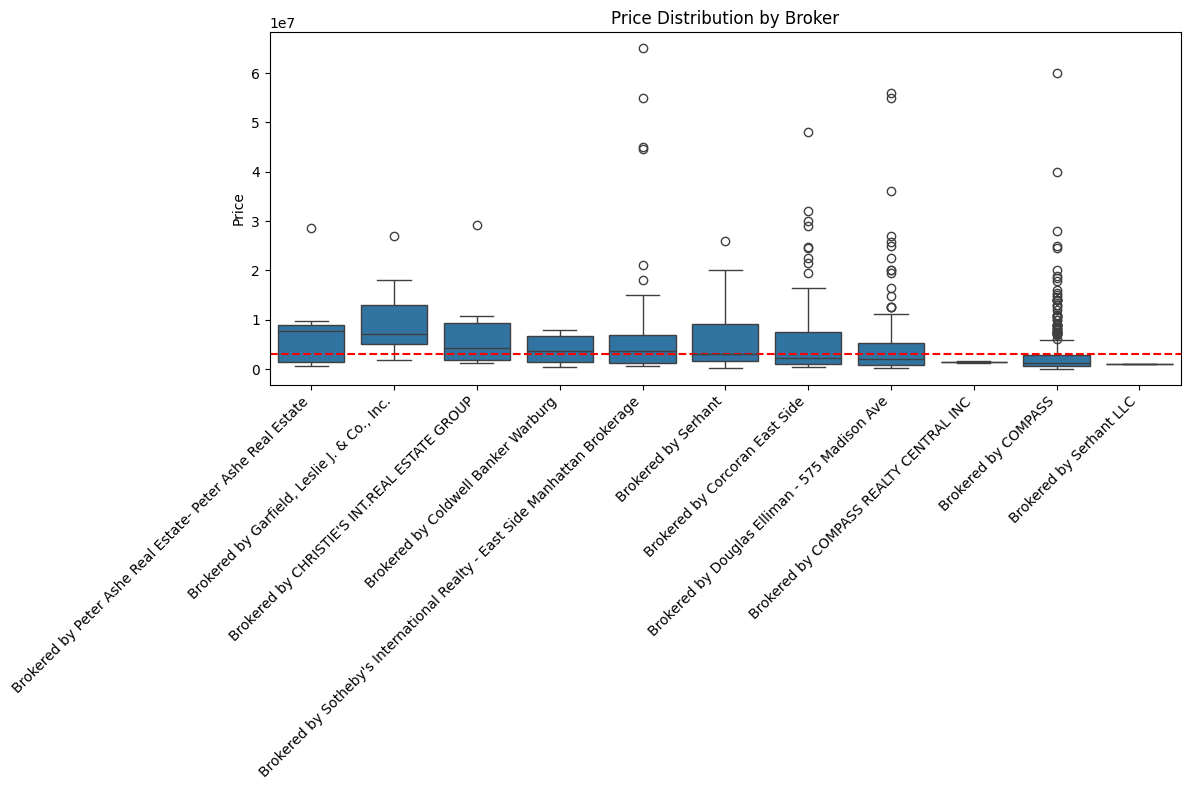

In [57]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=plot_data,
    x='brokertitle',
    y='price',
    order=plot_data.groupby('brokertitle')['price'].median().sort_values(ascending=False).index,
    showfliers=True  # Hide outliers initially
)

# Add context
plt.axhline(y=3_000_000, color='red', linestyle='--', label='Luxury threshold')
plt.xticks(rotation=45, ha='right')
#plt.yscale('log')  # Critical for NYC price ranges
plt.title('Price Distribution by Broker')
plt.ylabel('Price')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [58]:
broker_stats

,num_listings,median_price,max_price
brokertitle,,,
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,7,7800000.0,28500000
"Brokered by Garfield, Leslie J. & Co., Inc.",14,6995000.0,27000000
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,6,4172500.0,29200000
Brokered by Coldwell Banker Warburg,11,3595000.0,7995000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
...,...,...,...
Brokered by RE/MAX City Square,7,284888.0,1268000
Brokered by Keller Williams Realty Liberty,14,279250.0,1399000
Brokered by Goldstone N Y Realty Llc,6,278500.0,880000


In [59]:
df['broker_count'] = df['brokertitle'].map(df['brokertitle'].value_counts())

In [60]:
# Step 1: Define your luxury price threshold (adjust based on your market)
LUXURY_THRESHOLD = 2_000_000 

# Step 2: Calculate Luxury Score for each broker
luxury_scores = (
    df[(df['price'] >= LUXURY_THRESHOLD) & (df['broker_count']>5)]  # Filter luxury properties
    .groupby('brokertitle')              # Group by broker
    .size() /                            # Count luxury listings per broker
    df.groupby('brokertitle').size()     # Divide by broker's total listings
).fillna(0)                              # Handle brokers with no luxury properties

# Step 3: Add scores back to original DataFrame
df['luxury_score'] = df['brokertitle'].map(luxury_scores)

In [61]:
df.groupby('brokertitle')[['luxury_score', 'price']].median().sort_values('luxury_score', ascending=False).head(10)

,luxury_score,price
brokertitle,,
"Brokered by Garfield, Leslie J. & Co., Inc.",0.928571,6995000.0
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,0.677966,3550000.0
"Brokered by CORE Group Marketing, LLC",0.666667,2994999.5
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,0.666667,4172500.0
Brokered by Coldwell Banker Warburg,0.636364,3595000.0
Brokered by Serhant,0.604167,2974999.5
Brokered by R New York,0.600000,2225000.0
Brokered by Brown Harris Stevens - 1926 Broadway,0.588235,3500000.0
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,0.571429,7800000.0


In [62]:
peter_ashe = df[df['brokertitle'] == 'Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate']
peter_ashe['price'].describe()

count    7.000000e+00
mean     8.253429e+06
std      9.697945e+06
min      5.990000e+05
25%      1.437500e+06
50%      7.800000e+06
75%      9.000000e+06
max      2.850000e+07
Name: price, dtype: float64

In [63]:
# Binary flags for top brokers
top_luxury_brokers = ['Garfield', 'Christie\'s', 'Sotheby\'s', 'Peter Ashe']
df['is_top_luxury_broker'] = df['brokertitle'].str.contains('|'.join(top_luxury_brokers)).astype(int)

In [64]:
from sklearn.ensemble import RandomForestRegressor

# Select broker-related features
broker_features = [
    'luxury_score',
    'broker_count',
    'is_top_luxury_broker'
]

# Train model (only on broker features for now)
X = df[broker_features]
y = df['price']  # Or log(price) if you prefer

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: title={'center': 'Broker Feature Importance'}>

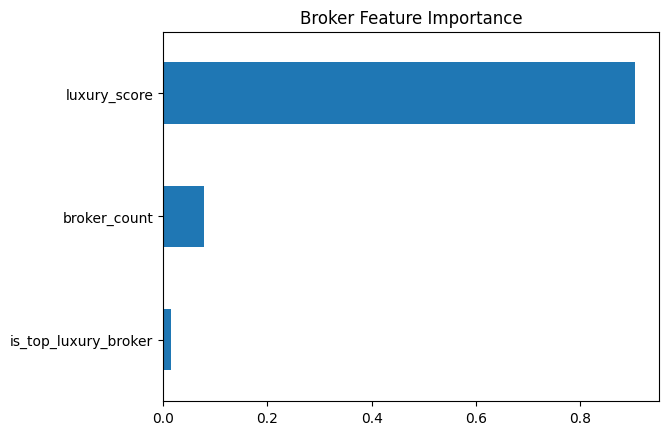

In [65]:
importances = pd.Series(model.feature_importances_, index=broker_features).sort_values()
importances.plot(kind='barh', title='Broker Feature Importance')

In [66]:
df[['luxury_score', 'price']].corr()

,luxury_score,price
luxury_score,1.00000,0.36752
price,0.36752,1.00000


In [67]:
df.brokertitle.value_counts().describe()

count    1035.000000
mean        4.427053
std        15.918532
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       435.000000
Name: count, dtype: float64

In [68]:
# In previous attemnt I write "High cardinality variable, it looks like it's not going to be helpfull"
# But now I think I am going to use brokers data in some form on modelling
# Probably wiil TARGET ENCODE broker luxury score on train data

### _Type_

In [69]:
df.type.value_counts()

type
Co-op for sale                1388
House for sale                 965
Condo for sale                 841
Multi-family home for sale     699
Townhouse for sale             288
Pending                        229
Contingent                      87
Land for sale                   46
For sale                        18
Foreclosure                     14
Condop for sale                  4
Coming Soon                      2
Mobile house for sale            1
Name: count, dtype: int64

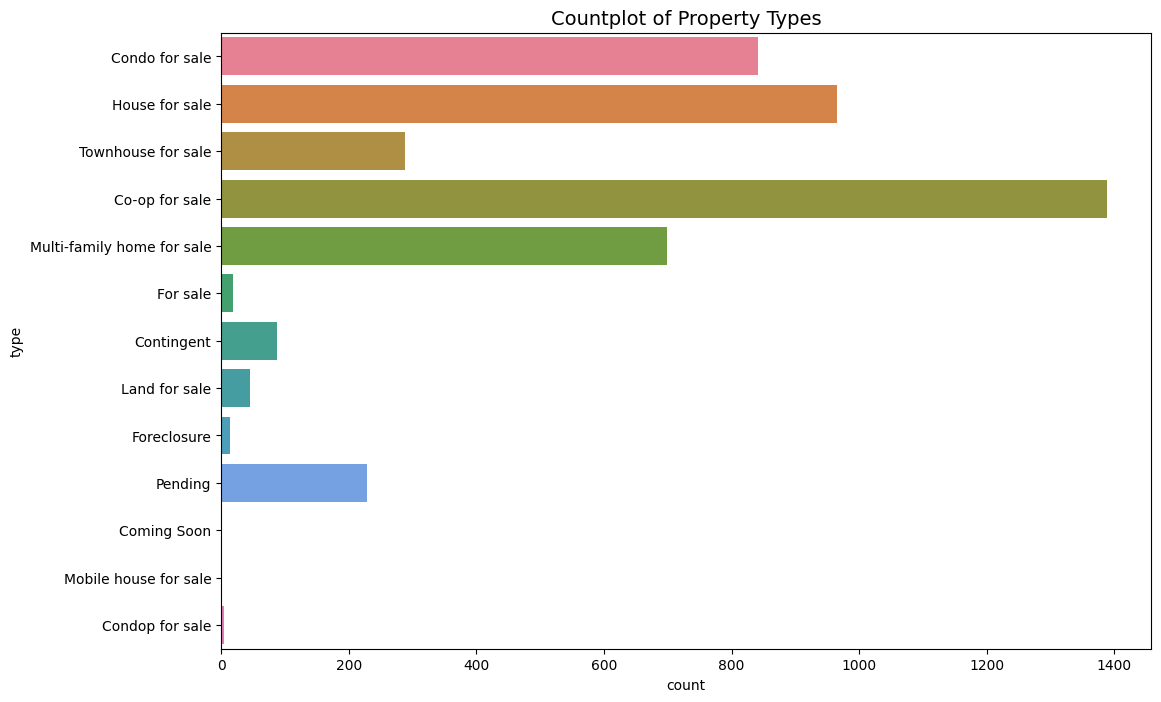

In [70]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='type', hue='type')
plt.title('Countplot of Property Types', fontsize=14)
plt.show()

In [71]:
# Identify types to potentially consolidate
rare_types = df['type'].value_counts()[df['type'].value_counts() < 20].index
print(f"Rare types (<20 listings): {list(rare_types)}")

Rare types (<20 listings): ['For sale', 'Foreclosure', 'Condop for sale', 'Coming Soon', 'Mobile house for sale']


In [72]:
# Group rare types in other category
df['type_clean'] = np.where(df['type'].isin(rare_types), 'Other', df['type'])

In [73]:
# Averages by type
df.groupby('type_clean')[['price', 'beds', 'bath', 'propertysqft', ]].mean().sort_values('price', ascending=False)

,price,beds,bath,propertysqft
type_clean,,,,
Townhouse for sale,6.406234e+06,5.020833,3.874356,3887.512776
Condo for sale,2.387024e+06,2.322235,1.993289,1552.737999
Other,1.676593e+06,3.589744,2.362092,2203.941082
Multi-family home for sale,1.666781e+06,6.261803,3.936427,3210.209600
House for sale,1.565096e+06,3.730570,2.528655,2246.429021
Pending,1.362436e+06,3.179039,2.247727,2076.871914
Land for sale,1.128747e+06,3.000000,2.365733,2157.377256
Co-op for sale,1.113426e+06,1.984870,1.438754,1658.496424
Contingent,8.886932e+05,3.218391,2.181008,1782.559344


In [74]:
# Here we also can see that townhouse type differs from others

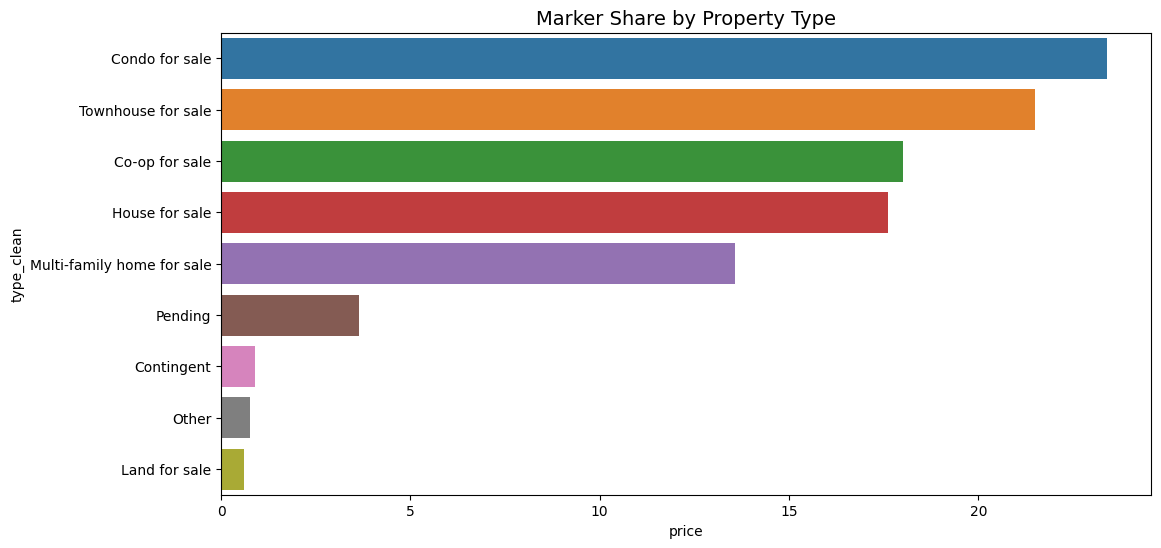

In [75]:
# Calculate market share by types
market_share = (df.groupby('type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='type_clean',
            hue='type_clean')
plt.title('Marker Share by Property Type', fontsize=14)
plt.show()

In [76]:
market_share

type_clean
Condo for sale                23.397448
Townhouse for sale            21.503595
Co-op for sale                18.012197
House for sale                17.602897
Multi-family home for sale    13.579116
Pending                        3.636364
Contingent                     0.901129
Other                          0.762093
Land for sale                  0.605160
Name: price, dtype: float64

In [77]:
# Additionally consolidate rare property types (<1% market share) into 'Other' category
df['type_clean'] = np.where(df['type_clean'].isin(market_share[market_share < 1.0].index),'Other', df['type_clean'])

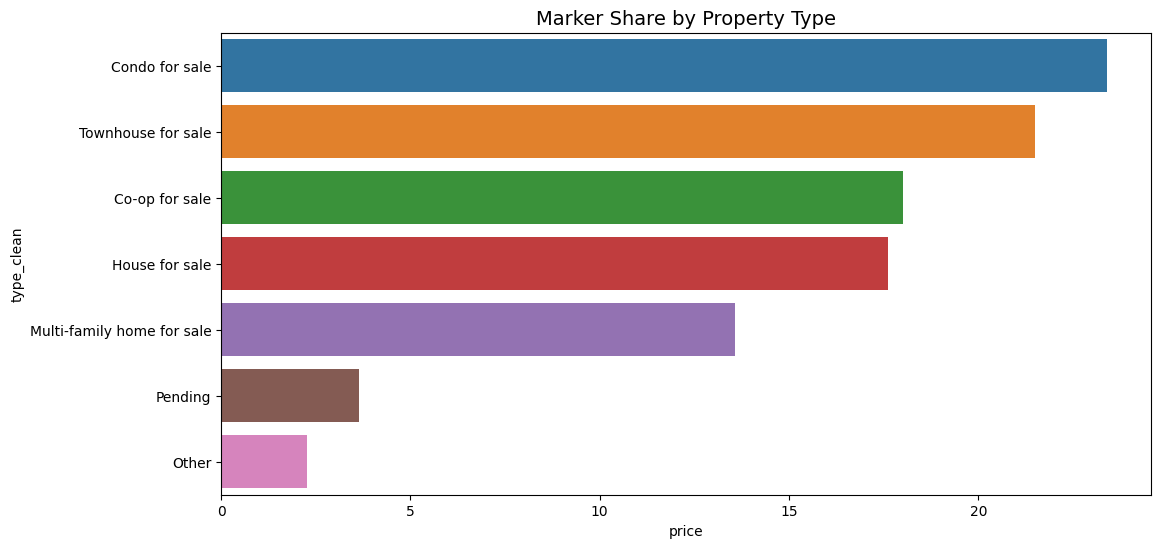

In [78]:
# Calculate market share by types
market_share = (df.groupby('type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='type_clean',
            hue='type_clean')
plt.title('Marker Share by Property Type', fontsize=14)
plt.show()

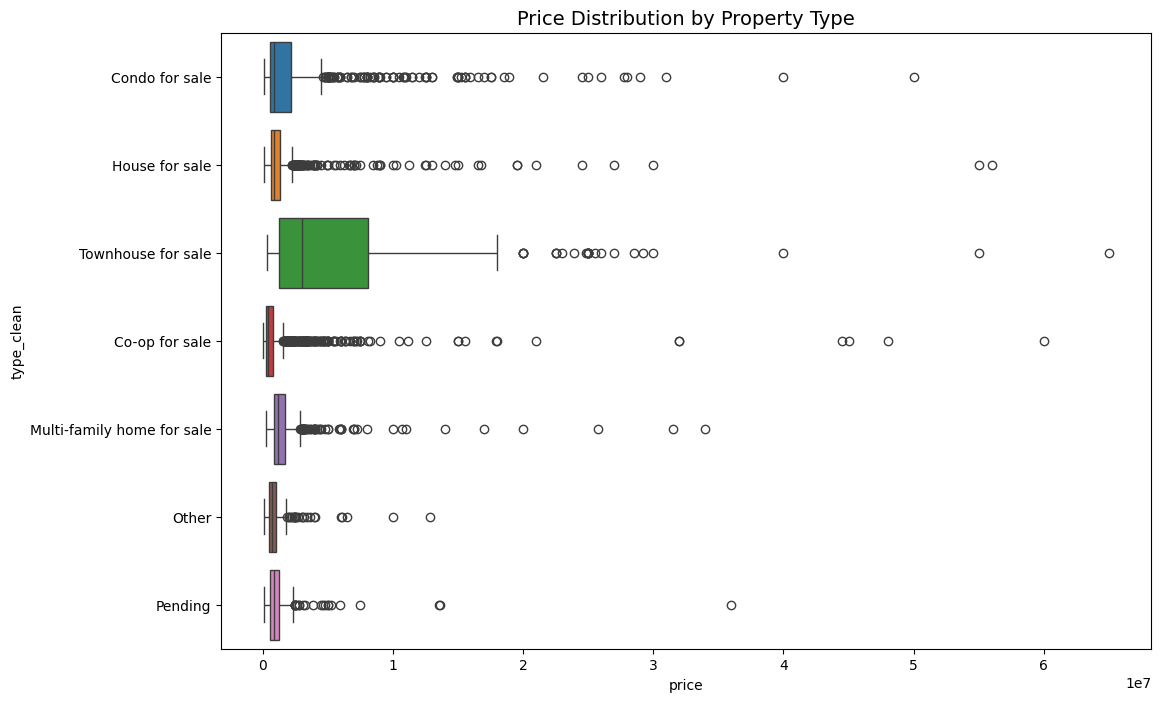

In [79]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='type_clean', hue='type_clean')
plt.title('Price Distribution by Property Type', fontsize=14)
plt.show()

In [80]:
# Create dummy variables with drop_first=True to avoid multicollinearity
# Avoids the dummy variable trap in linear regression models
type_dummies = pd.get_dummies(
    df['type_clean'],
    prefix='type',
    drop_first=True,  # Avoids dummy variable trap
    dtype=int         # Saves memory vs bool
)

# join back to original DataFrame
df = pd.concat([df, type_dummies], axis=1)

### _Beds_

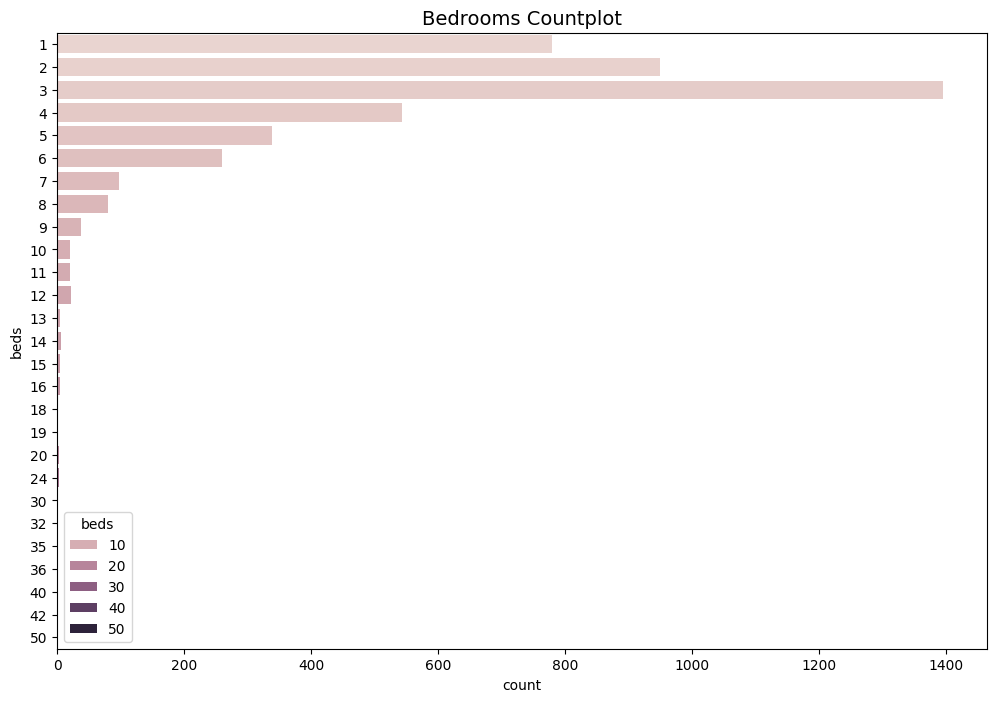

In [81]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='beds', hue='beds')
plt.title('Bedrooms Countplot', fontsize=14)
plt.show()

In [82]:
# Here we also have a skewed distribution

Text(0.5, 1.0, 'Price Distribution by Bedroom Count')

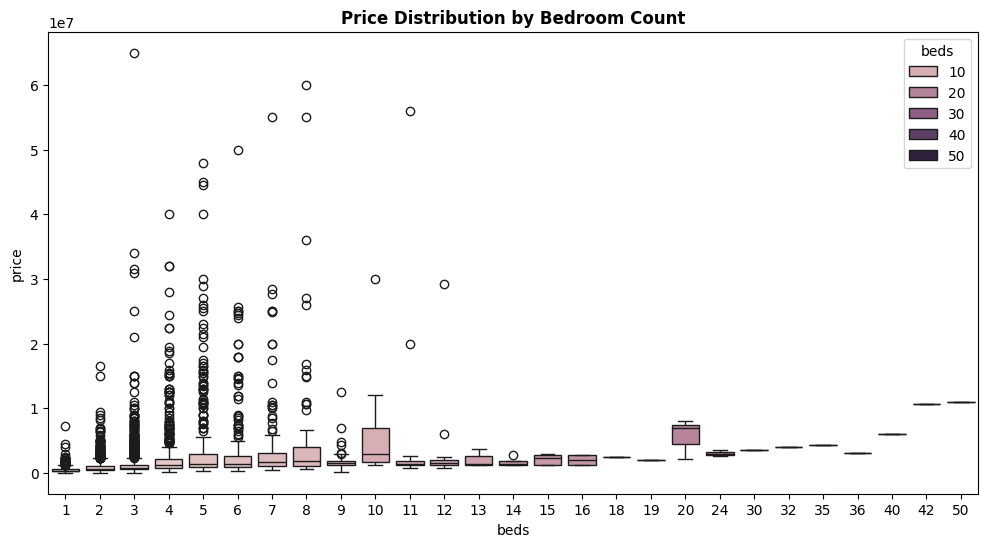

In [83]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=True,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [84]:
# Market doesn't following beds after 10-12 bedrooms. Most high priced properties have 1-8 bedrooms. So it's probably a good idea divide those groups

Text(0.5, 1.0, 'Price Distribution by Bedroom Count')

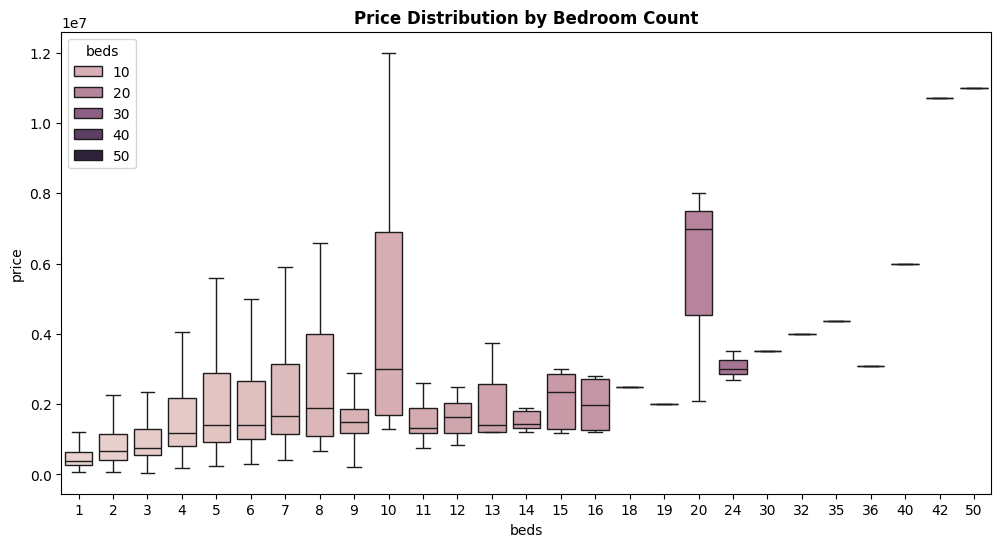

In [85]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=False,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [86]:
# Here we also see linear relation beds - price up to 10 bedrooms

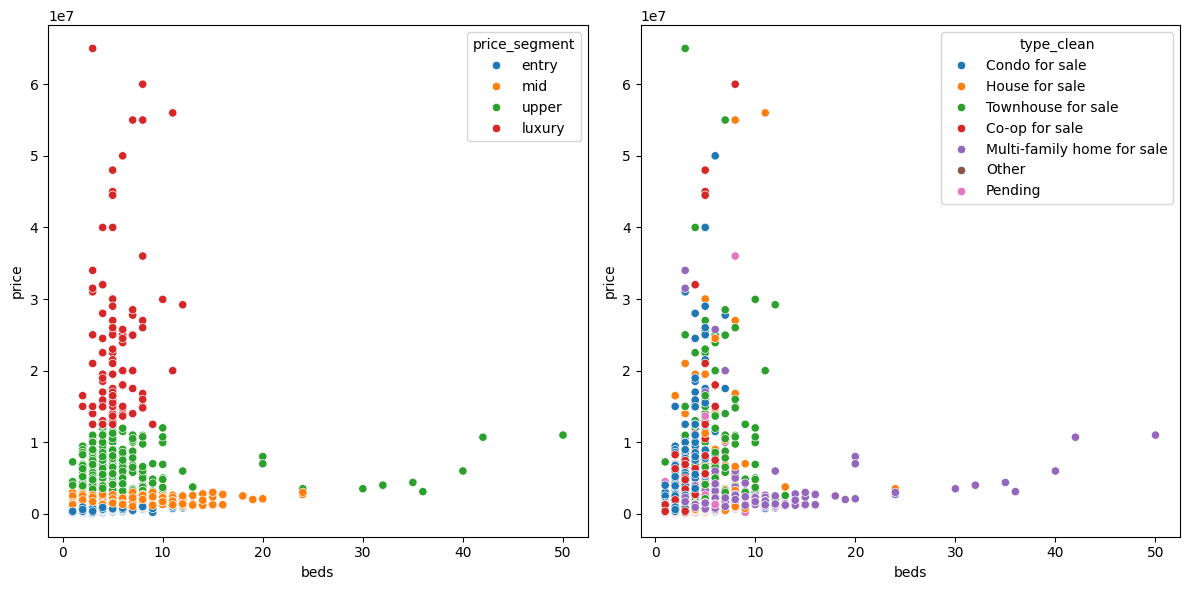

In [87]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='beds', y='price', hue='price_segment')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='beds', y='price', hue='type_clean')

plt.tight_layout()

In [88]:
# Those properties with high bedroom number are mostly multi-family homes

In [89]:
df[(df.type == 'Multi-family home for sale') & (df.beds > 12) ].price.describe()

count    3.100000e+01
mean     3.257803e+06
std      2.635191e+06
min      1.188888e+06
25%      1.337500e+06
50%      2.700000e+06
75%      3.299500e+06
max      1.100000e+07
Name: price, dtype: float64

In [90]:
# Need to mention that we CAN NOT use price segment for price modelling
# Probably later we will create a model to predict price segment and look what factors are significant

<Axes: xlabel='beds', ylabel='bath'>

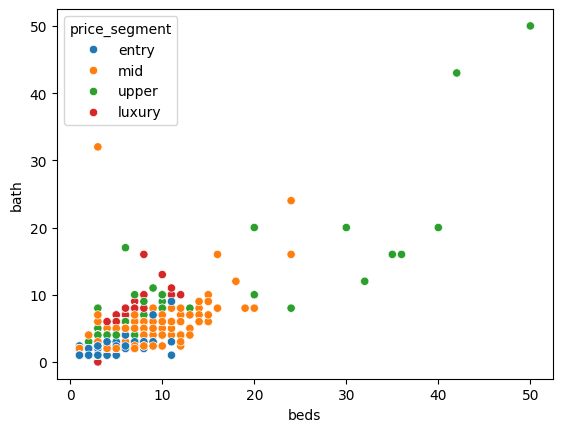

In [91]:
sns.scatterplot(data=df, x='beds', y='bath', hue='price_segment')

In [92]:
# ok, so no luxurios entries in high number bedroom segment

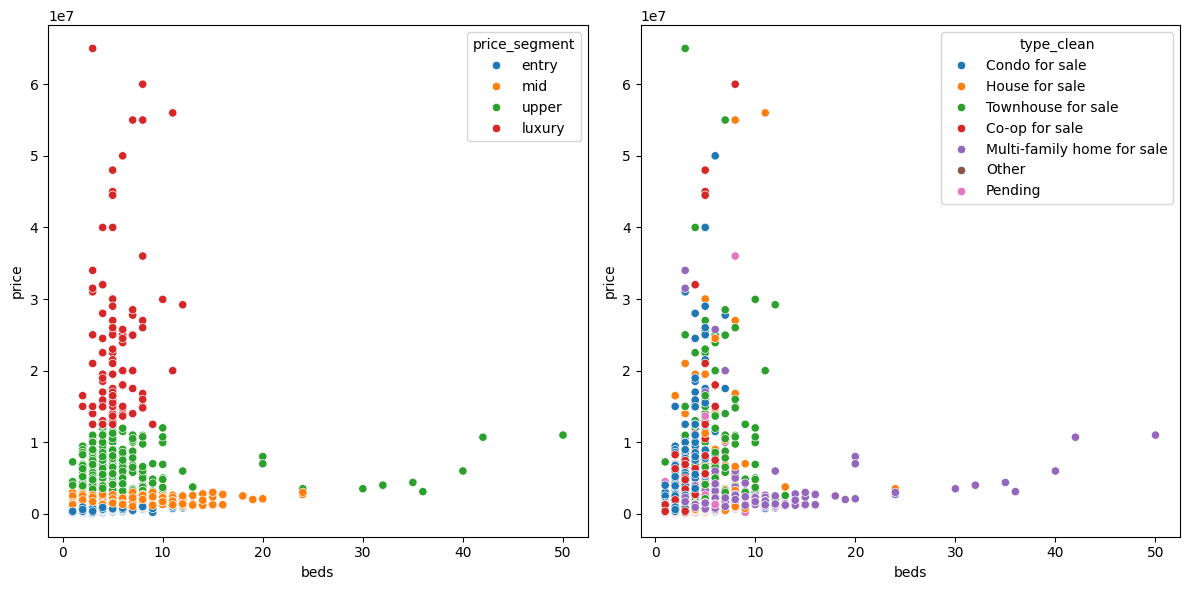

In [93]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='beds', y='price', hue='price_segment')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='beds', y='price', hue='type_clean')

plt.tight_layout()

In [94]:
df.beds.describe()

count    4582.000000
mean        3.364688
std         2.629057
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        50.000000
Name: beds, dtype: float64

In [95]:
df.beds.value_counts().sort_index()

beds
1      779
2      949
3     1395
4      544
5      339
6      260
7       98
8       81
9       38
10      21
11      20
12      22
13       5
14       6
15       5
16       4
18       1
19       1
20       3
24       3
30       1
32       2
35       1
36       1
40       1
42       1
50       1
Name: count, dtype: int64

<Axes: xlabel='beds', ylabel='count'>

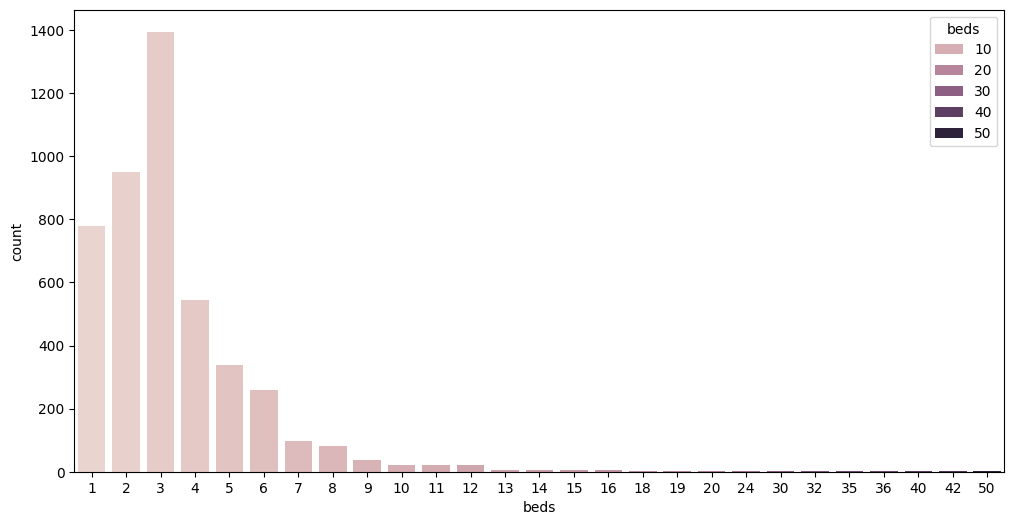

In [96]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='beds', hue='beds')

In [97]:
df['beds'].quantile(0.99)

np.float64(12.0)

In [98]:
# So 12 bedrooms seems as a good threshold

In [99]:
# Flag properties with >12 bedrooms
df['is_high_beds'] = (df['beds'] > 12).astype(int)

<Axes: xlabel='beds', ylabel='price'>

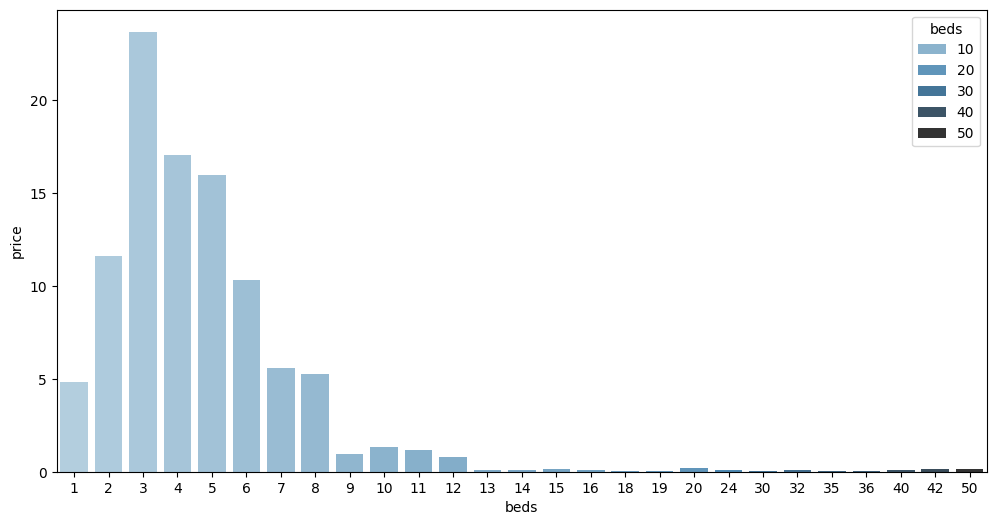

In [100]:
# Calculate market share by bedrooms
market_share = (df.groupby('beds')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

<Axes: xlabel='beds', ylabel='price'>

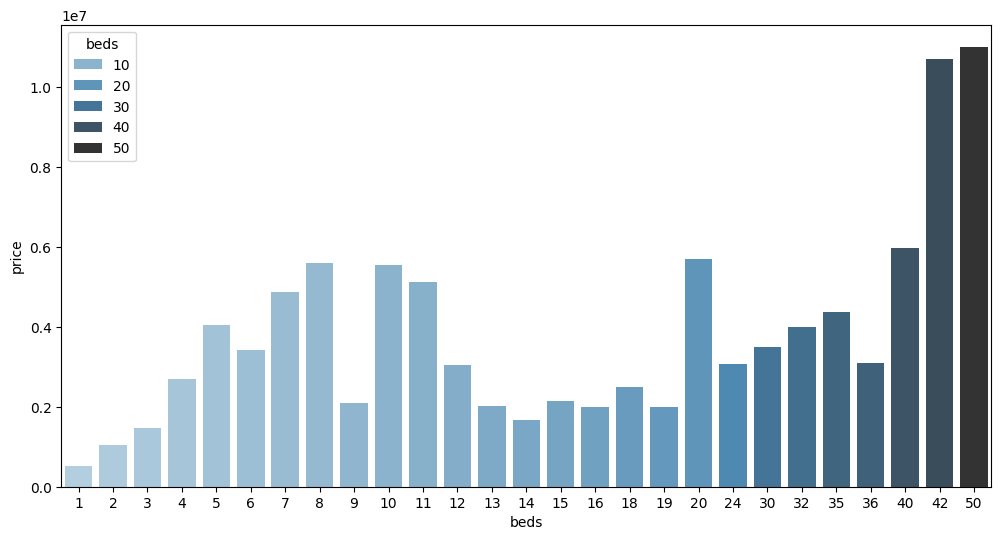

In [101]:
# Mean price dinamic based on number of bedrooms
market_share = (df.groupby('beds')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

In [102]:
# The 1-6 bedroom homes aren’t the most expensive, but they dominate the market – they make up nearly 90% of listings.

In [103]:
df['log_beds'] = np.log1p(df['beds'])

<Axes: xlabel='log_beds', ylabel='Count'>

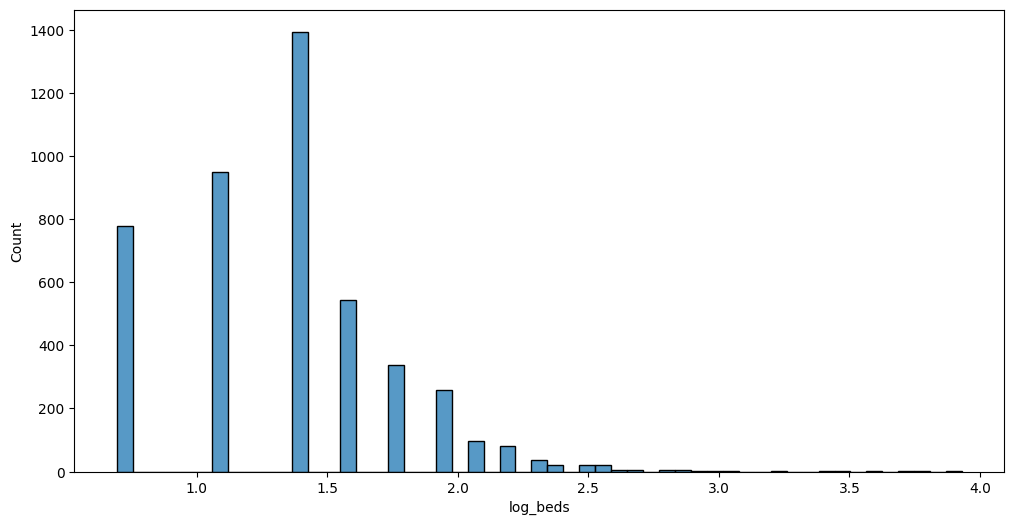

In [104]:
plt.figure(figsize=(12, 6))
sns.histplot(df.log_beds)

### Bath

<Axes: xlabel='count', ylabel='bath'>

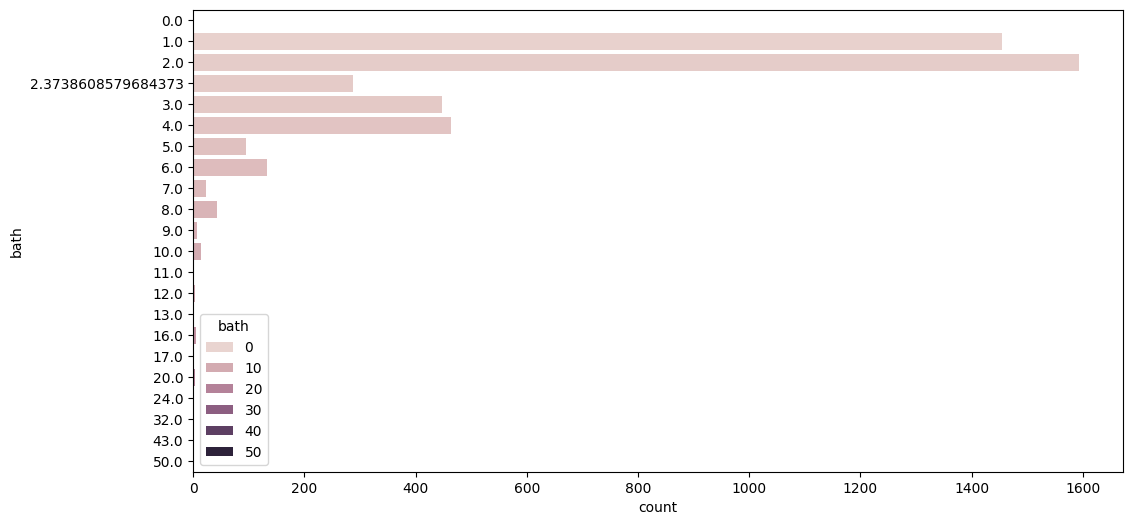

In [105]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='bath', hue='bath')

In [106]:
df.bath.value_counts()

bath
2.000000     1593
1.000000     1454
4.000000      464
3.000000      447
2.373861      287
6.000000      133
5.000000       95
8.000000       43
7.000000       23
10.000000      15
9.000000        7
16.000000       5
12.000000       3
20.000000       3
11.000000       2
0.000000        2
13.000000       1
32.000000       1
50.000000       1
24.000000       1
43.000000       1
17.000000       1
Name: count, dtype: int64

In [107]:
# TODO: Something about plugged in value

In [108]:
# Use a tolerance to identify the plugged values
TOLERANCE = 1e-6  # 0.000000001
df['bath_missing'] = np.where(np.abs(df['bath'] - 2.373861) < TOLERANCE, 1, 0)

# Verify you caught 288 items
print(df['bath_missing'].sum())  # Should be 288

# See the actual values
print(df[df['bath_missing'] == 1]['bath'].unique())

287
[2.37386086]


In [109]:
bath_median = df[df['bath_missing'] == 0]['bath'].median()
df.loc[df['bath_missing'] == 1, 'bath'] = bath_median
print(bath_median)

2.0


In [110]:
df.bath.value_counts()

bath
2.0     1880
1.0     1454
4.0      464
3.0      447
6.0      133
5.0       95
8.0       43
7.0       23
10.0      15
9.0        7
16.0       5
12.0       3
20.0       3
11.0       2
0.0        2
13.0       1
32.0       1
50.0       1
24.0       1
43.0       1
17.0       1
Name: count, dtype: int64

In [111]:
df.bath = df.bath.astype(int)

Text(0.5, 1.0, 'Price Distribution by Bathroom Count')

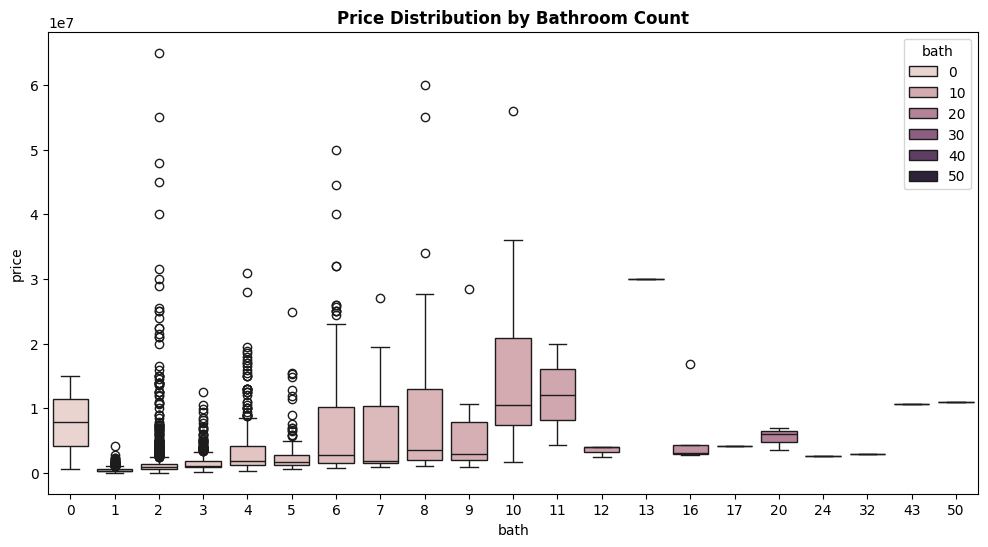

In [112]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='bath',
    y='price',
    showfliers=True,
    hue='bath'
)
#plt.yscale('log')
plt.title('Price Distribution by Bathroom Count', fontweight='bold')

<Axes: ylabel='bath'>

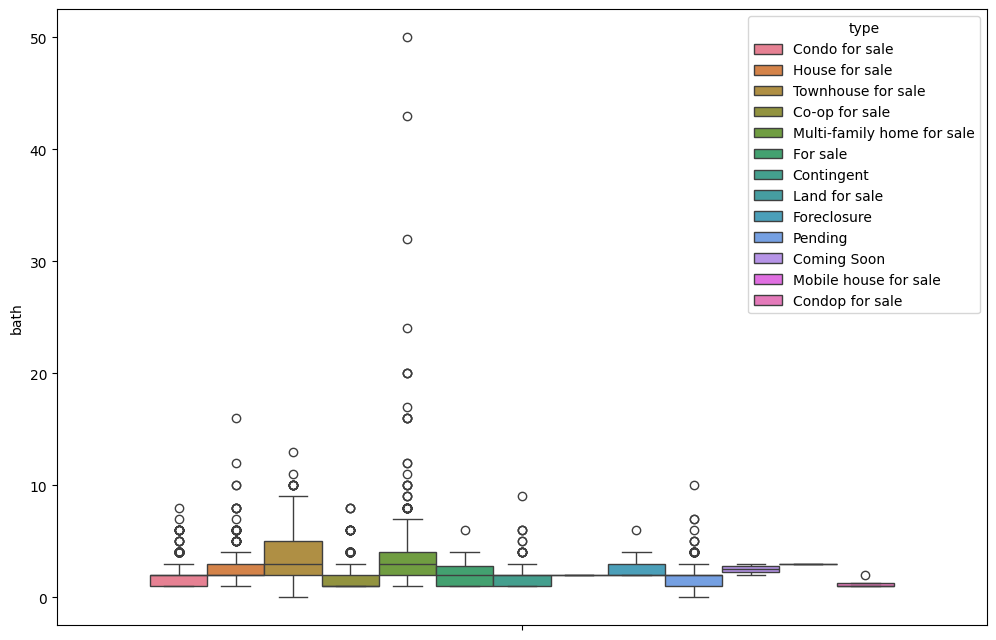

In [113]:
plt.figure(figsize=(12, 8))
sns.boxplot(df,y='bath', hue='type')

<Axes: xlabel='bath', ylabel='log_price'>

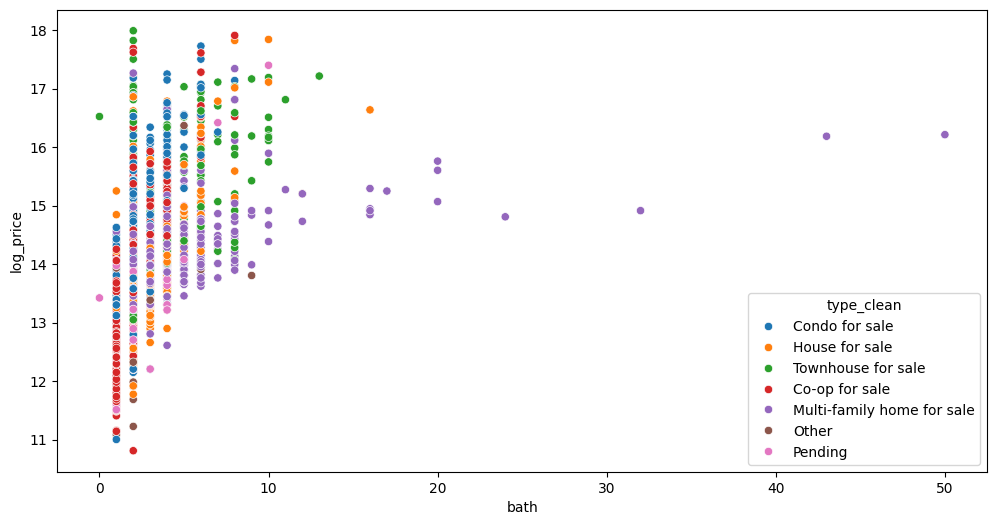

In [114]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='bath', y='log_price', hue='type_clean')

<Axes: xlabel='bath', ylabel='price'>

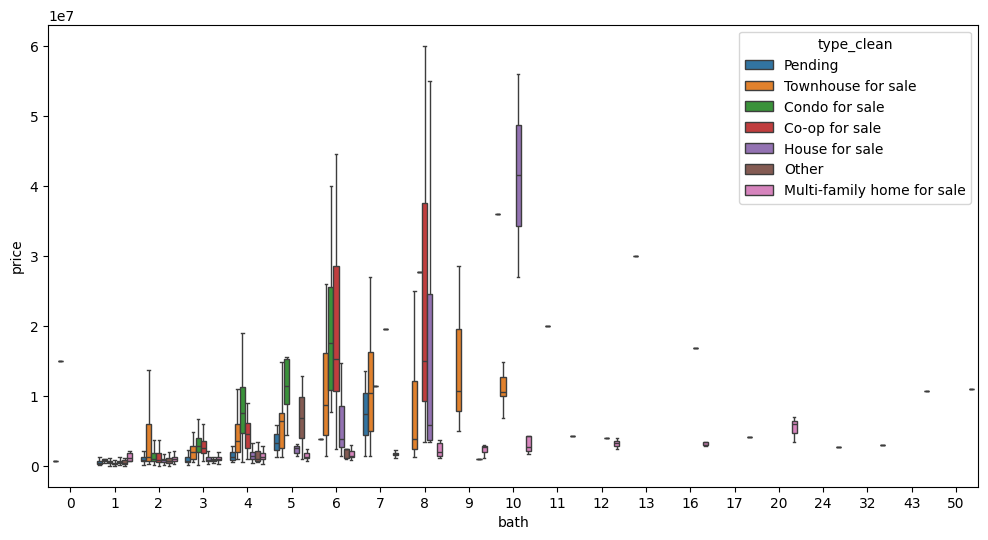

In [115]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='price', hue='type_clean', showfliers=False)

<Axes: xlabel='bath', ylabel='log_price'>

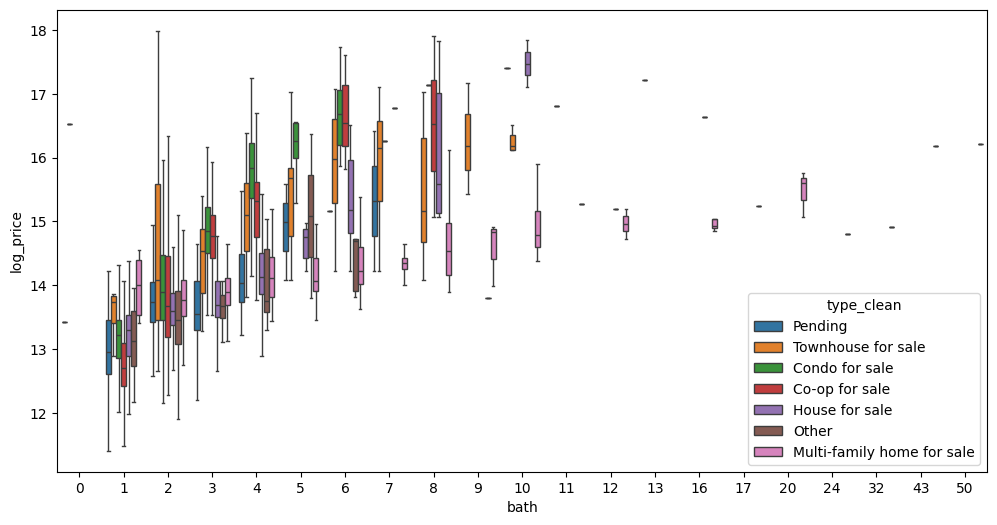

In [116]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='log_price', hue='type_clean', showfliers=False)

<Axes: xlabel='bath', ylabel='price'>

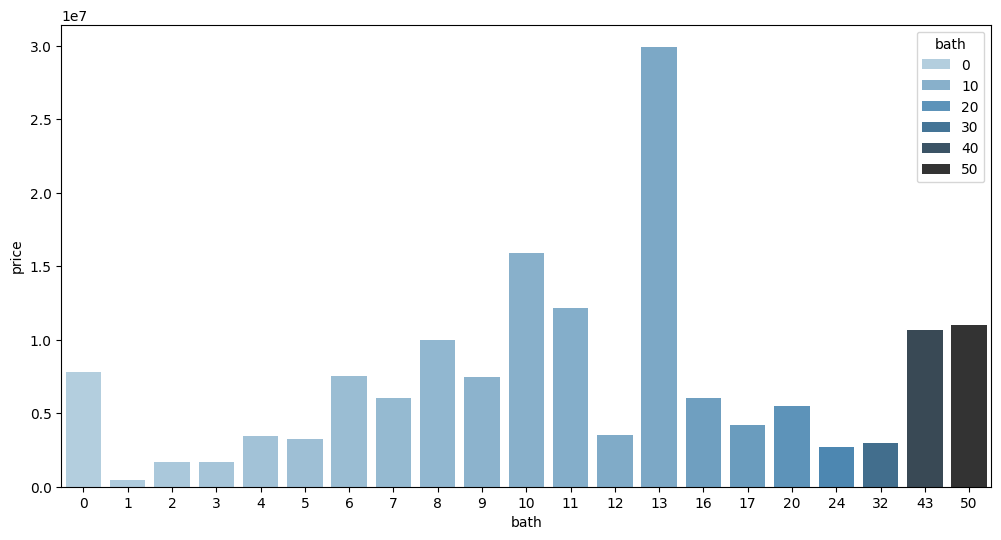

In [117]:
# Mean price dinamic based on number of bathrooms
market_share = (df.groupby('bath')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='bath',
            hue='bath',
            palette='Blues_d')

In [118]:
df['log_bath'] = np.log1p(df.bath)

<Axes: xlabel='log_beds', ylabel='Count'>

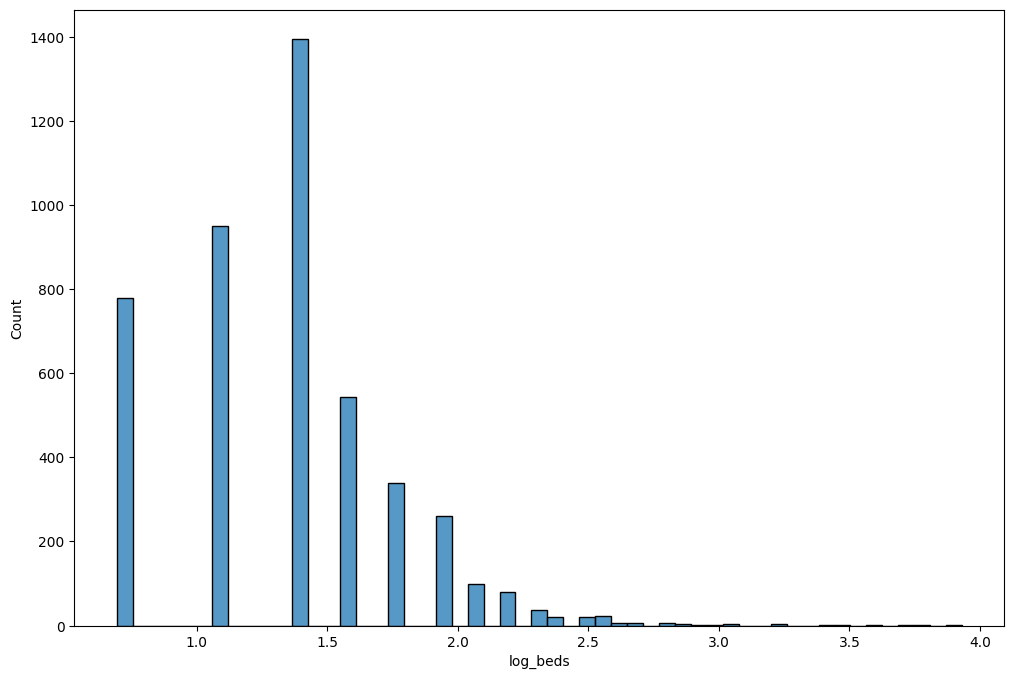

In [119]:
plt.figure(figsize=(12, 8))
sns.histplot(df.log_beds)

### *Propertysqft*

<Axes: xlabel='propertysqft', ylabel='Count'>

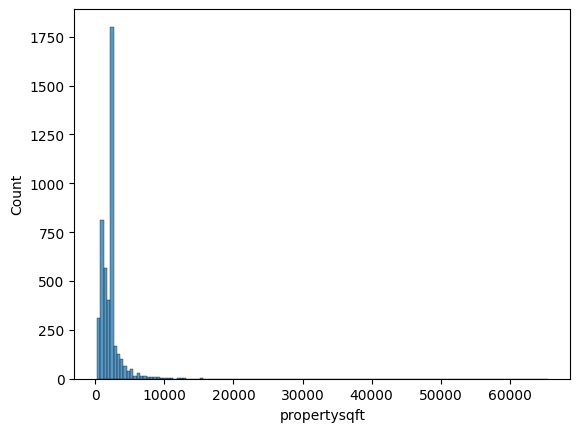

In [120]:
sns.histplot(df.propertysqft)

In [121]:
df.propertysqft.value_counts()

propertysqft
2184.207862     1536
800.000000        54
900.000000        51
750.000000        51
1200.000000       48
                ... 
2002.000000        1
2090.000000        1
886.000000         1
2367.000000        1
12733.000000       1
Name: count, Length: 1444, dtype: int64

In [122]:
df.propertysqft.describe()

count     4582.000000
mean      2172.647158
std       2270.083992
min        230.000000
25%       1200.000000
50%       2184.207862
75%       2184.207862
max      65535.000000
Name: propertysqft, dtype: float64

In [123]:
# The value 2184.207862 appears to have been used as a substitute for missing values.

In [124]:
df[df.propertysqft!=2184.207862].propertysqft.describe()

count     3046.000000
mean      2166.817466
std       2784.361263
min        230.000000
25%        953.500000
50%       1495.500000
75%       2455.000000
max      65535.000000
Name: propertysqft, dtype: float64

In [125]:
# On the dataset without 2184.207862, the median is 1495.50. I’ll impute missing values with this median and mark them with the area_missing flag.

In [126]:
df['area_missing'] = np.where(df['propertysqft'] == 2184.207862, 1, 0)

In [127]:
df['area_missing'].value_counts()

area_missing
0    3046
1    1536
Name: count, dtype: int64

In [128]:
df['propertysqft'] = np.where(df['area_missing'] == 1, 1495.512345, df['propertysqft'])

<Axes: xlabel='price', ylabel='type_clean'>

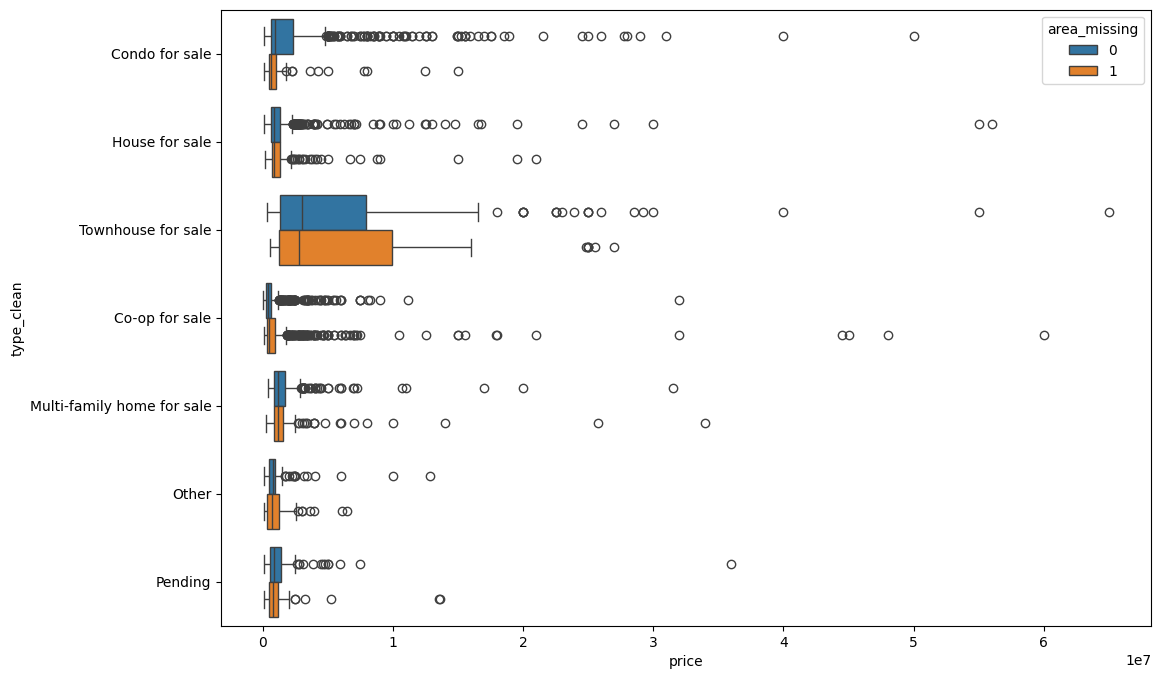

In [129]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, y='type_clean', x='price', hue='area_missing')

In [130]:
# Do not see here significal disproportions

In [131]:
df.propertysqft.describe()

count     4582.000000
mean      1941.779346
std       2292.087025
min        230.000000
25%       1200.000000
50%       1495.512345
75%       1887.750000
max      65535.000000
Name: propertysqft, dtype: float64

<Axes: ylabel='propertysqft'>

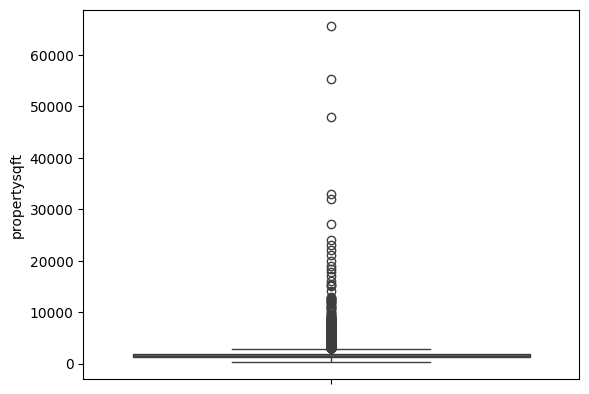

In [132]:
sns.boxplot(df.propertysqft)

<Axes: xlabel='propertysqft', ylabel='Count'>

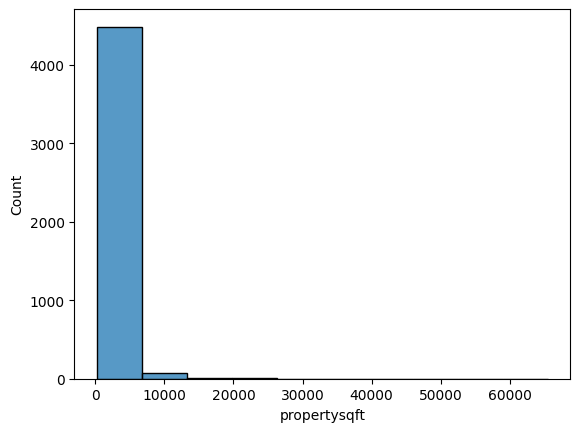

In [133]:
sns.histplot(df.propertysqft, bins=10)

In [134]:
df['propertysqft'].quantile(0.995)

np.float64(12513.660000000058)

In [135]:
# Propertysqft data looks highly skewed. I'll apply log transform to compensate

In [136]:
df['log_area'] = np.log1p(df.propertysqft)

<Axes: xlabel='log_area', ylabel='Count'>

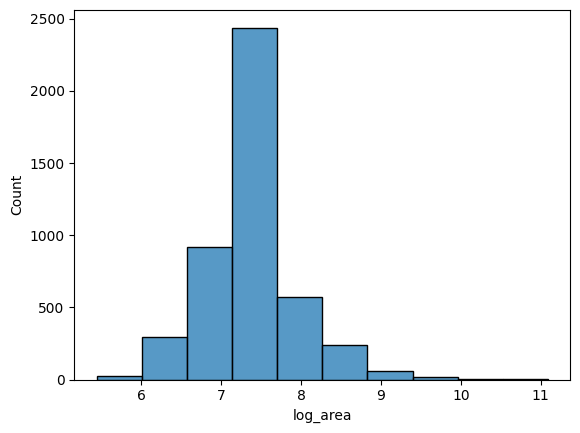

In [137]:
sns.histplot(df.log_area, bins=10)

<Axes: xlabel='log_area', ylabel='log_price'>

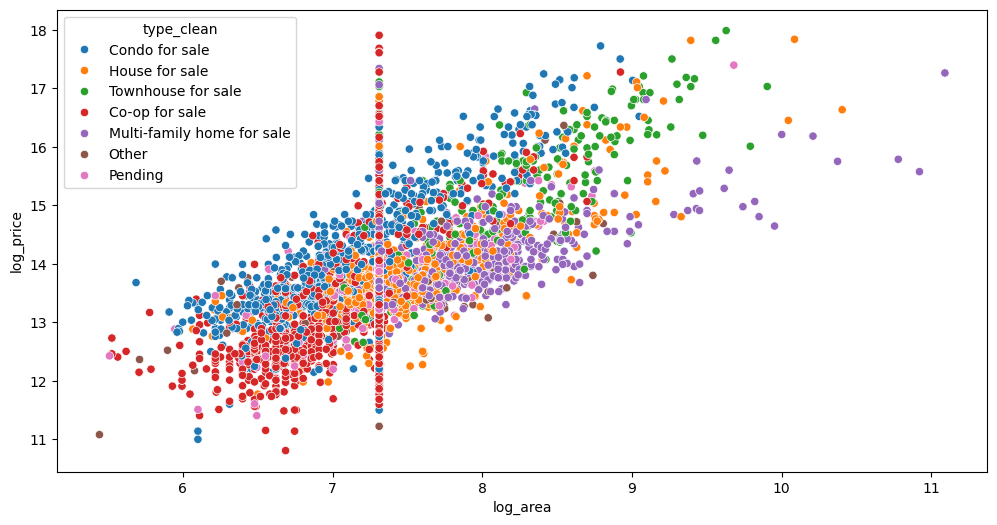

In [138]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='log_area', y='log_price', hue='type_clean')

In [139]:
# In this graph, we can observe data clustering. The vertical line of dots corresponds to the substituted value that was used 
# to fill in missing entries. The most expensive properties across all area ranges are condos.

<Axes: xlabel='count', ylabel='type_clean'>

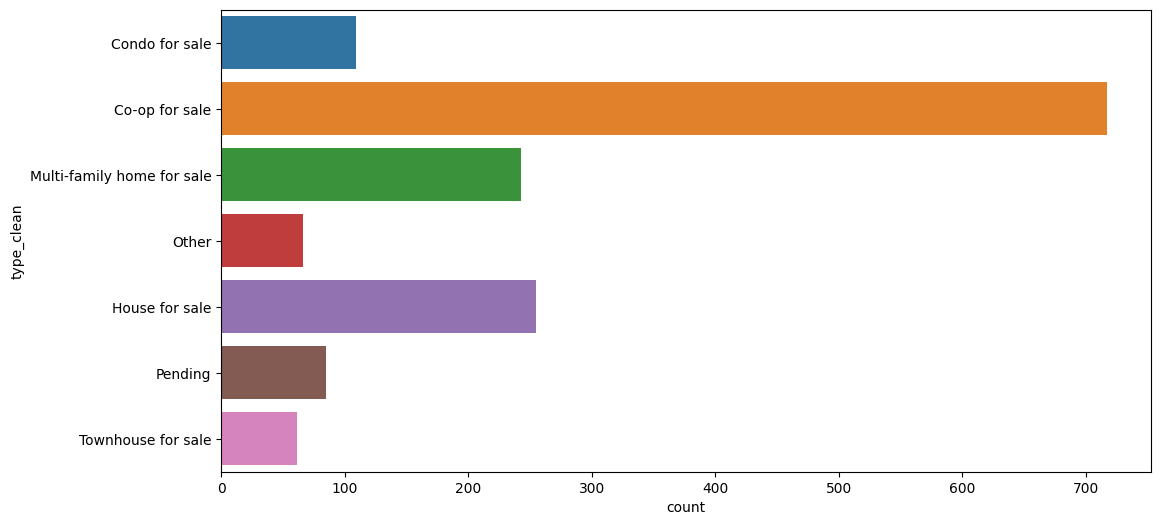

In [140]:
plt.figure(figsize=(12, 6))
sns.countplot(df[df.area_missing==True], y='type_clean', hue='type_clean')

<Axes: xlabel='type_clean', ylabel='price'>

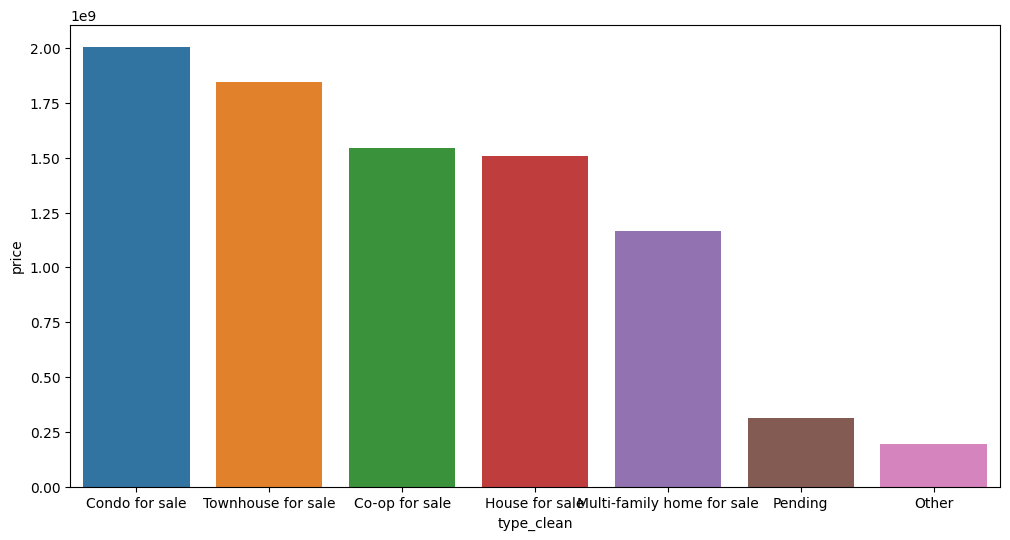

In [141]:
# Mean price dinamic based on type
market_share = (df.groupby('type_clean')['price'].sum()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='type_clean',
            hue='type_clean')

<Axes: xlabel='type_clean', ylabel='price'>

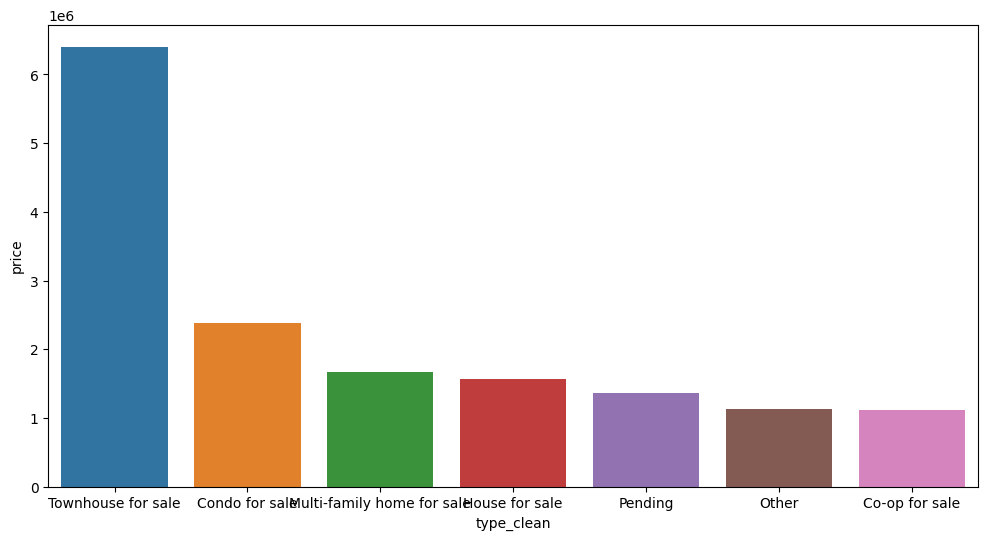

In [142]:
# Mean price dinamic based on type
market_share = (df.groupby('type_clean')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='type_clean',
            hue='type_clean')

In [143]:
# Most properites with missed values are co-op, and that item has the least mean price. So those missing properties shouldn't
# distort upper market.

### All address data

In [144]:
address_columns = ['address', 'state',
       'main_address', 'administrative_area_level_2', 'locality',
       'sublocality', 'street_name', 'long_name', 'formatted_address']

In [145]:
df[address_columns].head(7)

,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address
0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N..."
1,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA"
2,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA"
3,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA"
4,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA"
5,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA"
6,177 Benedict Rd,"Staten Island, NY 10304","177 Benedict RdStaten Island, NY 10304",United States,New York,Richmond County,Staten Island,Benedict Road,"177 Benedict Rd, Staten Island, NY 10304, USA"


In [146]:
# Address and formatted address probably should be dropped.

In [147]:
# State contain zip. Could be usefull

In [148]:
df['zip'] = df['state'].str[-5:]

# Filter invalid ZIPs (e.g., non-numeric)
df['zip'] = df['zip'].where(df['zip'].str.isdigit())

In [149]:
df.zip.isna().sum()

np.int64(0)

In [150]:
df.zip.value_counts()

zip
11375    102
11235    100
11209     91
11234     89
10314     81
        ... 
11040      1
11364      1
10455      1
10282      1
11416      1
Name: count, Length: 178, dtype: int64

In [151]:
df.state.value_counts()

state
Brooklyn, NY 11235            99
Brooklyn, NY 11209            91
Forest Hills, NY 11375        88
Brooklyn, NY 11234            86
Staten Island, NY 10314       80
                              ..
Ditmas Park, NY 11226          1
Jackson Heights, NY 11370      1
New York, NY 10282             1
Long Island City, NY 11106     1
Ozone Park, NY 11416           1
Name: count, Length: 307, dtype: int64

In [152]:
df.administrative_area_level_2.value_counts()

administrative_area_level_2
United States      2372
New York           2135
New York County      21
11214                 8
Kings County          6
Queens County         6
Bronx County          4
11229                 3
10003                 2
10017                 2
10310                 2
10471                 2
10306                 2
10002                 2
11414                 1
11417                 1
11234                 1
10309                 1
10301                 1
10303                 1
10463                 1
10304                 1
10312                 1
10465                 1
11412                 1
Brooklyn              1
10466                 1
11237                 1
11218                 1
Name: count, dtype: int64

In [153]:
# Messy feature, better should use borough

In [154]:
#locality	sublocality	street_name	long_name

In [155]:
df.locality.value_counts()

locality
New York           2393
New York County     928
Queens County       536
Kings County        441
Bronx County        172
Richmond County      58
United States        37
Queens                6
Brooklyn              6
The Bronx             4
Flatbush              1
Name: count, dtype: int64

In [156]:
df.sublocality.value_counts()

sublocality
New York            965
Kings County        696
Queens County       655
Queens              534
Richmond County     460
Brooklyn            441
Bronx County        291
New York County     270
The Bronx           174
Staten Island        58
Manhattan            21
Flushing              4
Coney Island          3
Riverdale             3
East Bronx            1
Jackson Heights       1
Brooklyn Heights      1
Rego Park             1
Fort Hamilton         1
Dumbo                 1
Snyder Avenue         1
Name: count, dtype: int64

In [157]:
df.street_name.value_counts()

street_name
Manhattan          928
Brooklyn           696
Queens             655
Staten Island      460
The Bronx          294
                  ... 
2501                 1
67th Drive           1
Todt Hill            1
Saunders Street      1
Mount Eden           1
Name: count, Length: 174, dtype: int64

In [158]:
df.long_name.value_counts()

long_name
2                   19
200                 18
100                 18
50                  15
40                  14
                    ..
65th Road            1
7666                 1
Kenmore Court        1
Corbin Avenue        1
West 87th Street     1
Name: count, Length: 2729, dtype: int64

In [159]:
address_columns

['address',
 'state',
 'main_address',
 'administrative_area_level_2',
 'locality',
 'sublocality',
 'street_name',
 'long_name',
 'formatted_address']

In [160]:
df = df.drop(columns=address_columns)

In [161]:
# Reset index after cleaning
df = df.reset_index(drop=True)

### Add boroughs

In [162]:
boroughs_file = '../data/nyc_boroughs.geojson'

In [163]:
gdf_boroughs = gpd.read_file(boroughs_file)

<Axes: >

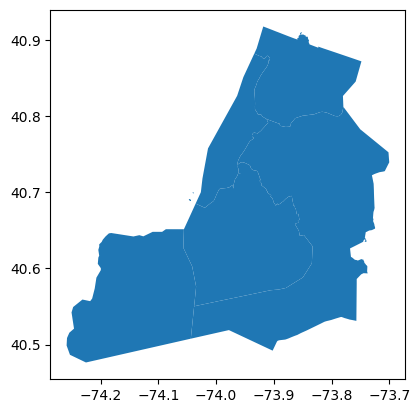

In [164]:
gdf_boroughs.plot()

In [165]:
gdf_boroughs

,name,geometry
0,The Bronx,"MULTIPOLYGON (((-73.93263 40.81897, -73.93274 ..."
1,Brooklyn,"MULTIPOLYGON (((-73.99426 40.70403, -73.99341 ..."
2,Queens,"MULTIPOLYGON (((-73.76604 40.7984, -73.75637 4..."
3,Manhattan,"MULTIPOLYGON (((-74.03993 40.69859, -74.04008 ..."
4,Staten Island,"MULTIPOLYGON (((-74.03805 40.55034, -74.03634 ..."


In [166]:
gdf_houses = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs=gdf_boroughs.crs
)

In [167]:
df_with_borough = gpd.sjoin(
    gdf_houses,
    gdf_boroughs[['name', 'geometry']],  # Only keep needed columns
    how='left',
    predicate='within'
)

In [168]:
df_with_borough

,brokertitle,type,price,beds,bath,propertysqft,latitude,longitude,is_upper,is_mid,...,is_high_beds,log_beds,bath_missing,log_bath,area_missing,log_area,zip,geometry,index_right,name
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2,1400.000000,40.761255,-73.974483,0,0,...,0,1.098612,0,1.098612,0,7.244942,10022,POINT (-73.97448 40.76126),3,Manhattan
1,Brokered by Sowae Corp,House for sale,260000,4,2,2015.000000,40.541805,-74.196109,0,0,...,0,1.609438,0,1.098612,0,7.608871,10312,POINT (-74.19611 40.54181),4,Staten Island
2,Brokered by COMPASS,Condo for sale,69000,3,1,445.000000,40.761398,-73.974613,0,0,...,0,1.386294,0,0.693147,0,6.100319,10022,POINT (-73.97461 40.7614),3,Manhattan
3,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2,14175.000000,40.767224,-73.969856,1,0,...,0,2.079442,1,1.098612,0,9.559306,10065,POINT (-73.96986 40.76722),3,Manhattan
4,Brokered by Sowae Corp,House for sale,690000,5,2,4004.000000,40.674363,-73.958725,0,0,...,0,1.791759,0,1.098612,0,8.295299,11238,POINT (-73.95872 40.67436),1,Brooklyn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4577,Brokered by COMPASS,Co-op for sale,599000,1,1,1495.512345,40.774350,-73.955879,0,0,...,0,0.693147,0,0.693147,1,7.310893,10075,POINT (-73.95588 40.77435),3,Manhattan
4578,Brokered by Mjr Real Estate Llc,Co-op for sale,245000,1,1,1495.512345,40.732538,-73.860152,0,0,...,0,0.693147,0,0.693147,1,7.310893,11374,POINT (-73.86015 40.73254),2,Queens
4579,Brokered by Douglas Elliman - 575 Madison Ave,Co-op for sale,1275000,1,1,1495.512345,40.745882,-74.003398,0,1,...,0,0.693147,0,0.693147,1,7.310893,10011,POINT (-74.0034 40.74588),3,Manhattan
4580,Brokered by E Realty International Corp,Condo for sale,598125,2,1,655.000000,40.742770,-73.872752,0,0,...,0,1.098612,0,0.693147,0,6.486161,11373,POINT (-73.87275 40.74277),2,Queens


In [169]:
df['borough'] = df_with_borough['name']

In [170]:
df['borough'].isna().sum()

np.int64(0)

In [171]:
# Nothing missing

<Axes: xlabel='longitude', ylabel='latitude'>

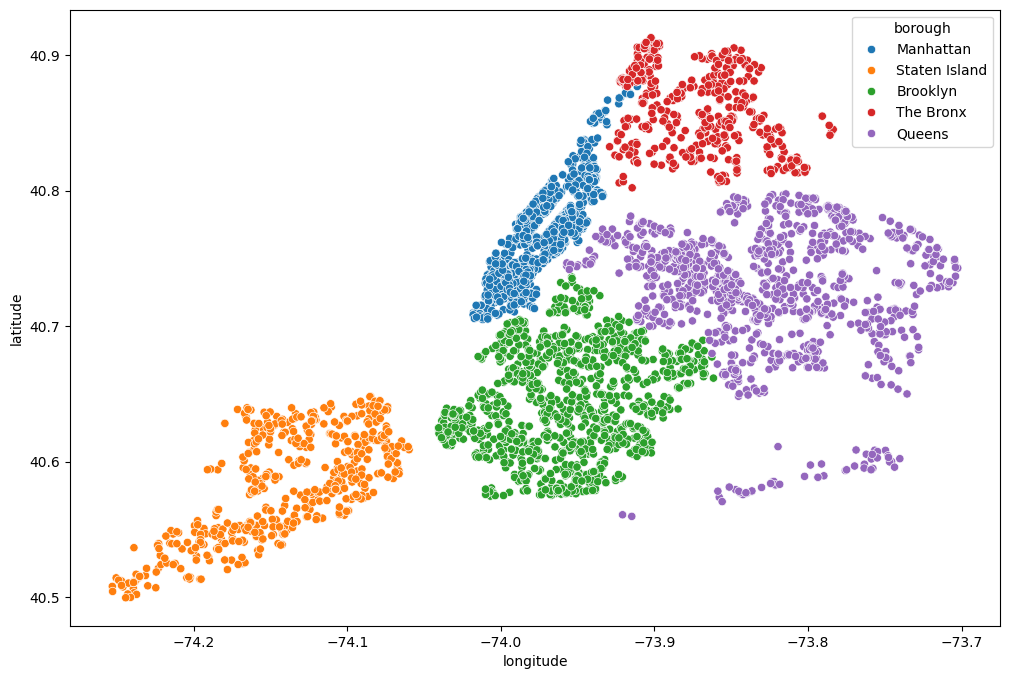

In [172]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="borough", data=df)

In [173]:
# Looks great!

<Axes: xlabel='price', ylabel='borough'>

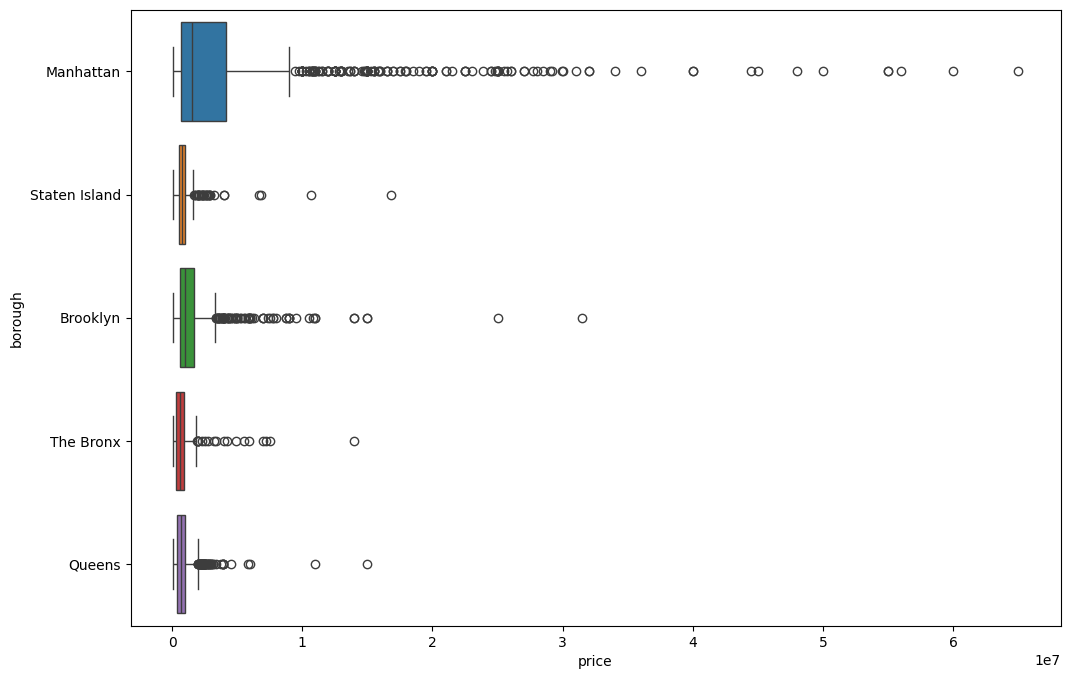

In [174]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='borough', hue='borough')

<Axes: xlabel='log_price', ylabel='borough'>

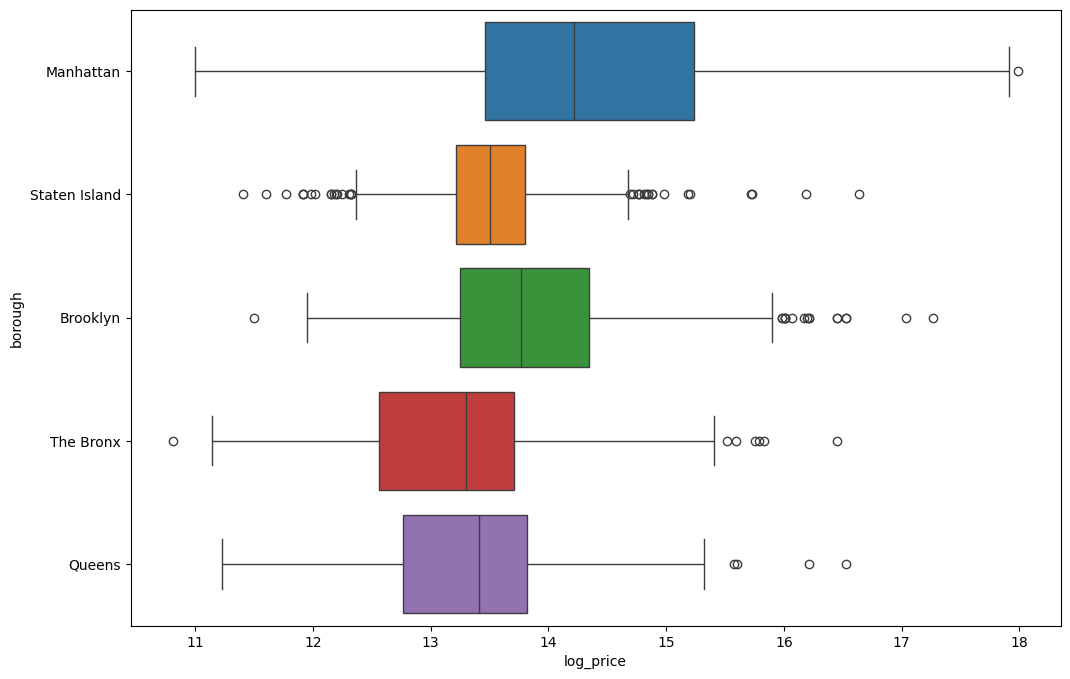

In [175]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='log_price', y='borough', hue='borough')

In [176]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'latitude', 'longitude', 'is_upper', 'is_mid', 'is_luxury',
       'price_segment', 'log_price', 'broker_count', 'luxury_score',
       'is_top_luxury_broker', 'type_clean', 'type_Condo for sale',
       'type_House for sale', 'type_Multi-family home for sale', 'type_Other',
       'type_Pending', 'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'bath_missing', 'log_bath', 'area_missing', 'log_area', 'zip',
       'borough'],
      dtype='object')

<Axes: xlabel='beds', ylabel='borough'>

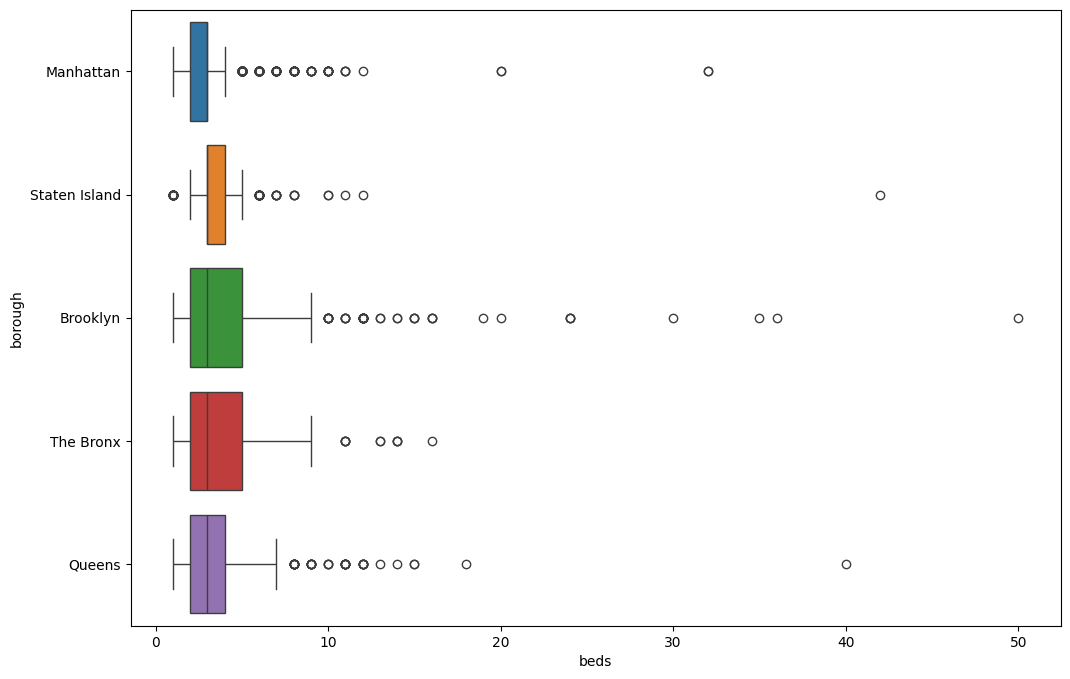

In [177]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='beds', y='borough', hue='borough')

<Axes: xlabel='bath', ylabel='borough'>

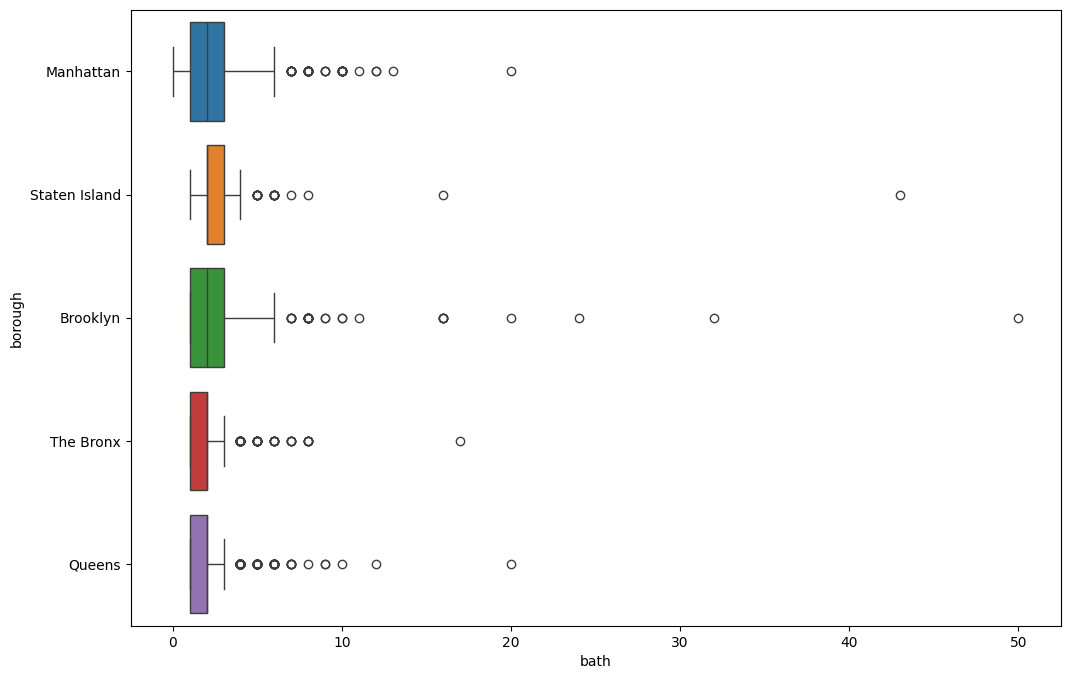

In [178]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='bath', y='borough', hue='borough')

<Axes: xlabel='borough', ylabel='count'>

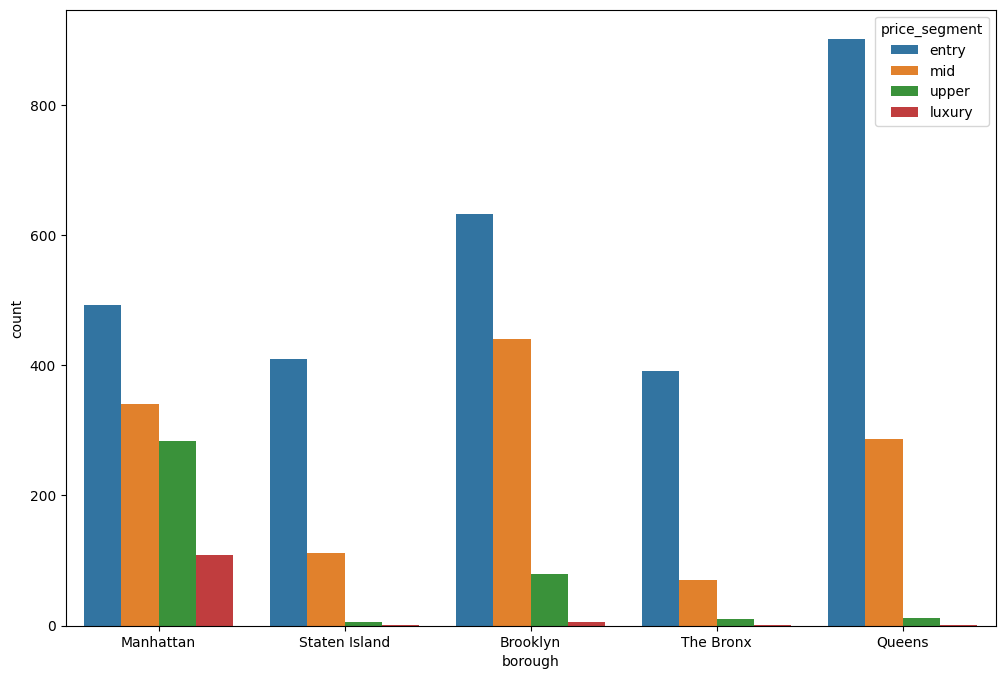

In [179]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='borough', hue='price_segment')

<Axes: xlabel='borough', ylabel='price'>

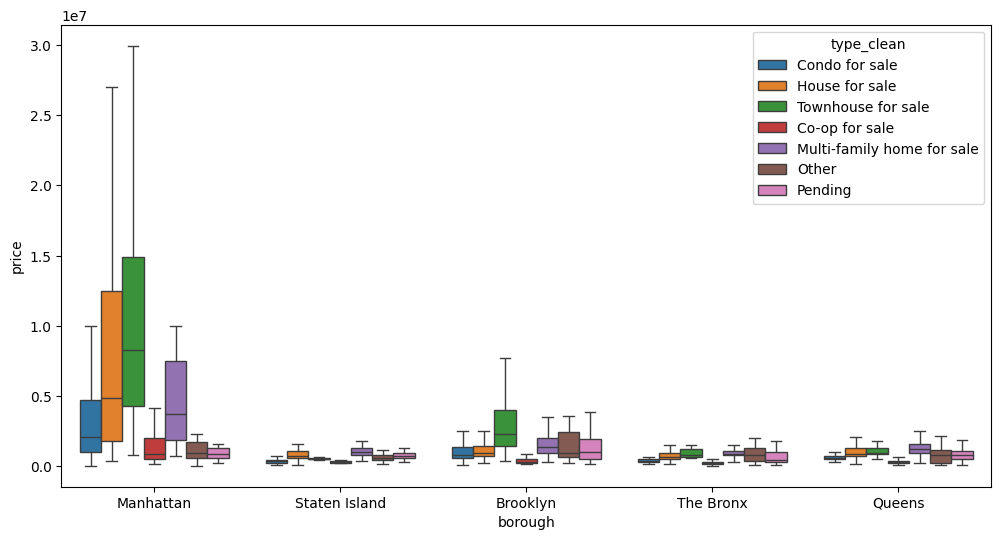

In [180]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='borough', y='price', hue='type_clean', showfliers=False)

<Axes: xlabel='count', ylabel='borough'>

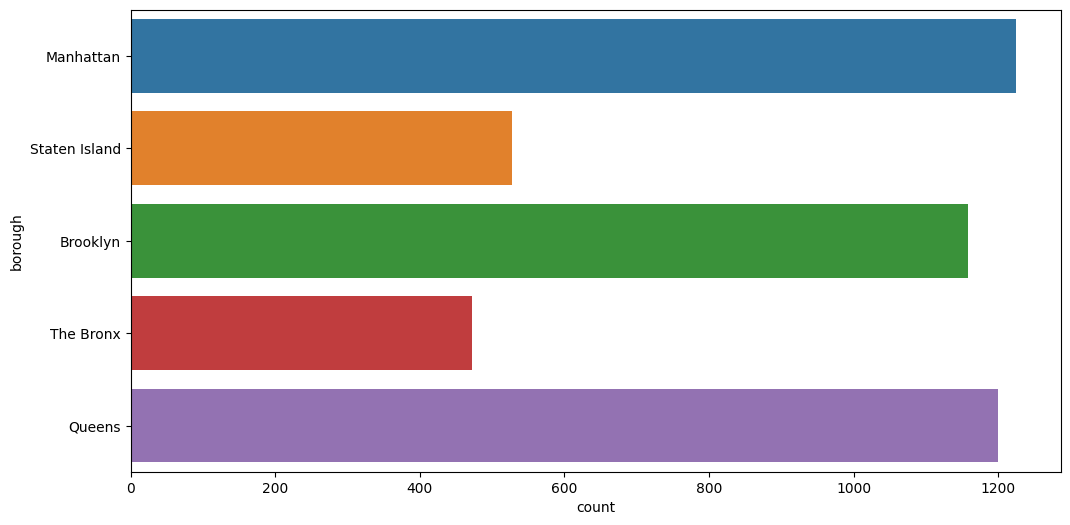

In [181]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='borough', hue='borough')

<Axes: xlabel='price', ylabel='borough'>

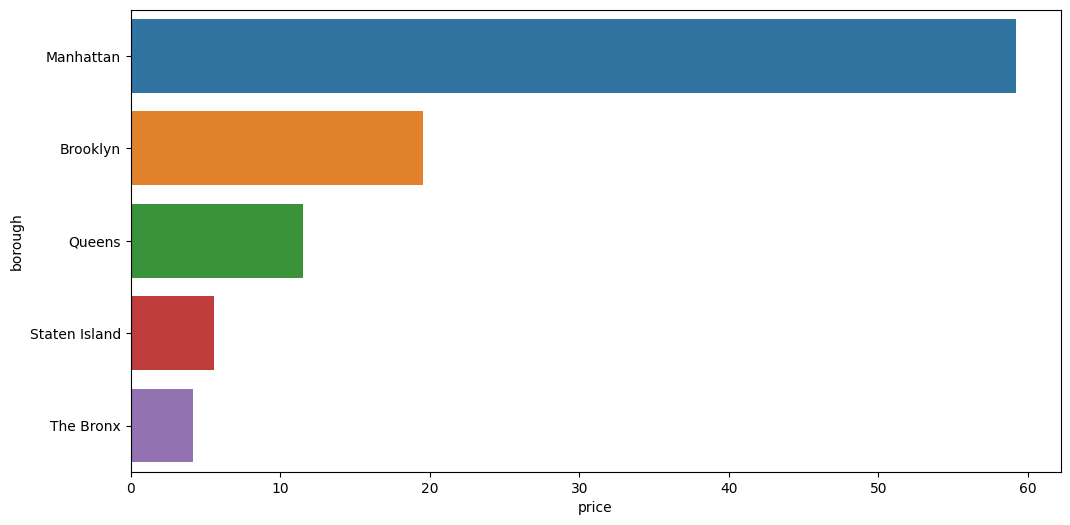

In [182]:
# Calculate market share by types
market_share = (df.groupby('borough')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='borough',
           hue='borough')

In [183]:
# Ok, those plots confirm what we already know, all the money is in Manhattan.

In [184]:
df.borough.value_counts()

borough
Manhattan        1225
Queens           1200
Brooklyn         1158
Staten Island     527
The Bronx         472
Name: count, dtype: int64

In [185]:
# Enconding for boroughs. Only top boroughs
borough_dummies = pd.get_dummies(df['borough'], prefix='borough')

top_boroughs = ['borough_Manhattan', 'borough_Brooklyn', 'borough_Queens']
df = pd.concat([df, borough_dummies[top_boroughs]], axis=1)

In [186]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'latitude', 'longitude', 'is_upper', 'is_mid', 'is_luxury',
       'price_segment', 'log_price', 'broker_count', 'luxury_score',
       'is_top_luxury_broker', 'type_clean', 'type_Condo for sale',
       'type_House for sale', 'type_Multi-family home for sale', 'type_Other',
       'type_Pending', 'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'bath_missing', 'log_bath', 'area_missing', 'log_area', 'zip',
       'borough', 'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens'],
      dtype='object')

In [187]:
print(np.log(60_000_000))
print(np.log(30_000_000))
print(np.log(10_000_000))
print(np.log(2_000_000))
print(np.log(1_000_000))
print(np.log(500_000))

17.909855120186375
17.216707939626428
16.11809565095832
14.508657738524219
13.815510557964274
13.122363377404328


In [188]:
### Add price_per_sqft

In [189]:
df['price_per_sqft'] = df.price/df.propertysqft

In [190]:
df['log_pps'] = np.log1p(df.price_per_sqft)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

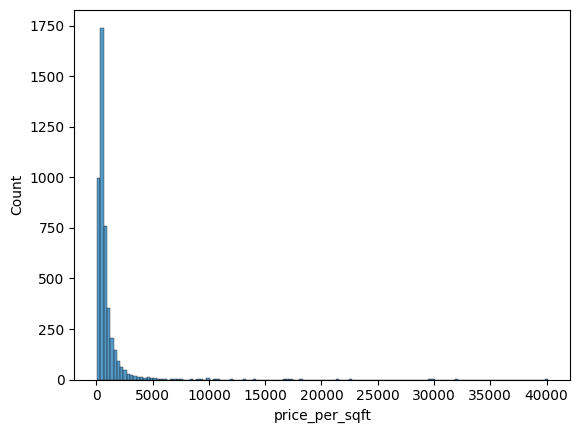

In [191]:
sns.histplot(df, x='price_per_sqft')

<Axes: xlabel='price_per_sqft', ylabel='type_clean'>

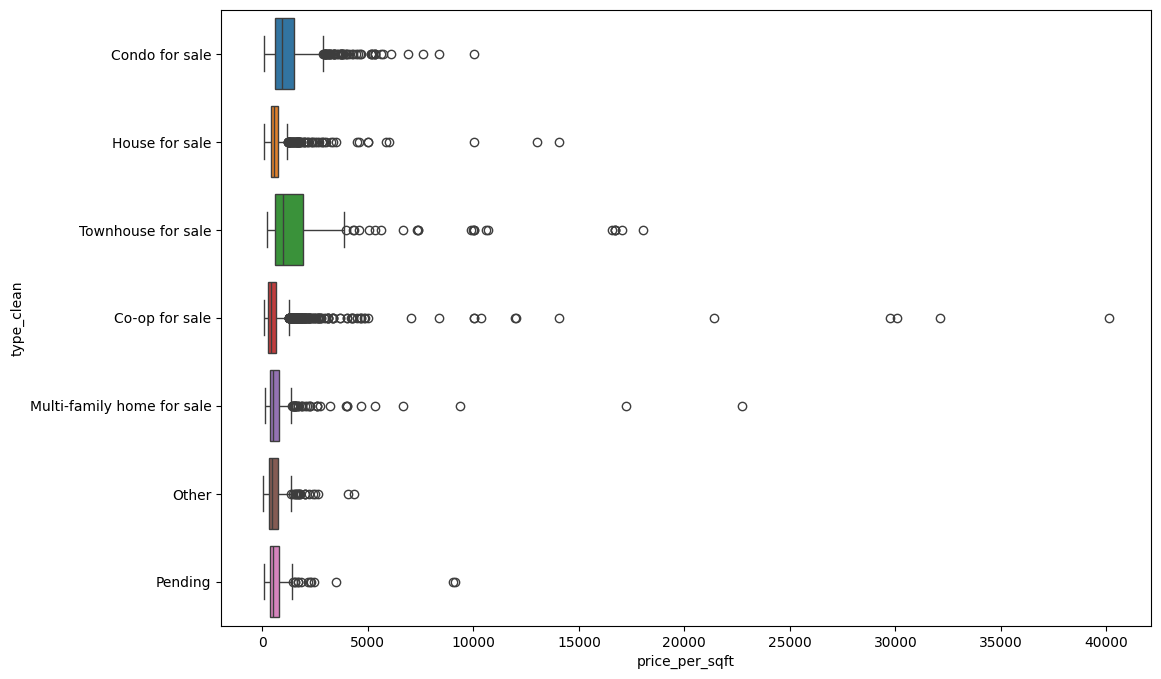

In [192]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='type_clean', hue='type_clean')

In [193]:
df[['price_per_sqft', 'price']].corr()

,price_per_sqft,price
price_per_sqft,1.000000,0.719888
price,0.719888,1.000000


<Axes: xlabel='price_per_sqft', ylabel='borough'>

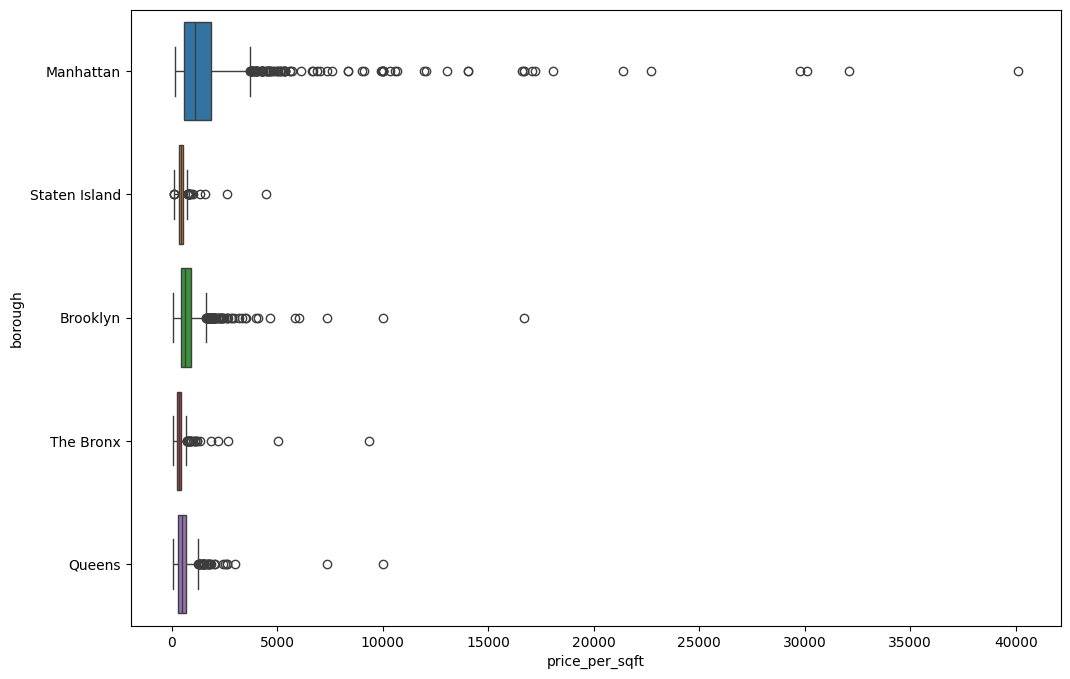

In [194]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='borough')

<Axes: xlabel='price_per_sqft', ylabel='borough'>

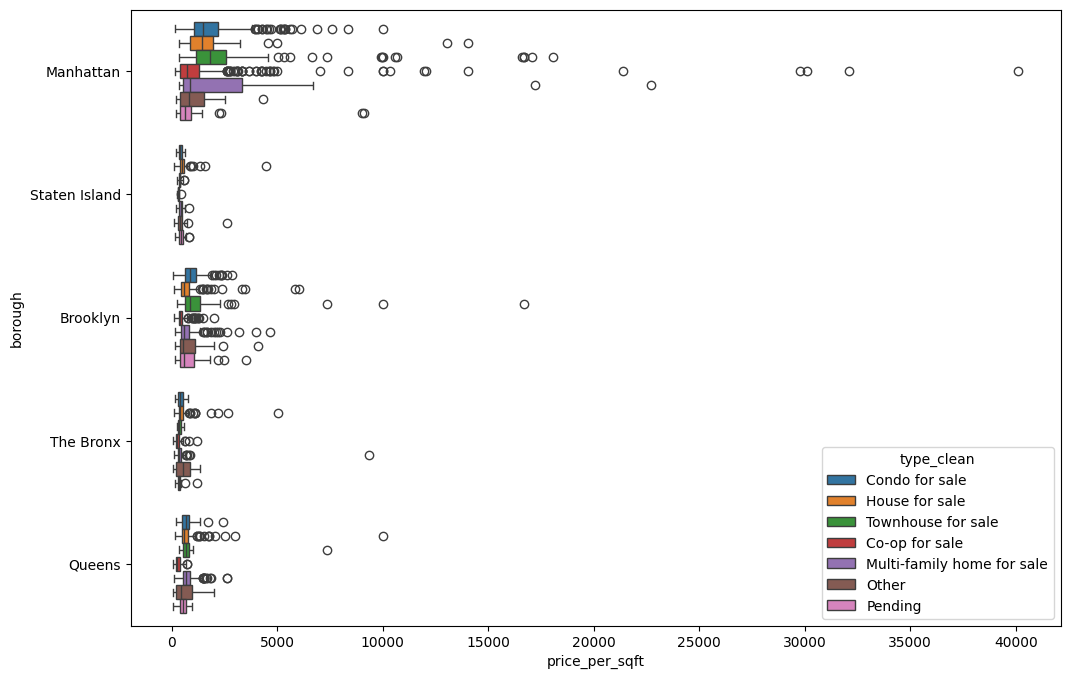

In [195]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='type_clean')

<Axes: xlabel='price_per_sqft', ylabel='borough'>

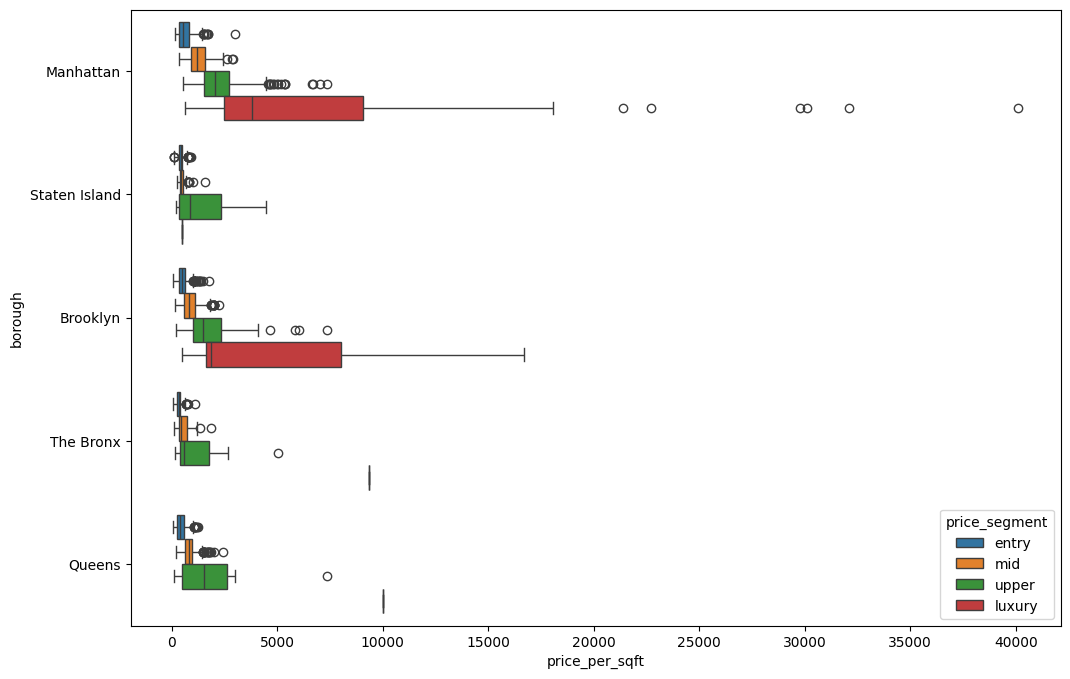

In [196]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='price_segment')

## Correlation

In [197]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'latitude', 'longitude', 'is_upper', 'is_mid', 'is_luxury',
       'price_segment', 'log_price', 'broker_count', 'luxury_score',
       'is_top_luxury_broker', 'type_clean', 'type_Condo for sale',
       'type_House for sale', 'type_Multi-family home for sale', 'type_Other',
       'type_Pending', 'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'bath_missing', 'log_bath', 'area_missing', 'log_area', 'zip',
       'borough', 'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens',
       'price_per_sqft', 'log_pps'],
      dtype='object')

In [198]:
numerical_columns = ['price', 'beds', 'bath', 'propertysqft',
       'log_price','log_beds', 'log_bath',
       'log_area','price_per_sqft']

In [199]:
corr = df[numerical_columns].corr()

<Axes: >

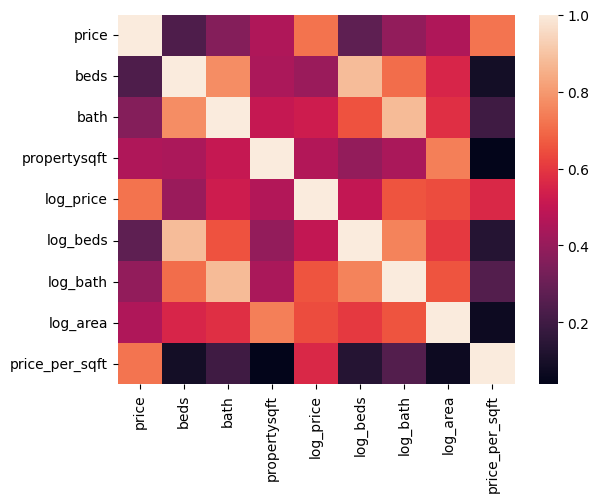

In [200]:
sns.heatmap(corr)

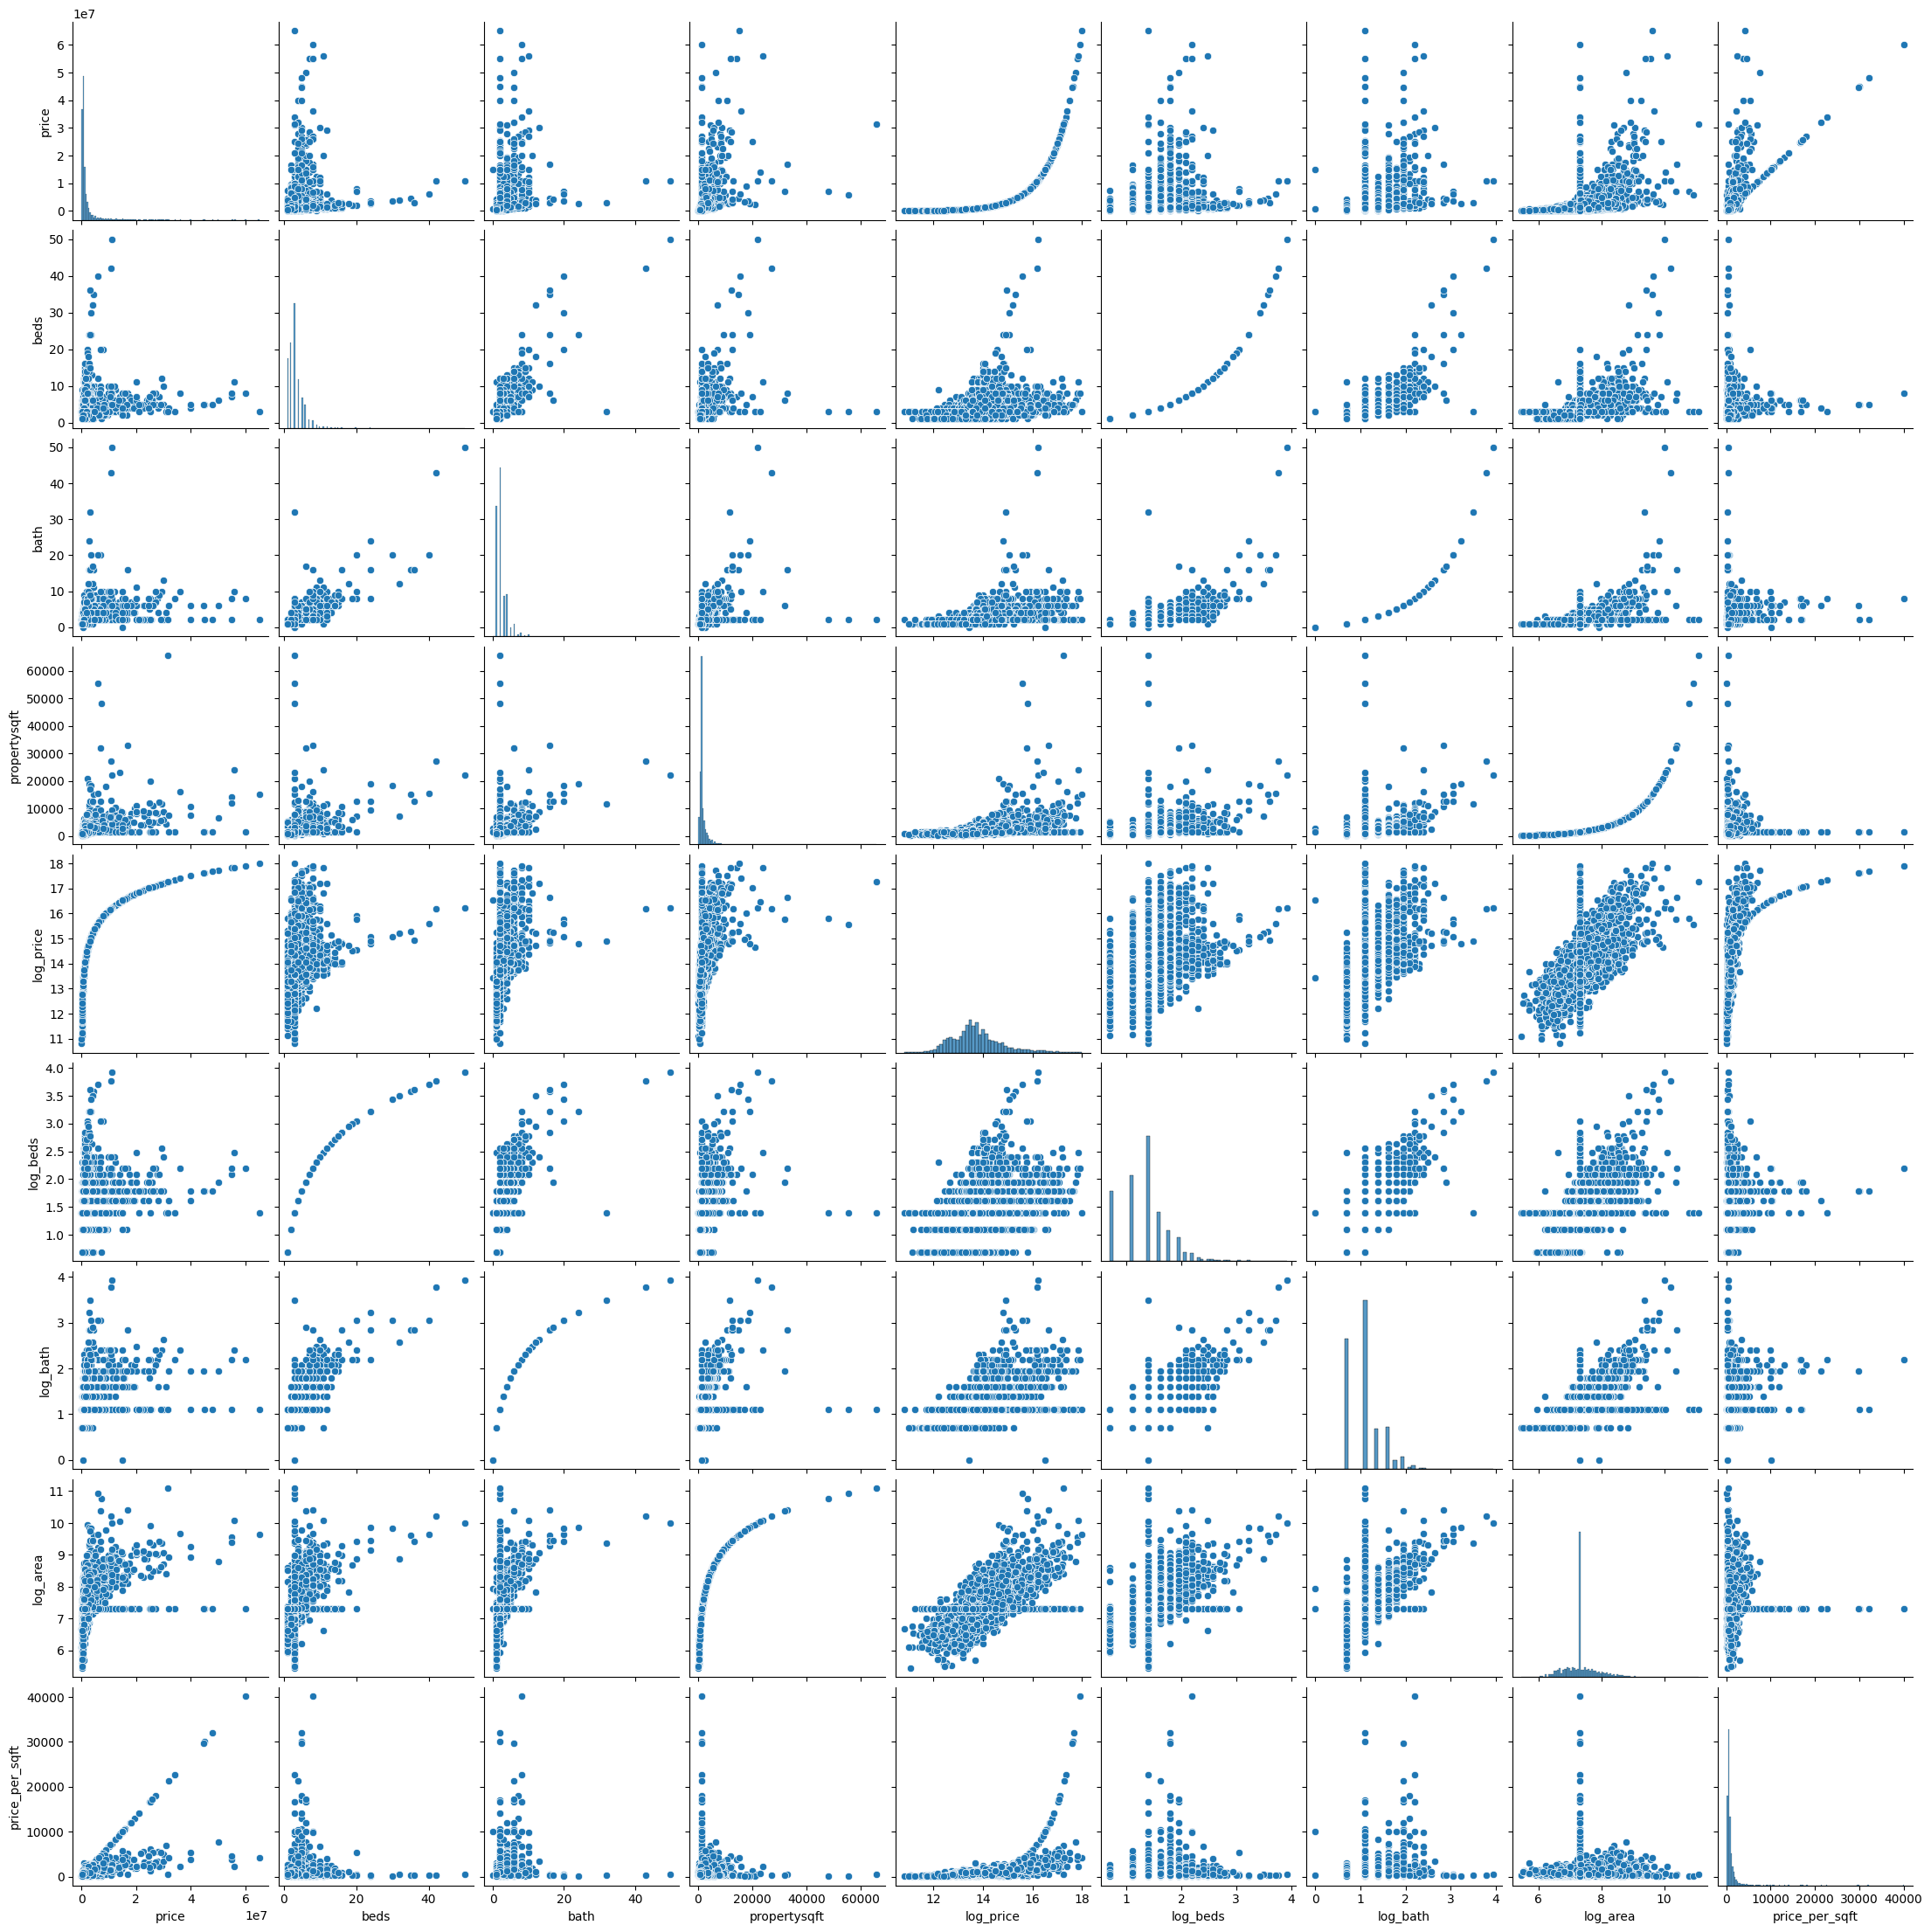

In [201]:
sns.pairplot(df[numerical_columns])

## Spatial distribution

In [202]:
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
)

In [203]:
gdf_utm = gdf.to_crs("EPSG:32618")

<Axes: xlabel='longitude', ylabel='latitude'>

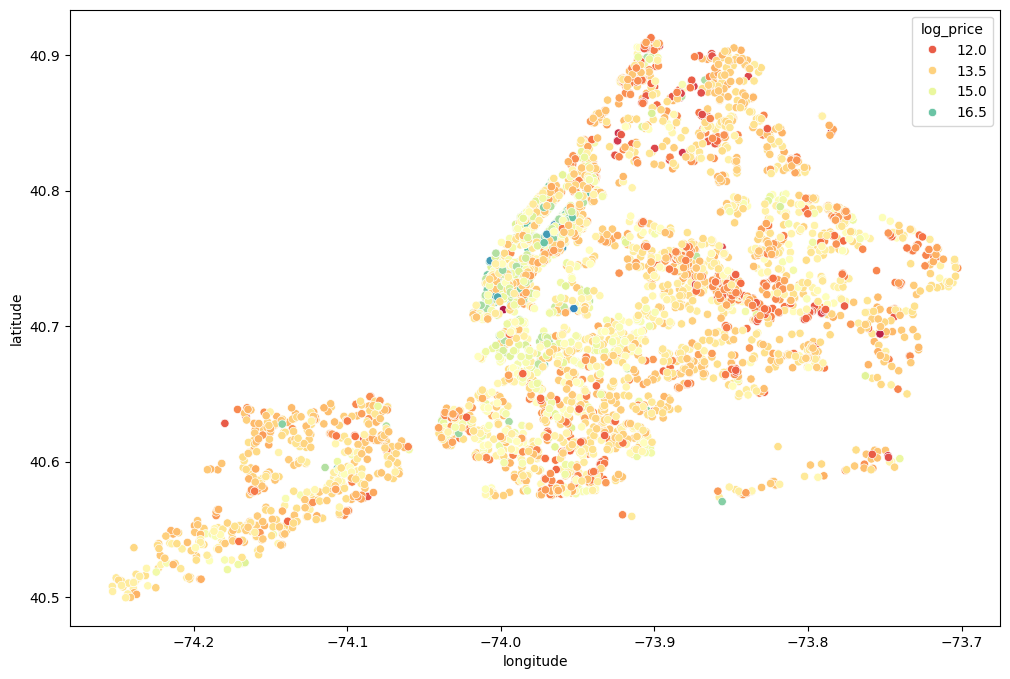

In [204]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df, palette="Spectral")

Text(0.5, 1.0, 'NYC Housing Prices (log scale)')

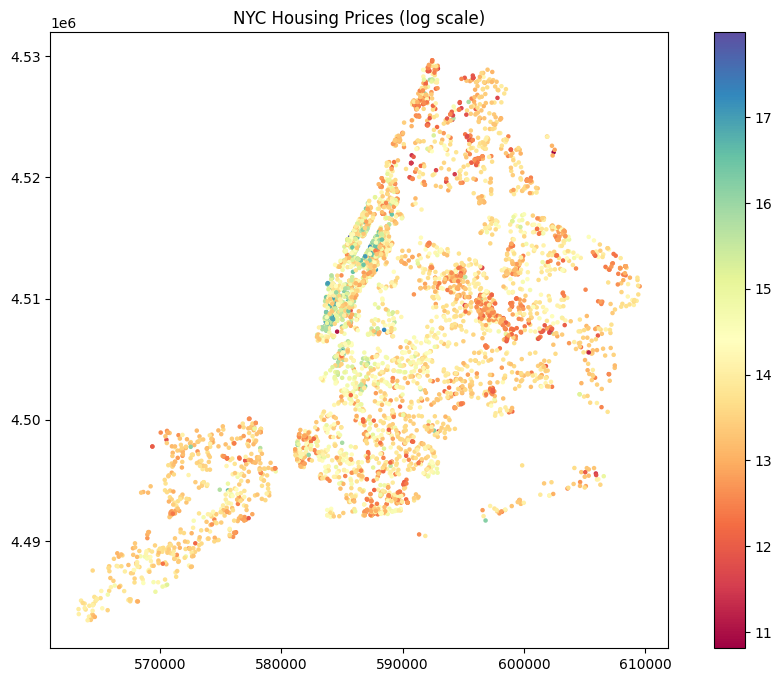

In [205]:
gdf_utm.plot(column="log_price", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("NYC Housing Prices (log scale)")

<Axes: xlabel='longitude', ylabel='latitude'>

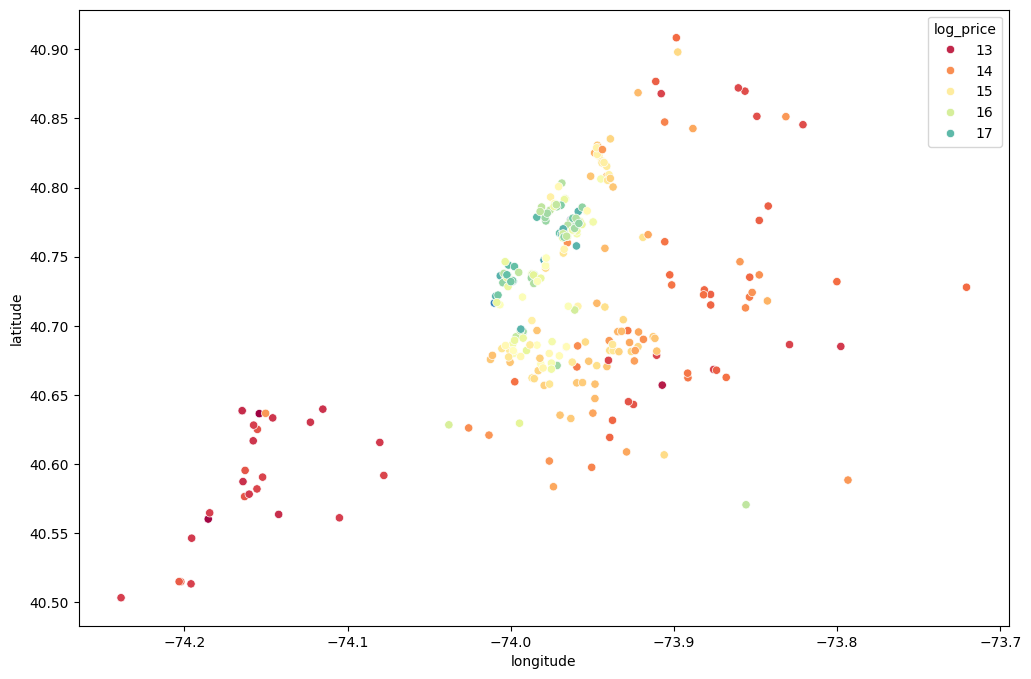

In [206]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df[df.type=='Townhouse for sale'], palette="Spectral")

<Axes: xlabel='longitude', ylabel='latitude'>

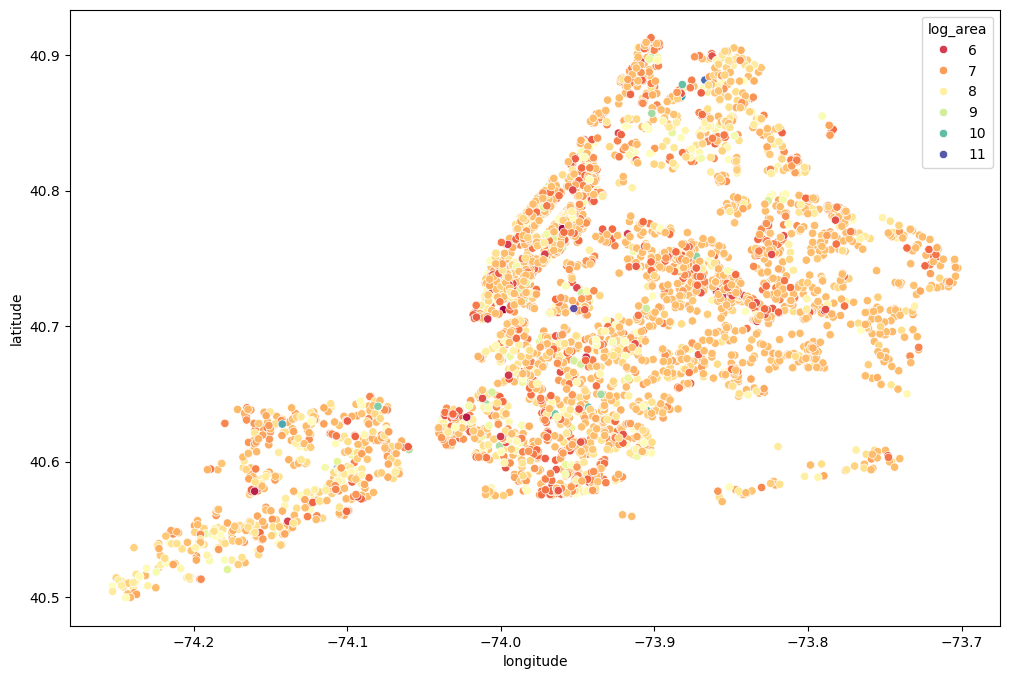

In [207]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_area", data=df, palette="Spectral")

<Axes: xlabel='longitude', ylabel='latitude'>

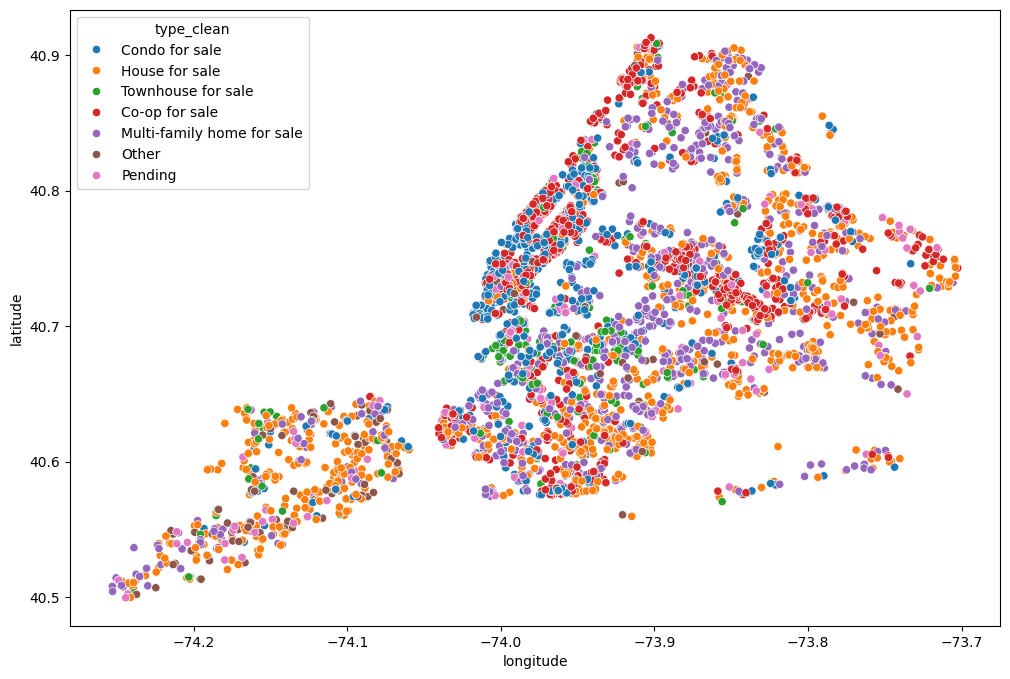

In [208]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="type_clean", data=df)

<Axes: xlabel='longitude', ylabel='latitude'>

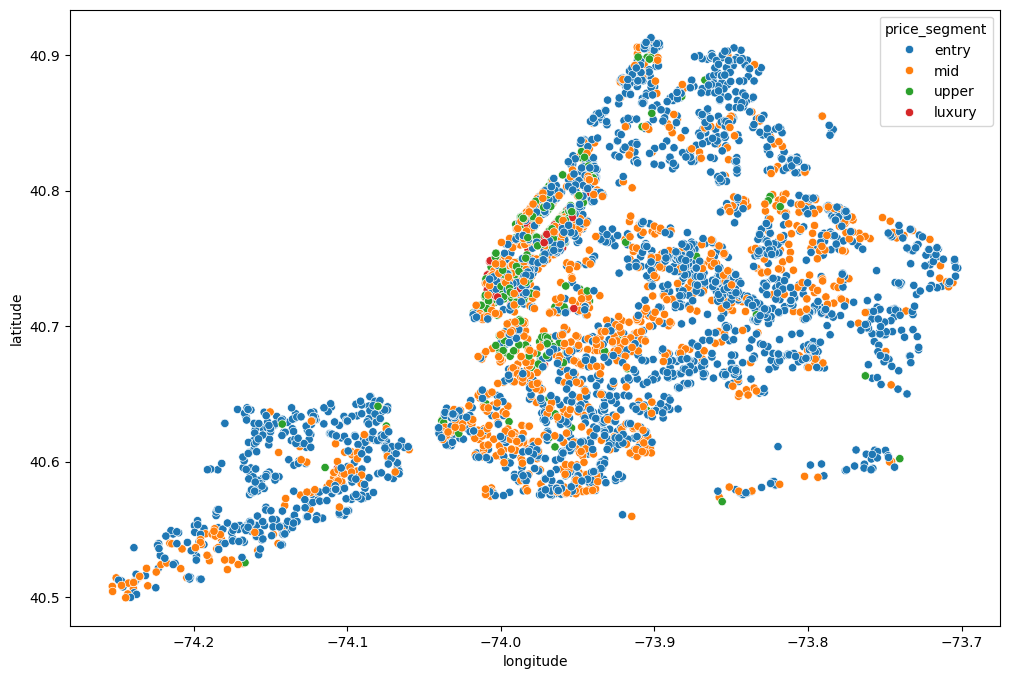

In [209]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="price_segment", data=df)

<Axes: xlabel='longitude', ylabel='latitude'>

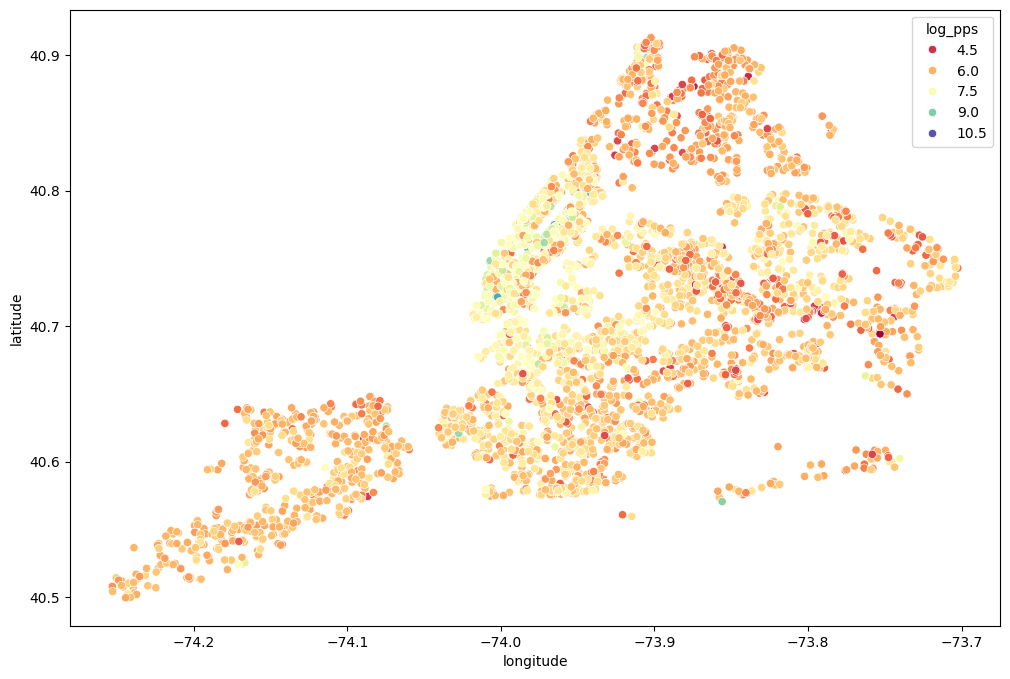

In [210]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_pps", data=df, palette="Spectral")

## Spatial distribution

In [211]:
# Extract UTM coordinates for spatial analysis
gdf_utm['x_utm'] = gdf_utm.geometry.x
gdf_utm['y_utm'] = gdf_utm.geometry.y

In [212]:
# Moran's I: tests for spatial autocorrelation in housing prices
from libpysal.weights import DistanceBand
from esda.moran import Moran


# Spatial weights using UTM coordinates
coords = gdf_utm[['x_utm', 'y_utm']].values
w = DistanceBand.from_array(coords, threshold=1000, silence_warnings=True)  # 1km threshold
moran = Moran(gdf_utm['price'], w)

In [213]:
print(f"Moran’s I: {moran.I:.3f}, p-value: {moran.p_sim:.3f}")

# Expected Moran’s I under randomness: E[I] = -1/(n-1)
print(f"Expected I under randomness: {-1/(len(gdf_utm)-1):.3f}")

Moran’s I: 0.217, p-value: 0.001
Expected I under randomness: -0.000


In [ ]:
# Result: significant positive autocorrelation (nearby properties have similar prices)
# This validates use of spatial features (neighborhood, proximity-based variables)

In [214]:
# Calculate Moran's on Manhattan properties
gdf_manhattan = gdf_utm[gdf_utm['borough'] == 'Manhattan']
coords_manh = gdf_manhattan[['x_utm', 'y_utm']].values
w_manh = DistanceBand.from_array(coords_manh, threshold=1000, silence_warnings=True)  # 1km threshold
moran_manh = Moran(gdf_manhattan['price'], w_manh)

In [215]:
print(f"Moran’s I: {moran_manh.I:.3f}, p-value: {moran_manh.p_sim:.3f}")

# Expected Moran’s I under randomness: E[I] = -1/(n-1)
print(f"Expected I under randomness: {-1/(len(gdf_manhattan)-1):.3f}")

Moran’s I: 0.105, p-value: 0.001
Expected I under randomness: -0.001


In [216]:
from esda import G_Local

In [217]:
w_G = DistanceBand.from_array(coords, threshold=750, silence_warnings=True)

In [218]:

z_value = 1.96

# Calculate hotspots (reuse the same weights `w` from Moran’s I)
gi = G_Local(gdf_utm['price'], w_G)
gdf_utm['is_hotspot'] = (gi.Zs > z_value).astype(int)

C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\esda\getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim


In [219]:
sum(gi.Zs>z_value)

np.int64(26)

Text(0.5, 1.0, 'G local with Z=1.96')

<Figure size 1200x800 with 0 Axes>

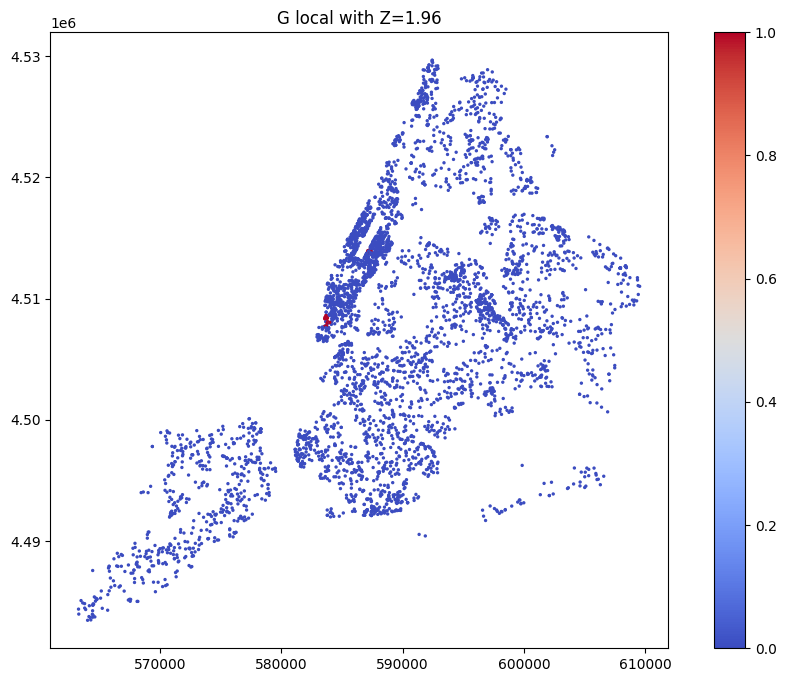

In [220]:
# Visualize
plt.figure(figsize=(12, 8))
gdf_utm.plot(column='is_hotspot', 
             cmap='coolwarm', 
             legend=True,
            markersize=2,
            figsize=(12,8))
plt.title(f"G local with Z={z_value}")

In [221]:
gdf_utm[gdf_utm['is_hotspot']==1].zip.value_counts()

zip
10013    16
10021     7
10065     2
10007     1
Name: count, dtype: int64

<Axes: xlabel='price'>

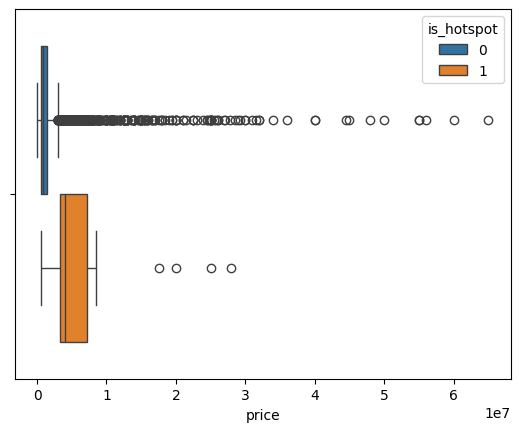

In [222]:
sns.boxplot(gdf_utm, x='price', hue='is_hotspot')

In [223]:
# It seems that hotspot could be more inclusive on luxury spectre. Need further testing

In [224]:
from libpysal.weights import Kernel, DistanceBand

In [225]:
# Test configurations
configs = [
    # Fixed bandwidth tests
    {'type': 'fixed', 'params': {'threshold': 500}, 'label': 'Fixed500m'},
    {'type': 'fixed', 'params': {'threshold': 750}, 'label': 'Fixed750m'},
    {'type': 'fixed', 'params': {'threshold': 1000}, 'label': 'Fixed1000m'},
    {'type': 'fixed', 'params': {'threshold': 1250}, 'label': 'Fixed1250m'},
    
    # Adaptive kernel tests
    {'type': 'adaptive', 'params': {'k': 5}, 'label': 'Adaptive5NN'},
    {'type': 'adaptive', 'params': {'k': 10}, 'label': 'Adaptive10NN'},
    {'type': 'adaptive', 'params': {'k': 15}, 'label': 'Adaptive15NN'}
]

z_values = {
    '60%': 0.253,
    '70%': 1.036,
    '80%': 1.282,
    '90%': 1.645,
    '95%': 1.960
}

In [226]:
# Run all combinations
results = []
for config in configs:
    # Create weights
    if config['type'] == 'fixed':
        w = DistanceBand.from_dataframe(gdf_utm, **config['params'], silence_warnings=True)
    else:
        w = Kernel.from_dataframe(gdf_utm, fixed=False, **config['params'], silence_warnings=True)
    
    # Calculate G_i
    gi = G_Local(gdf_utm['price'], w)
    
    # Test all z-values
    for conf_level, z in z_values.items():
        hotspots = (gi.Zs > z).sum()
        results.append({
            'config': config['label'],
            'z_value': conf_level,
            'n_hotspots': hotspots,
            'mean_price': gdf_utm['price'][gi.Zs > z].mean()
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\esda\getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\esda\getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\esda\getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected

In [227]:
results_df.sort_values('n_hotspots', ascending=False)

,config,z_value,n_hotspots,mean_price
15,Fixed1250m,60%,1004,4.849425e+06
10,Fixed1000m,60%,942,5.029533e+06
5,Fixed750m,60%,873,5.305551e+06
0,Fixed500m,60%,821,5.547751e+06
30,Adaptive15NN,60%,716,5.687251e+06
25,Adaptive10NN,60%,669,5.821943e+06
20,Adaptive5NN,60%,629,5.938237e+06
6,Fixed750m,70%,285,8.135675e+06
26,Adaptive10NN,70%,281,8.421729e+06
1,Fixed500m,70%,273,8.024766e+06


In [228]:
results_df.sort_values('z_value', ascending=False)

,config,z_value,n_hotspots,mean_price
34,Adaptive15NN,95%,108,1.092248e+07
29,Adaptive10NN,95%,109,1.068310e+07
14,Fixed1000m,95%,1,3.498000e+06
24,Adaptive5NN,95%,130,9.530760e+06
9,Fixed750m,95%,26,7.038308e+06
19,Fixed1250m,95%,0,NaN
4,Fixed500m,95%,83,1.010746e+07
28,Adaptive10NN,90%,147,1.037185e+07
18,Fixed1250m,90%,2,5.196500e+06
3,Fixed500m,90%,132,1.043090e+07


In [229]:
results_df.sort_values('mean_price', ascending=False)

,config,z_value,n_hotspots,mean_price
17,Fixed1250m,80%,40,1.125785e+07
33,Adaptive15NN,90%,136,1.097251e+07
34,Adaptive15NN,95%,108,1.092248e+07
29,Adaptive10NN,95%,109,1.068310e+07
3,Fixed500m,90%,132,1.043090e+07
28,Adaptive10NN,90%,147,1.037185e+07
12,Fixed1000m,80%,133,1.021208e+07
4,Fixed500m,95%,83,1.010746e+07
13,Fixed1000m,90%,24,9.910042e+06
7,Fixed750m,80%,179,9.899858e+06


In [230]:
# It seems that w_kernel gives better results. And with 15 neighbours and confidence level 90% is the best it gives best results.

In [231]:
# Should use w_kernel 15NN, z_value=1.654
w_kernel_final = Kernel.from_dataframe(gdf_utm, fixed=False, k=15)

C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\libpysal\weights\distance.py:563: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, weights, ids, **kwargs)


In [232]:
gi_final = G_Local(gdf_utm['price'], w_kernel_final)
gdf_utm['is_hotspot'] = (gi_final.Zs > 1.645).astype(int)

C:\Users\User\.virtualenvs\task2_git-NJPCFo58\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)


<Axes: xlabel='price'>

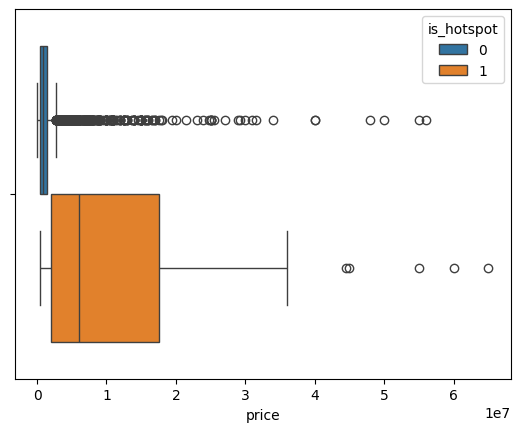

In [233]:
sns.boxplot(gdf_utm, x='price', hue='is_hotspot')

<Axes: >

<Figure size 1200x800 with 0 Axes>

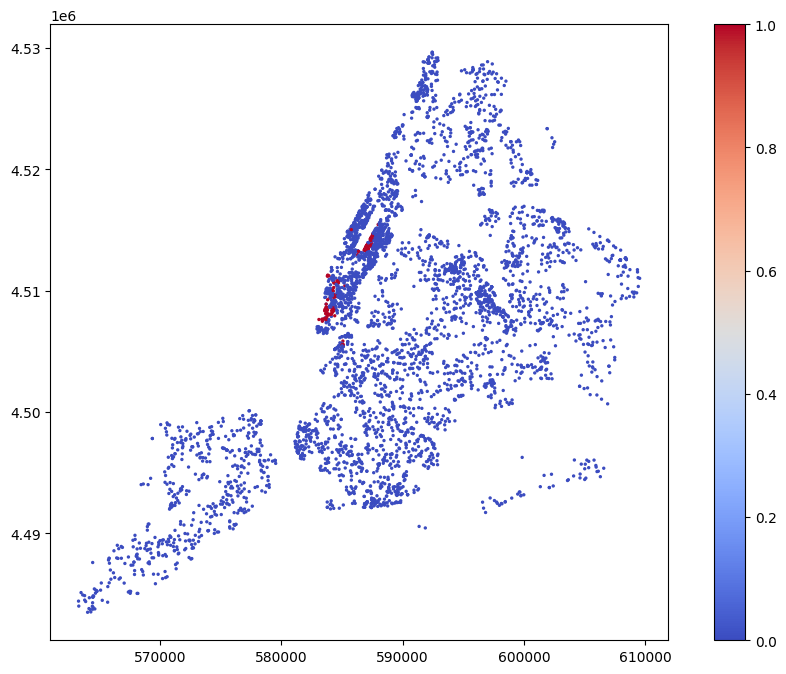

In [234]:
# Visualize
plt.figure(figsize=(12, 8))
gdf_utm.plot(column='is_hotspot', 
             cmap='coolwarm', 
             legend=True,
            markersize=2,
            figsize=(12,8))

In [235]:
# Ok, here we need better visualisation

In [236]:
# Let's  try to find coldspots with same parameters

In [237]:
gdf_utm['is_coldspot'] = (gi_final.Zs < -1.645).astype(int)

In [238]:
gdf_utm.is_coldspot.value_counts()

is_coldspot
0    4582
Name: count, dtype: int64

## Building basiline regression on original dataset

In [239]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [240]:
parameter_columns = ['beds', 'bath', 'propertysqft']
target_column = ['price']

In [241]:
def run_regression(df, feature_columns, target_column='price', cv_folds=5):
    X = df[feature_columns]
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('MAE: ', mae)
    print('R2: ', r2)
    scores = cross_val_score(model, X, y, cv=cv_folds, scoring='r2')
    print(f"Cross-validated R2: {scores.mean():.3f}")
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel('Actual price')
    plt.ylabel('Predicted price')
    plt.title('Actual vs Predicted')
    plt.show()
    print(model.coef_)

MAE:  1446041.864565475
R2:  0.11111155927349747
Cross-validated R2: 0.216


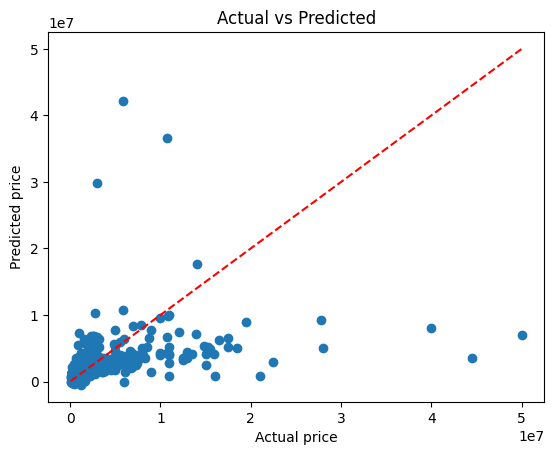

[-318153.01456693  687879.93497455     756.69855659]


In [242]:
# ID: 1
run_regression(df, parameter_columns)

In [243]:
experiment_log = pd.DataFrame(columns=[
    'ID', 'Model', 'Features', 'Params', 'MAE', 'R2', 'Cross_val_R2', 'Comment'
])

In [244]:
new_entry = {
    'ID': 1,
    'Model': 'LinearRegression',
    'Features': parameter_columns,
    'Params': None,
    'MAE': 1446041.86,
    'R2': 0.111,
    'Cross_val_R2': 0.216,
    'Comment': 'Baseline linear regression'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [245]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.86,0.111,0.216,Baseline linear regression


## Building baseline regression on log dataset

In [246]:
parameter_columns_log = ['log_beds', 'log_bath', 'log_area']
target_column = ['price']

MAE:  1669929.6087195377
R2:  0.2488138635270536
Cross-validated R2: 0.223


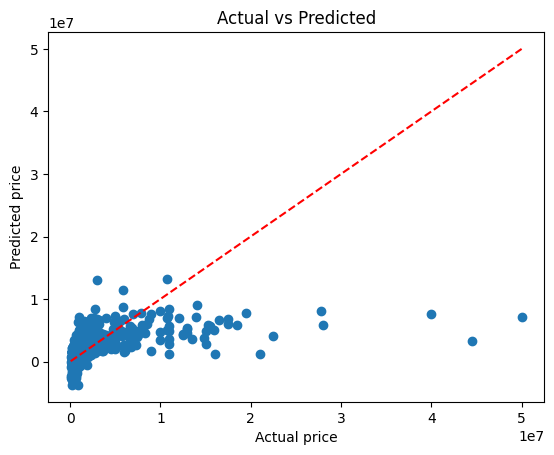

[-1167950.71397377  2411755.68244424  2716887.08000102]


In [247]:
# ID:b 2
run_regression(df, parameter_columns_log)

In [248]:
new_entry = {
    'ID': 2,
    'Model': 'LinearRegression',
    'Features': parameter_columns_log,
    'Params': None,
    'MAE': 1669929.60,
    'R2': 0.248,
    'Cross_val_R2': 0.223,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [249]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.86,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.60,0.248,0.223,


## Regression on all non spatial data

In [250]:
all_non_spatial_features = [ 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area']

MAE:  1590792.6571588588
R2:  0.35156558563553064
Cross-validated R2: 0.304


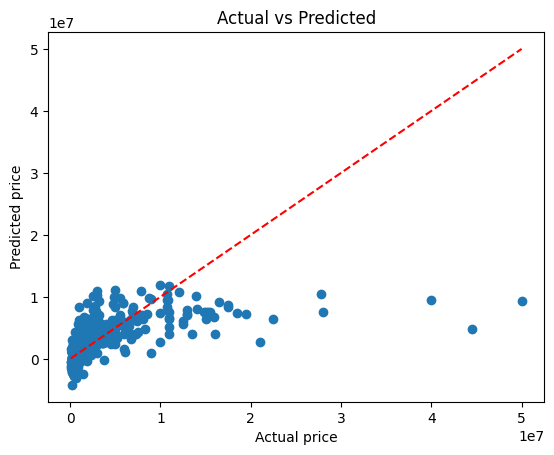

[  555646.29543109 -1597179.87464376 -2909013.68318822 -1409485.91392529
 -1171801.44891972  1266946.19067571 -4562212.45282224   547410.78405773
  2480724.2174317    128062.2218792   2629210.54259998]


In [251]:
# ID: 3
run_regression(df, all_non_spatial_features)

In [252]:
new_entry = {
    'ID': 3,
    'Model': 'LinearRegression',
    'Features': all_non_spatial_features,
    'Params': None,
    'MAE': 1590792.65,
    'R2': 0.351,
    'Cross_val_R2': 0.304,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [253]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.86,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.60,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.65,0.351,0.304,


In [254]:
all_features = [
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds', 'log_bath',
       'area_missing', 'log_area', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens']

MAE:  1560379.0433904117
R2:  0.3827027392621426
Cross-validated R2: 0.349


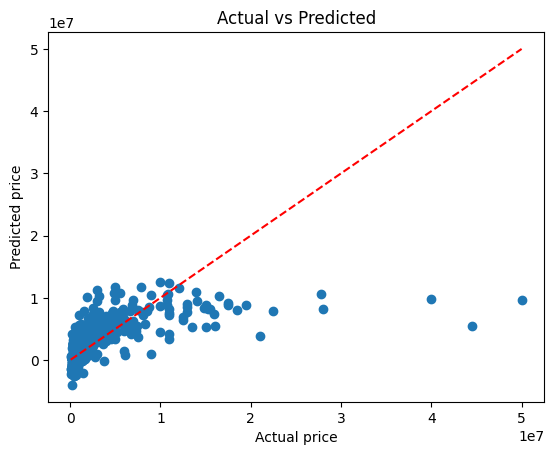

[  474680.65455211  -478303.7244891  -1582451.60172841  -550876.43493889
  -524986.97188907  1745970.99032532 -3940875.08853344   541844.23062894
  2009734.72338625  -152619.33881072  2297018.8524683   2692770.66048107
   530010.35736119   466159.3157771 ]


In [255]:
# ID: 4
run_regression(df, all_features)

In [256]:
new_entry = {
    'ID': 4,
    'Model': 'LinearRegression',
    'Features': all_features,
    'Params': None,
    'MAE': 1560379.043,
    'R2': 0.382,
    'Cross_val_R2': 0.349,
    'Comment': 'Only lat long missing'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [257]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing


In [258]:
all_non_log_features = ['beds', 'bath', 'propertysqft',  
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 
       'area_missing', 'borough_Manhattan',
       'borough_Brooklyn', 'borough_Queens']

MAE:  1471016.517942964
R2:  0.2753667787708399
Cross-validated R2: 0.349


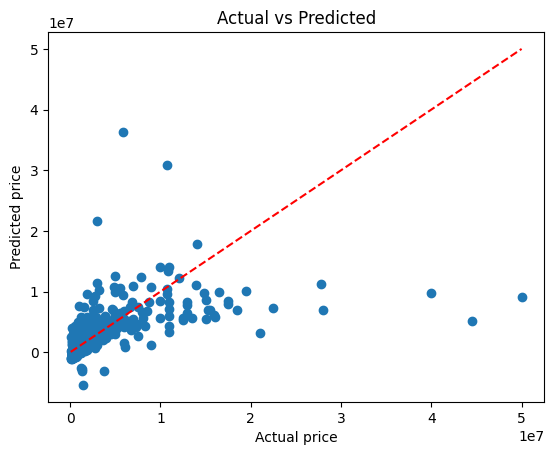

[ 2.97638620e+04  4.90771184e+05  6.75123780e+02  7.26628493e+05
  4.42058543e+05 -5.19551662e+05  1.08773988e+05  5.20260379e+04
  2.60199683e+06 -7.38073574e+06  1.84832767e+05  2.84576083e+06
  4.75287822e+05  4.18312846e+05]


In [259]:
# ID: 5
run_regression(df, all_non_log_features)

In [260]:
new_entry = {
    'ID': 5,
    'Model': 'LinearRegression',
    'Features': all_non_log_features,
    'Params': None,
    'MAE': 1471016.51,
    'R2': 0.275,
    'Cross_val_R2': 0.349,
    'Comment': ''
}
experiment_log.loc[len(experiment_log)] = new_entry

In [261]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,


In [262]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'latitude', 'longitude', 'is_upper', 'is_mid', 'is_luxury',
       'price_segment', 'log_price', 'broker_count', 'luxury_score',
       'is_top_luxury_broker', 'type_clean', 'type_Condo for sale',
       'type_House for sale', 'type_Multi-family home for sale', 'type_Other',
       'type_Pending', 'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'bath_missing', 'log_bath', 'area_missing', 'log_area', 'zip',
       'borough', 'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens',
       'price_per_sqft', 'log_pps'],
      dtype='object')

In [263]:
all_features_with_lat_long = ['latitude',
       'longitude',
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'log_bath', 'area_missing', 'log_area',
       'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens']

MAE:  1553327.3754859772
R2:  0.382137842713005
Cross-validated R2: 0.350


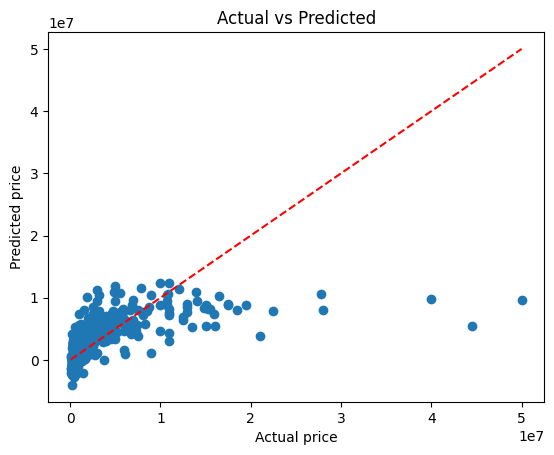

[ 2189473.3701768  -1639811.12963059   477682.35134632  -389512.51699997
 -1527673.38597787  -468057.31450404  -485339.6940088   1757206.04392228
 -3960136.6917993    536539.01811547  2005066.41864545  -164798.9506755
  2288696.39534765  2690435.53059101   794061.52560855   759287.78430663]


In [264]:
# ID: 6
run_regression(df, all_features_with_lat_long)

In [265]:
new_entry = {
    'ID': 6,
    'Model': 'LinearRegression',
    'Features': all_features_with_lat_long,
    'Params': None,
    'MAE': 1553327.37,
    'R2': 0.382,
    'Cross_val_R2': 0.350,
    'Comment': 'On adding lat long changes insignificant'
}
experiment_log.loc[len(experiment_log)] = new_entry

In [266]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant


## Gradient Boosting Regressor

In [267]:
from sklearn.ensemble import GradientBoostingRegressor

In [268]:
def run_gb_regressor(df, feature_columns, target_column='price', cv_folds=5):
    X = df[feature_columns]
    y = df[target_column]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
    )

    # Train and predict
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print('MAE: ', mae)
    print('R2: ', r2)
    scores = cross_val_score(gbr, X, y, cv=cv_folds, scoring='r2')
    print(f"Cross-validated R²: {scores.mean():.3f}")
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel('Actual price')
    plt.ylabel('Predicted price')
    plt.title('Actual vs Predicted')
    plt.show()

    residuals = y_test - y_pred
    results_df = X_test.copy()
    results_df['actual_price'] = y_test
    results_df['predicted_price'] = y_pred
    results_df['residual'] = residuals
    results_df['pct_error'] = (residuals / y_test) * 100
    #return results_df

In [269]:
all_features_with_lat_long

['latitude',
 'longitude',
 'type_Condo for sale',
 'type_House for sale',
 'type_Multi-family home for sale',
 'type_Other',
 'type_Pending',
 'type_Townhouse for sale',
 'is_high_beds',
 'log_beds',
 'log_bath',
 'area_missing',
 'log_area',
 'borough_Manhattan',
 'borough_Brooklyn',
 'borough_Queens']

MAE:  873832.2399976306
R2:  0.468020605598079
Cross-validated R²: 0.580


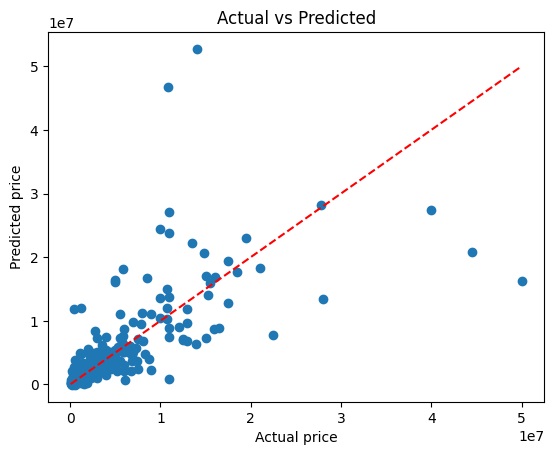

In [270]:
# ID: 7
run_gb_regressor(df, all_features_with_lat_long)

In [271]:
# This chart looks better then linear regression chart

In [272]:
new_entry = {
    'ID': 7,
    'Model': 'GradientBoostingRegressor',
    'Features': all_features_with_lat_long,
    'Params': {'n_estimators':500,
               'learning_rate':0.05,
               'max_depth':4,
               'subsample':0.8,
               'min_samples_leaf':5},
    'MAE': 873832.23,
    'R2': 0.468,
    'Cross_val_R2': 0.580,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [273]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,


In [274]:
# I will try to add spatial features and see what will happend

In [275]:
# Central Park South (5th Ave edge - most prestigious side)
park_coords = (40.7666, -73.9712)

# Manhattan distance
df['central_part_dist'] = (
    abs(df['latitude'] - park_coords[0]) + 
    abs(df['longitude'] - park_coords[1])
)

In [276]:
# Times Square coordinates
tsq_coords = (40.7580, -73.9855)

# Manhattan distance
df['tsq_dist'] = (
    abs(df['latitude'] - tsq_coords[0]) + 
    abs(df['longitude'] - tsq_coords[1])
)

In [277]:
new_entry = {
    'ID': None,
    'Model': 'Feature Engineering',
    'Features': ['central_part_dist','tsq_dist'],
    'Params': '',
    'MAE': np.nan,
    'R2': np.nan,
    'Cross_val_R2': np.nan,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [278]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,


In [279]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'latitude', 'longitude', 'is_upper', 'is_mid', 'is_luxury',
       'price_segment', 'log_price', 'broker_count', 'luxury_score',
       'is_top_luxury_broker', 'type_clean', 'type_Condo for sale',
       'type_House for sale', 'type_Multi-family home for sale', 'type_Other',
       'type_Pending', 'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'bath_missing', 'log_bath', 'area_missing', 'log_area', 'zip',
       'borough', 'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens',
       'price_per_sqft', 'log_pps', 'central_part_dist', 'tsq_dist'],
      dtype='object')

In [280]:
all_features_expanded = ['latitude',
       'longitude', 
       'type_Condo for sale', 'type_House for sale',
       'type_Multi-family home for sale', 'type_Other', 'type_Pending',
       'type_Townhouse for sale', 'is_high_beds', 'log_beds',
       'log_bath', 'area_missing', 'log_area',
       'borough_Manhattan', 'borough_Brooklyn', 'borough_Queens',
       'central_part_dist', 'tsq_dist']

MAE:  1549143.3654935367
R2:  0.38846865275035536
Cross-validated R2: 0.353


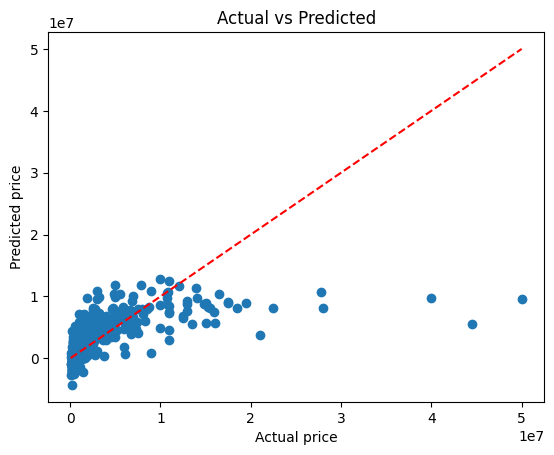

[-3488063.45607854  1985046.95177345   384618.9786169   -329895.34872157
 -1502153.09267744  -492790.07965018  -432912.08079512  1788509.56801503
 -4064345.31799838   534087.07706934  2039704.27678108  -207465.73710609
  2258285.00925276  1298842.14837205  -644368.72791541  -342946.78975136
  2662156.62937852 -9735588.49043204]


In [281]:
# ID: 8
run_regression(df, all_features_expanded)

In [282]:
# Nothing changed in linear regression

In [283]:
new_entry = {
    'ID': 8,
    'Model': 'LinearRegression',
    'Features': all_features_expanded,
    'Params': '',
    'MAE': 1549143.36,
    'R2': 0.388,
    'Cross_val_R2': 0.353,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

MAE:  843038.0630641275
R2:  0.5464847378893849
Cross-validated R²: 0.589


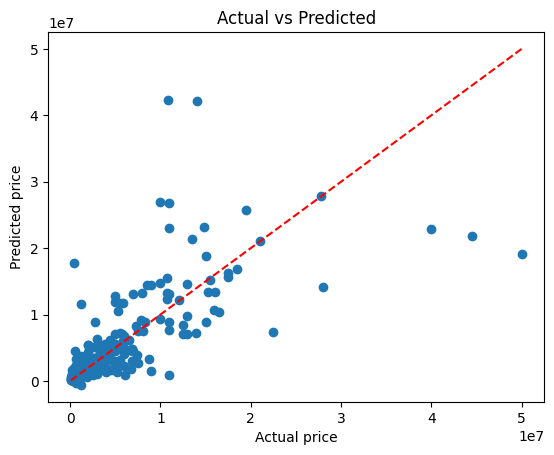

In [284]:
# ID: 9
run_gb_regressor(df, feature_columns=all_features_expanded)

In [285]:
# Gradient boosting regressor improved visually and by R2 score

In [286]:
new_entry = {
    'ID': 9,
    'Model': 'GradientBoostingRegressor',
    'Features': all_features_expanded,
    'Params': {'n_estimators':500,
               'learning_rate':0.05,
               'max_depth':4,
               'subsample':0.8,
               'min_samples_leaf':5},
    'MAE': 843038.06,
    'R2': 0.546,
    'Cross_val_R2': 0.589,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [287]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,
8,8,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",,1549143.360,0.388,0.353,
9,9,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",843038.060,0.546,0.589,


In [288]:
segment_features = [
    'beds', 'bath', 'propertysqft', 
    'borough_Manhattan',
    'type_Condo for sale', 'type_Townhouse for sale',
    'central_part_dist', 'tsq_dist'
]

<Axes: >

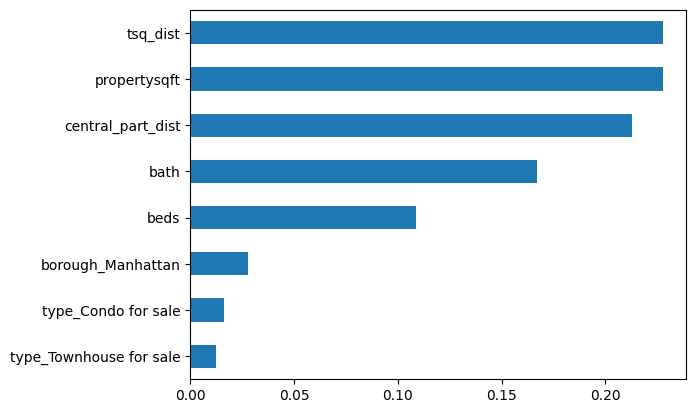

In [289]:
from sklearn.ensemble import RandomForestClassifier

# Train classifier to predict segment
segment_model = RandomForestClassifier().fit(
    df[segment_features],
    df['price_segment']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=segment_features
).sort_values().plot(kind='barh')

<Axes: >

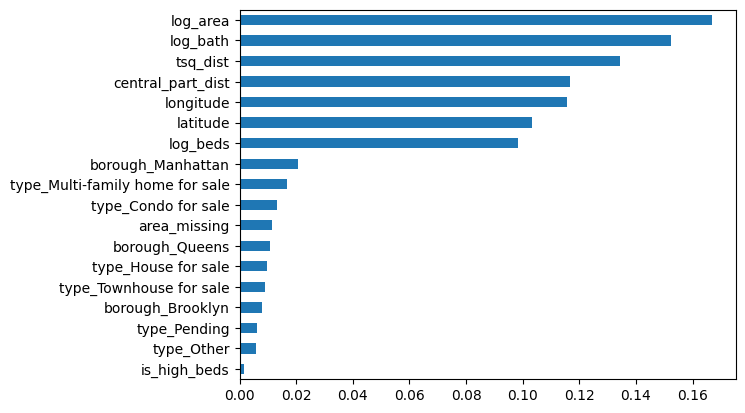

In [290]:
# Train classifier to predict segment
segment_model = RandomForestClassifier().fit(
    df[all_features_expanded],
    df['price_segment']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=all_features_expanded
).sort_values().plot(kind='barh')

In [291]:
from sklearn.ensemble import RandomForestRegressor

<Axes: >

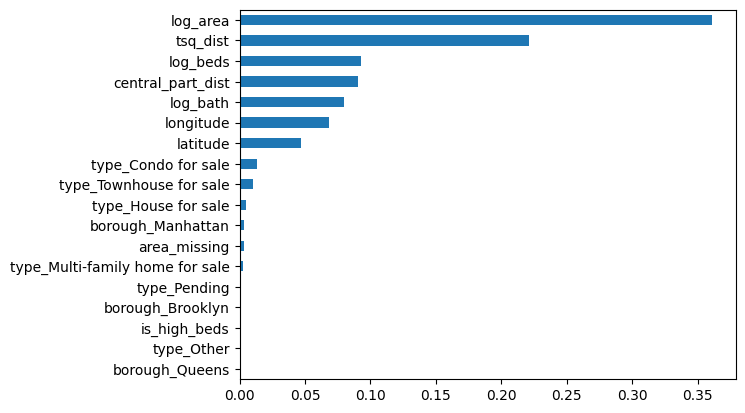

In [292]:
# RandomForestRegressor
segment_model = RandomForestRegressor().fit(
    df[all_features_expanded],
    df['price']
)

# Get feature importance
pd.Series(
    segment_model.feature_importances_,
    index=all_features_expanded
).sort_values().plot(kind='barh')

In [293]:
all_features_expanded

['latitude',
 'longitude',
 'type_Condo for sale',
 'type_House for sale',
 'type_Multi-family home for sale',
 'type_Other',
 'type_Pending',
 'type_Townhouse for sale',
 'is_high_beds',
 'log_beds',
 'log_bath',
 'area_missing',
 'log_area',
 'borough_Manhattan',
 'borough_Brooklyn',
 'borough_Queens',
 'central_part_dist',
 'tsq_dist']

MAE: и979,173
R2: 0.404
CV R2: 0.423 ± 0.032


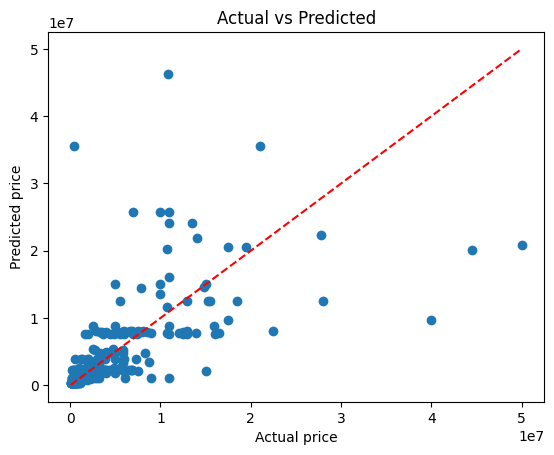

In [294]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

X = df[all_features_expanded]
y = df['price'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train with luxury-focused parameters
tree = DecisionTreeRegressor(
    max_depth=7,  # Increased depth
    min_samples_leaf=3,  # Fewer samples per leaf
    min_impurity_decrease=5e5,  # Require $500K MSE reduction
    max_features=0.8,  # Random feature subset per split
    random_state=42
)
tree.fit(X_train, y_train)

# Predict
y_pred = tree.predict(X_test)

# Metrics
print(f"MAE: и{mean_absolute_error(y_test, y_pred):,.0f}")
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.3f}")
# Cross-validated R2
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(tree, X, y, cv=5, scoring='r2')
print(f"CV R2: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

In [295]:
new_entry = {
    'ID': 10,
    'Model': 'DecisionTreeRegressor',
    'Features': all_features_expanded,
    'Params': {'max_depth':7,
    'min_samples_leaf':3,
    'min_impurity_decrease':5e5,
    'max_features':0.8},
    'MAE': 979173,
    'R2': 0.404,
    'Cross_val_R2': 0.423,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [296]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,
8,8,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",,1549143.360,0.388,0.353,
9,9,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",843038.060,0.546,0.589,


<Axes: >

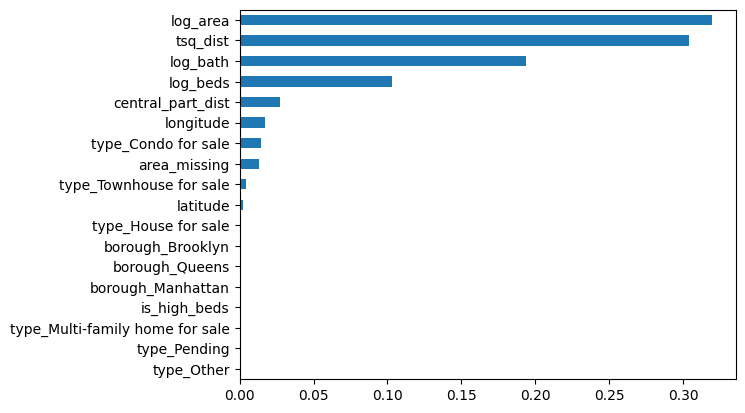

In [297]:
pd.Series(tree.feature_importances_, index=X.columns).sort_values().plot(kind='barh')

MAE: $758,783
R2: 0.587
CV R2: 0.632 ± 0.046


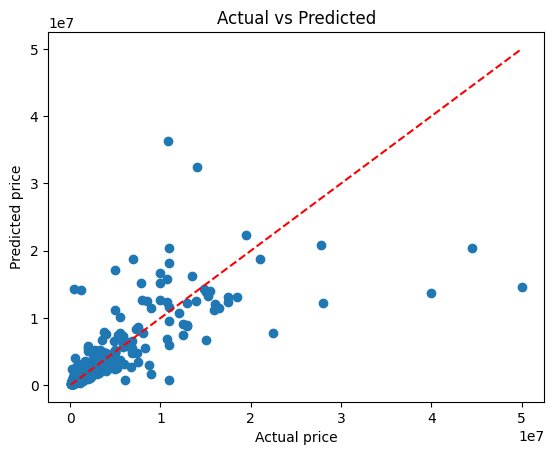

In [298]:
# ID: 
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    min_impurity_decrease=1e5
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.0f}")
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.3f}")
# Cross-validated R2
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"CV R2: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted')
plt.show()

In [299]:
new_entry = {
    'ID': 11,
    'Model': 'RandomForestRegressor',
    'Features': all_features_expanded,
    'Params': {'n_estimators':100,
    'max_depth':15,
    'min_samples_leaf':5,
    'min_impurity_decrease':1e5},
    'MAE': 738579,
    'R2': 0.605,
    'Cross_val_R2': 0.622,
    'Comment': ''
},
#experiment_log.loc[len(experiment_log)] = new_entry
experiment_log = pd.concat([experiment_log,pd.DataFrame(new_entry)], ignore_index=True)

In [300]:
experiment_log

,ID,Model,Features,Params,MAE,R2,Cross_val_R2,Comment
0,1,LinearRegression,"[beds, bath, propertysqft]",None,1446041.860,0.111,0.216,Baseline linear regression
1,2,LinearRegression,"[log_beds, log_bath, log_area]",None,1669929.600,0.248,0.223,
2,3,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1590792.650,0.351,0.304,
3,4,LinearRegression,"[type_Condo for sale, type_House for sale, typ...",None,1560379.043,0.382,0.349,Only lat long missing
4,5,LinearRegression,"[beds, bath, propertysqft, type_Condo for sale...",None,1471016.510,0.275,0.349,
5,6,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",None,1553327.370,0.382,0.350,On adding lat long changes insignificant
6,7,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",873832.230,0.468,0.580,
7,None,Feature Engineering,"[central_part_dist, tsq_dist]",,NaN,NaN,NaN,
8,8,LinearRegression,"[latitude, longitude, type_Condo for sale, typ...",,1549143.360,0.388,0.353,
9,9,GradientBoostingRegressor,"[latitude, longitude, type_Condo for sale, typ...","{'n_estimators': 500, 'learning_rate': 0.05, '...",843038.060,0.546,0.589,


<Axes: xlabel='tsq_dist', ylabel='price'>

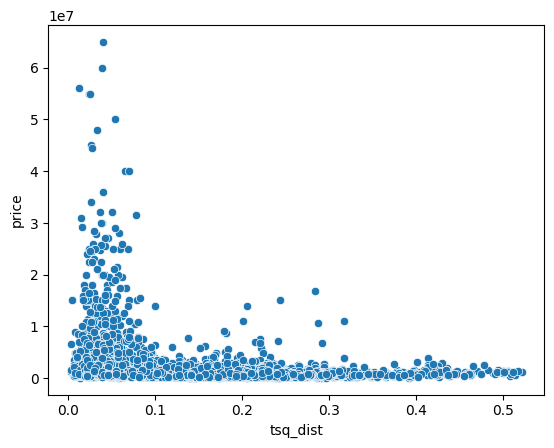

In [301]:
sns.scatterplot(df, x='tsq_dist', y='price')

<Axes: xlabel='tsq_dist', ylabel='Count'>

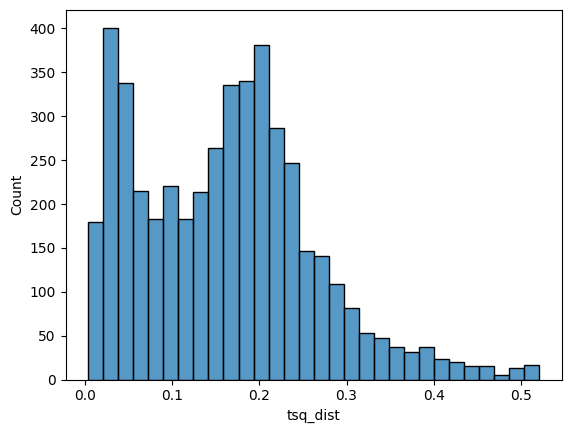

In [302]:
sns.histplot(df, x='tsq_dist')

In [303]:
# export experiment log
experiment_log.to_csv('../outputs/experiment_log.csv', mode='w', header=True, index=False)